# Auswertung: Erfolgspotenzial von Career Counseling Chatbots aus Sicht von Stellensuchenden
### Bachelorarbeit Tharsana Jegatheeswaran | ZHAW SML
### Überarbeitete Version – gemäss Dozentenrückmeldung

---

**Methodische Korrekturen (v3):**
| Nr. | Rückmeldung | Umsetzung |
|-----|-------------|-----------|
| 1 | Gruppenvergleich: nur eine Methode | Mann-Whitney-U-Test  |
| 2 | Deskriptive Statistik begründen | Markdown-Erklärung bei jedem Abschnitt |
| 3 | Top-2-Box-Berechnung korrigieren | Nur „Stimme eher zu" + „Stimme zu" = Top-2 |
| 4 | Item-Vergleich innerhalb jeder Frage | Tabelle mit Min/Max Top-2, Mittelwert, SD |
| 5 | Diagramme kompakter & lesbarer | Kompakte 100%-Balken, Prozent inline, klare Titel |

**Datenquelle:** `Excel_cleaned.xlsx` (Microsoft Forms Export)


---
## 0. Setup & Datenaufbereitung

### 0.1 Bibliotheken laden

In [6]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import mannwhitneyu, shapiro, spearmanr, kruskal
import pingouin as pg
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Globales Styling
plt.rcParams.update({
    'font.family':     'sans-serif',
    'font.size':       10,
    'axes.titlesize':  11,
    'axes.titleweight':'bold',
    'figure.dpi':      120,
})

print("Bibliotheken geladen ✓")


Bibliotheken geladen ✓


### 0.2 Rohdaten laden

In [7]:
df_raw = pd.read_excel('Excel_cleaned.xlsx')
print(f"Rohdaten: {df_raw.shape[0]} Zeilen × {df_raw.shape[1]} Spalten")
df_raw.head(2)


Rohdaten: 106 Zeilen × 89 Spalten


,ID,Startzeit,Fertigstellungszeit,E-Mail,Name,Zeitpunkt der letzten Änderung,"Ich habe ein grundlegendes Verständnis davon, wie KI-basierte Chatbots funktionieren.",Chatbots könnten eine sinnvolle Unterstützung im Bewerbungsprozess darstellen.,Chatbots könnten in Zukunft eine wichtige Rolle in der Jobsuche spielen.,Ich fühle mich grundsätzlich wohl bei der Nutzung von Chatbots.,...,"Ich könnte mir vorstellen, einen Chatbot als festen Bestandteil meiner Jobsuche zu nutzen.",Ein Chatbot könnte mir in stressigen Phasen der Jobsuche eine wertvolle Unterstützung bieten.,"Ich glaube, dass Career Counseling Chatbots in Zukunft eine wichtige Rolle auf dem Arbeitsmarkt spielen werden.","Ich würde einen Chatbot nutzen, wenn er kontinuierlich aus meinen Rückmeldungen lernen könnte.",Ein Career Counseling Chatbot hat aus meiner Sicht insgesamt grosses Erfolgspotenzial.,Welchen Jahrgang haben Sie?,Welches Geschlecht haben Sie?,Wie ist Ihre aktuelle berufliche Situation?,Haben Sie bereits einen Chatbot für karrierebezogene Zwecke genutzt?,Wie schätzen Sie Ihre Tech-Affinität ein?
0,11,2026-04-07 22:09:42,2026-04-07 22:15:54,anonymous,NaN,NaN,Stimme zu,Stimme eher zu,Neutral,Stimme eher zu,...,Stimme eher zu,Stimme eher zu,Stimme eher zu,Stimme eher zu,Stimme eher zu,1996 – 2010,Weiblich,"Berufstätig, nicht auf Jobsuche",1-2 Mal,Eher hoch
1,12,2026-04-07 22:14:48,2026-04-07 22:22:24,anonymous,NaN,NaN,Neutral,Stimme zu,Stimme zu,Neutral,...,Neutral,Stimme zu,Stimme zu,Stimme zu,Stimme eher zu,1996 – 2010,Männlich,"Berufstätig, nicht auf Jobsuche",1-2 Mal,Hoch


### 0.3 Spalten umbenennen & Likert-Kodierung

Die Microsoft-Forms-Spaltennamen werden auf kurze Codes umbenannt.  
Anschliessend werden alle Likert-Antworten numerisch kodiert:

| Antwort | Kodierung |
|---------|-----------|
| Stimme nicht zu | 1 |
| Stimme eher nicht zu | 2 |
| Neutral | 3 |
| Stimme eher zu | 4 |
| Stimme zu | 5 |


In [8]:
col_map = {
    df_raw.columns[0]:  'id',
    df_raw.columns[1]:  'startzeit',
    df_raw.columns[2]:  'fertigstellung',
    # F1: Allgemeine Einstellung
    df_raw.columns[6]:  'f1_ki_verstaendnis',
    df_raw.columns[7]:  'f1_bewerb_unterstuetzung',
    df_raw.columns[8]:  'f1_zukunft_rolle',
    df_raw.columns[9]:  'f1_wohl_nutzung',
    df_raw.columns[10]: 'f1_offen_ausprobieren',
    df_raw.columns[11]: 'f1_keine_sorgen',
    # F2: Erwartungen im Bewerbungsprozess
    df_raw.columns[12]: 'f2_stellen_finden',
    df_raw.columns[13]: 'f2_effizienter',
    df_raw.columns[14]: 'f2_infos_liefern',
    df_raw.columns[15]: 'f2_fragen_erleichtern',
    df_raw.columns[16]: 'f2_faehigkeiten_einschaetzen',
    df_raw.columns[17]: 'f2_verfuegbarkeit',
    # F3: Vertrauen
    df_raw.columns[18]: 'f3_empf_vertrauen',
    df_raw.columns[19]: 'f3_aktuell_korrekt',
    df_raw.columns[20]: 'f3_daten_anvertrauen',
    df_raw.columns[21]: 'f3_kritisch_hinterfragen',
    df_raw.columns[22]: 'f3_unsicher_daten',
    df_raw.columns[23]: 'f3_daten_speicherung',
    # F4: Risiken
    df_raw.columns[24]: 'f4_ungenaue_empf',
    df_raw.columns[25]: 'f4_voreingenommen',
    df_raw.columns[26]: 'f4_ueberforderung',
    df_raw.columns[27]: 'f4_emotionen_nicht_ernst',
    df_raw.columns[28]: 'f4_ungutes_gefuehl',
    df_raw.columns[29]: 'f4_menschen_mehr_vertrauen',
    # F5: Nutzungsabsicht
    df_raw.columns[30]: 'f5_absicht_nutzen',
    df_raw.columns[31]: 'f5_mehrmals_woche',
    df_raw.columns[32]: 'f5_empfehlen',
    df_raw.columns[33]: 'f5_schnell_unkompliziert',
    df_raw.columns[34]: 'f5_alternative_beratung',
    df_raw.columns[35]: 'f5_gut_unterstuetzt',
    # F6: Vergleich menschliche Beratung – Vertrauen & Akzeptanz
    df_raw.columns[36]: 'f6_personalisierung',
    df_raw.columns[37]: 'f6_neutraler',
    df_raw.columns[38]: 'f6_schneller',
    df_raw.columns[39]: 'f6_kein_allein_entscheid',
    df_raw.columns[40]: 'f6_mensch_versteht_besser',
    df_raw.columns[41]: 'f6_emotion_nicht_ersetzen',
    # F7: Einsatzbereiche
    df_raw.columns[42]: 'f7_lebenslauf',
    df_raw.columns[43]: 'f7_bewerbschreiben',
    df_raw.columns[44]: 'f7_interview',
    df_raw.columns[45]: 'f7_gehaltsinfos',
    df_raw.columns[46]: 'f7_unternehmen_infos',
    df_raw.columns[47]: 'f7_allg_fragen',
    # F8: Hindernisse
    df_raw.columns[48]: 'f8_situation_nicht_verstehen',
    df_raw.columns[49]: 'f8_empf_nicht_nachvollziehen',
    df_raw.columns[50]: 'f8_kein_mensch_gegenueber',
    df_raw.columns[51]: 'f8_nicht_wie_einsetzen',
    df_raw.columns[52]: 'f8_nur_einfache_fragen',
    df_raw.columns[53]: 'f8_nur_wenn_empfohlen',
    # F9: Selbstreflexion
    df_raw.columns[54]: 'f9_staerken_erkennen',
    df_raw.columns[55]: 'f9_schwaechen_einschaetzen',
    df_raw.columns[56]: 'f9_berufserf_reflektieren',
    df_raw.columns[57]: 'f9_entscheidung_orientierung',
    df_raw.columns[58]: 'f9_unsicherheiten_reduzieren',
    df_raw.columns[59]: 'f9_jobangebote_vergleichen',
    # F10: Bewerbungsqualität
    df_raw.columns[60]: 'f10_qualitaet_verbessern',
    df_raw.columns[61]: 'f10_gezieltes_feedback',
    df_raw.columns[62]: 'f10_vorbereitung_vorstellungsgespraech',
    df_raw.columns[63]: 'f10_besser_vorbereitet_fuehlen',
    df_raw.columns[64]: 'f10_selbstvertrauen',
    df_raw.columns[65]: 'f10_erfolgschancen',
    # F11: Karriereplanung
    df_raw.columns[66]: 'f11_alternativen_aufzeigen',
    df_raw.columns[67]: 'f11_berufsfelder_passen',
    df_raw.columns[68]: 'f11_arbeitsmarkt_ueberblick',
    df_raw.columns[69]: 'f11_karriereziele_definieren',
    df_raw.columns[70]: 'f11_langfristig_begleiten',
    df_raw.columns[71]: 'f11_weiterbildung_hinweisen',
    # F12: Vergleich menschliche Beratung – funktional
    df_raw.columns[72]: 'f12_aehnlich_gut',
    df_raw.columns[73]: 'f12_kontinuierlicher',
    df_raw.columns[74]: 'f12_konkrete_empfehlungen',
    df_raw.columns[75]: 'f12_sinnvolle_ergaenzung',
    df_raw.columns[76]: 'f12_sinnvoller_einstieg',
    df_raw.columns[77]: 'f12_weiternutzen_nach_erfolg',
    # F13: Gesamtbewertung
    df_raw.columns[78]: 'f13_potenzial_jobsuche',
    df_raw.columns[79]: 'f13_fester_bestandteil',
    df_raw.columns[80]: 'f13_stressige_phasen',
    df_raw.columns[81]: 'f13_wichtige_rolle_zukunft',
    df_raw.columns[82]: 'f13_lernend_nutzen',
    df_raw.columns[83]: 'f13_gesamtes_erfolgspotenzial',
    # Demographische Angaben
    df_raw.columns[84]: 'jahrgang',
    df_raw.columns[85]: 'geschlecht',
    df_raw.columns[86]: 'beruf_situation',
    df_raw.columns[87]: 'chatbot_nutzung',
    df_raw.columns[88]: 'tech_affinitaet',
}

df = df_raw.rename(columns=col_map).copy()

# Likert-Kodierung
LIKERT_5 = {
    'Stimme nicht zu':       1,
    'Stimme eher nicht zu':  2,
    'Neutral':               3,
    'Stimme eher zu':        4,
    'Stimme zu':             5,
}
for i in range(1, 14):
    for col in [c for c in df.columns if c.startswith(f'f{i}_')]:
        df[col + '_n'] = df[col].map(LIKERT_5)

print(f"Spalten umbenannt & Likert-kodiert ✓")
print(f"Kodierte Spalten: {len([c for c in df.columns if c.endswith('_n')])}")


Spalten umbenannt & Likert-kodiert ✓
Kodierte Spalten: 78


### 0.4 Qualitätskontrolle & Stichprobenbereinigung

In [9]:
df['startzeit']      = pd.to_datetime(df['startzeit'],      errors='coerce')
df['fertigstellung'] = pd.to_datetime(df['fertigstellung'], errors='coerce')
df['bearbeitungszeit_min'] = (df['fertigstellung'] - df['startzeit']).dt.total_seconds() / 60

n_before = len(df)
df_valid = df[df['bearbeitungszeit_min'] >= 2].copy()
n_after_zeit = len(df_valid)

inhaltliche_spalten = [c for c in df_valid.columns if c.endswith('_n')]
df_valid = df_valid.dropna(subset=inhaltliche_spalten).copy()
n_after_drop = len(df_valid)

print(f"Vor Bereinigung:             N = {n_before}")
print(f"Nach Zeitfilter (>= 2 Min.): N = {n_after_zeit}  ({n_before - n_after_zeit} ausgeschlossen)")
print(f"Nach vollständige Antworten: N = {n_after_drop}  ({n_after_zeit - n_after_drop} ausgeschlossen)")
print(f"\nFinale Analyse-Stichprobe:   N = {n_after_drop}")
N = n_after_drop


Vor Bereinigung:             N = 106
Nach Zeitfilter (>= 2 Min.): N = 106  (0 ausgeschlossen)
Nach vollständige Antworten: N = 106  (0 ausgeschlossen)

Finale Analyse-Stichprobe:   N = 106


### 0.5 Skalenmittelwerte & Subgruppen

In [10]:
for i in range(1, 14):
    cols_n = [c for c in df_valid.columns if c.startswith(f'f{i}_') and c.endswith('_n')]
    if cols_n:
        df_valid[f'skala_f{i}'] = df_valid[cols_n].mean(axis=1)

# Spaltenreferenzen
f1_cols  = [c for c in df_valid.columns if c.startswith('f1_')  and c.endswith('_n')]
f2_cols  = [c for c in df_valid.columns if c.startswith('f2_')  and c.endswith('_n')]
f3_cols  = [c for c in df_valid.columns if c.startswith('f3_')  and c.endswith('_n')]
f4_cols  = [c for c in df_valid.columns if c.startswith('f4_')  and c.endswith('_n')]
f5_cols  = [c for c in df_valid.columns if c.startswith('f5_')  and c.endswith('_n')]
f6_cols  = [c for c in df_valid.columns if c.startswith('f6_')  and c.endswith('_n')]
f7_cols  = [c for c in df_valid.columns if c.startswith('f7_')  and c.endswith('_n')]
f8_cols  = [c for c in df_valid.columns if c.startswith('f8_')  and c.endswith('_n')]
f9_cols  = [c for c in df_valid.columns if c.startswith('f9_')  and c.endswith('_n')]
f10_cols = [c for c in df_valid.columns if c.startswith('f10_') and c.endswith('_n')]
f11_cols = [c for c in df_valid.columns if c.startswith('f11_') and c.endswith('_n')]
f12_cols = [c for c in df_valid.columns if c.startswith('f12_') and c.endswith('_n')]
f13_cols = [c for c in df_valid.columns if c.startswith('f13_') and c.endswith('_n')]

df_valid['skala_akzeptanz']           = df_valid[f1_cols + f2_cols + f5_cols].mean(axis=1)
df_valid['skala_vertrauen']           = df_valid[f3_cols].mean(axis=1)
df_valid['skala_risiko']              = df_valid[f4_cols].mean(axis=1)
df_valid['skala_funktionaler_nutzen'] = df_valid[f9_cols + f10_cols + f11_cols].mean(axis=1)
df_valid['skala_gesamtpotenzial']     = df_valid[f13_cols].mean(axis=1)

weiblich  = df_valid[df_valid['geschlecht'] == 'Weiblich']
maennlich = df_valid[df_valid['geschlecht'] == 'Männlich']
gen_z     = df_valid[df_valid['jahrgang'] == '1996 – 2010']
millennial= df_valid[df_valid['jahrgang'] == '1981 – 1995']

print(f"N = {N} | Weiblich: {len(weiblich)} | Männlich: {len(maennlich)}")
print(f"Gen Z: {len(gen_z)} | Millennial: {len(millennial)}")


N = 106 | Weiblich: 65 | Männlich: 41
Gen Z: 0 | Millennial: 0


### 0.6 Hilfsfunktionen

In [11]:
import matplotlib.patches as mpatches

# ─── Likert-Farben & Konstanten ──────────────────────────────────────────────
# Mit Unterstrich-Präfix → privat, direkt hier definiert, immer verfügbar
_LIKERT_COLORS = {
    1: '#d32f2f',   # Stimme nicht zu       – Dunkelrot
    2: '#f57c00',   # Stimme eher nicht zu  – Orange
    3: '#9e9e9e',   # Neutral               – Grau
    4: '#66bb6a',   # Stimme eher zu        – Hellgrün
    5: '#2e7d32',   # Stimme zu             – Dunkelgrün
}
_LIKERT_LABELS = {
    1: 'Stimme nicht zu',
    2: 'Stimme eher nicht zu',
    3: 'Neutral',
    4: 'Stimme eher zu',
    5: 'Stimme zu',
}
_LIGHT_TEXT_CATS = {1, 2, 5}  # dunkle Segmente → weisse Schrift

# Rückwärtskompatible Aliase (falls alter Code LIKERT_COLORS ohne _ nutzt)
LIKERT_COLORS = _LIKERT_COLORS
LIKERT_LABELS = _LIKERT_LABELS


# ─── Cronbach's Alpha ────────────────────────────────────────────────────────
def cronbach_alpha(df_items):
    df_items = df_items.dropna()
    k = df_items.shape[1]
    if k < 2: return np.nan
    item_vars = df_items.var(axis=0, ddof=1)
    total_var = df_items.sum(axis=1).var(ddof=1)
    if total_var == 0: return np.nan
    return (k / (k - 1)) * (1 - item_vars.sum() / total_var)


# ─── Signifikanzsterne ───────────────────────────────────────────────────────
def sig_stars(p):
    if p < .001: return '***'
    elif p < .01: return '**'
    elif p < .05: return '*'
    return 'n.s.'


# ─── Top-2-Box (korrekt: nur Stufen 4 + 5) ──────────────────────────────────
def top2_box(series):
    s = series.dropna()
    if len(s) == 0: return np.nan
    return (s >= 4).sum() / len(s) * 100


# ─── Item-Vergleichstabelle je Frage ────────────────────────────────────────
def item_comparison_table(df, items_dict, title=''):
    rows = []
    for col, label in items_dict.items():
        s = df[col].dropna()
        t2 = top2_box(s)
        rows.append({
            'Item': label,
            'N': len(s),
            'Mittelwert': round(s.mean(), 2),
            'Median': round(s.median(), 1),
            'SD': round(s.std(), 2),
            'Top-2-Box (%)': round(t2),
        })
    result = pd.DataFrame(rows)
    result = result.sort_values('Top-2-Box (%)', ascending=False).reset_index(drop=True)
    if title:
        print(f"\n{title}")
        print("=" * 80)
    display(result)
    best_t2  = result.loc[result['Top-2-Box (%)'].idxmax(), 'Item']
    worst_t2 = result.loc[result['Top-2-Box (%)'].idxmin(), 'Item']
    best_m   = result.loc[result['Mittelwert'].idxmax(), 'Item']
    high_sd  = result.loc[result['SD'].idxmax(), 'Item']
    print(f"  ► Höchster Top-2-Wert:   {best_t2} ({result['Top-2-Box (%)'].max():.0f}%)")
    print(f"  ► Tiefster  Top-2-Wert:  {worst_t2} ({result['Top-2-Box (%)'].min():.0f}%)")
    print(f"  ► Höchster Mittelwert:   {best_m} (M={result['Mittelwert'].max():.2f})")
    print(f"  ► Höchste SD (Streuung): {high_sd} (SD={result['SD'].max():.2f})")
    return result


print("Hilfsfunktionen geladen ✓  (_LIKERT_COLORS, top2_box, item_comparison_table ...)")


Hilfsfunktionen geladen ✓  (_LIKERT_COLORS, top2_box, item_comparison_table ...)


### 0.6b Hilfsfunktion `_label_segment()`

Entscheidet automatisch ob ein Prozentwert **im Segment** oder **ausserhalb mit Linie** dargestellt wird:

| Segmentbreite | Darstellung |
|---|---|
| ≥ 7 % | Zahl **im** Balken (weiss/dunkel je nach Hintergrundfarbe) |
| < 7 % | Zahl **über** dem Balken mit vertikaler Linie |
| 0 % | kein Label |


In [12]:
def _place_outer_labels(ax, outer_items, row_i, bar_height=0.62, fontsize=8.5):
    """
    Platziert Außen-Labels für kleine Segmente OBERHALB des Balkens.

    Regeln:
    - Jedes Label steht direkt über seinem Segment (senkrechter Strich).
    - Wenn zwei Labels horizontal zu nah sind: zweites nach rechts verschieben.
    - Kein Label wird stark nach oben geschoben (max. eine Ebene).
    - Alle Labels sind SCHWARZ.

    outer_items: list of (x_seg_mid, pct, cat)
    """
    if not outer_items:
        return

    TOP      = row_i - bar_height / 2 - 0.07   # y: knapp über Balkenoberkante
    MIN_GAP  = 5.5                               # Mindestabstand x zwischen zwei Labels

    # Sortiere von links nach rechts
    items = sorted(outer_items, key=lambda t: t[0])

    # Berechne x-Positionen mit greedy push-right
    x_positions = []
    for x_seg, pct, cat in items:
        x = max(x_seg, 1.5)   # Mindestabstand von der y-Achse
        for x_prev in x_positions:
            if abs(x - x_prev) < MIN_GAP:
                x = x_prev + MIN_GAP   # nach rechts schieben
        x_positions.append(x)

    # Zeichnen
    for (x_seg, pct, cat), x_text in zip(items, x_positions):
        ax.annotate(
            f'{pct:.0f}%',
            xy    =(x_seg,  row_i - bar_height / 2),  # Pfeilspitze: Oberkante Segment
            xytext=(x_text, TOP),                      # Textposition: knapp darüber
            fontsize=fontsize,
            fontweight='bold',
            color='black',                             # IMMER schwarz
            ha='center',
            va='bottom',
            arrowprops=dict(
                arrowstyle='-',          # senkrechter Strich, kein Pfeilkopf
                color='#888888',         # neutrales Grau für die Linie
                lw=0.9,
                shrinkA=1,
                shrinkB=2,
            ),
            annotation_clip=False,
            zorder=6,
        )


print("_place_outer_labels() (v6 – oben, schwarz, push-right) geladen ✓")


_place_outer_labels() (v6 – oben, schwarz, push-right) geladen ✓


### 0.7 Diagramm-Funktionen

#### Kompaktes 100%-Balkendiagramm (Likert)

Entspricht dem Beispielbild: horizontale 100%-Balken mit Prozentangaben inline.


In [13]:
def compact_likert_chart(df, items_dict, title,
                         figsize=None,
                         label_threshold=7.0,
                         inside_fontsize=9.0,
                         outside_fontsize=8.5):
    """
    Kompaktes 100%-Balkendiagramm.

    Items werden automatisch nach Top-2-Wert sortiert (absteigend):
    höchster Zustimmungswert oben, niedrigster unten.

    Label-Regeln:
    - Segment >= threshold %  → Wert IM Balken, schwarz
    - Segment <  threshold %  → Wert OBERHALB des Balkens, schwarz,
                                 mit grauem senkrechtem Strich
    - ∑ Top 2 = XX.X% rechts neben jedem Balken
    """
    # ── Items nach Top-2-Wert sortieren (absteigend) ──────────────────────────
    # Top-2 = Anteil Stufen 4+5 pro Item → höchster Wert oben im Diagramm
    def _item_top2(col):
        s = df[col].dropna()
        if len(s) == 0:
            return 0.0
        return (s >= 4).sum() / len(s) * 100

    sorted_items = sorted(
        items_dict.items(),
        key=lambda kv: _item_top2(kv[0]),
        reverse=True,          # höchster Top-2 zuerst (= oben im invertierten Plot)
    )
    items_sorted = dict(sorted_items)

    labels  = list(items_sorted.values())
    cols    = list(items_sorted.keys())
    n_items = len(labels)

    if figsize is None:
        figsize = (15, max(4.2, 0.88 * n_items + 2.0))

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_ylim(-0.7, n_items - 0.3)   #abstand ändere

    for row_i, (col, label) in enumerate(zip(cols, labels)):
        if col not in df.columns:
            continue
        s = df[col].dropna()
        total = len(s)
        if total == 0:
            continue

        left    = 0.0
        outer_q = []   # kleine Segmente: (x_seg_mid, pct, cat)

        for cat in [1, 2, 3, 4, 5]:
            pct = (s == cat).sum() / total * 100

            ax.barh(row_i, pct, left=left, height=0.62,
                    color=_LIKERT_COLORS[cat],
                    edgecolor='white', linewidth=0.6)

            if pct > 0:
                x_mid = left + pct / 2
                if pct >= label_threshold:
                    ax.text(x_mid, row_i, f'{pct:.0f}%',
                            ha='center', va='center',
                            fontsize=inside_fontsize, fontweight='bold',
                            color='black', clip_on=True)
                else:
                    outer_q.append((x_mid, pct, cat))

            left += pct

        _place_outer_labels(ax, outer_q, row_i,
                            bar_height=0.62,
                            fontsize=outside_fontsize)

        t2 = top2_box(s)
        ax.text(102, row_i, f'∑ Top 2 = {t2:.0f}%',
                ha='left', va='center',
                fontsize=9.5, fontweight='bold', color='#1a1a1a',
                bbox=dict(boxstyle='round,pad=0.30',
                          facecolor='#f0fdf4', edgecolor='#86efac',
                          linewidth=0.8, alpha=0.92))

    # ── Achsen ────────────────────────────────────────────────────────────────
    ax.set_yticks(range(n_items))
    ax.set_yticklabels(labels, fontsize=9.5)
    ax.set_xlim(0, 135)
    ax.set_xlabel('Anteil der Antworten (%)', fontsize=9, x=0.44, ha='center')
    ax.set_title(title, fontsize=15, fontweight='bold', pad=33, x=0.38, ha='center')
    ax.invert_yaxis()
    ax.set_xticks([0, 20, 40, 60, 80, 100])
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{int(x)}%' if x <= 100 else ''))
    ax.axvline(100, color='#d1d5db', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.grid(axis='x', alpha=0.20, linewidth=0.5)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # ── Legende ───────────────────────────────────────────────────────────────
    patches = [mpatches.Patch(color=_LIKERT_COLORS[c], label=_LIKERT_LABELS[c])
               for c in [1, 2, 3, 4, 5]]
    ax.legend(handles=patches, loc='lower center',
              bbox_to_anchor=(0.44, -0.18),
              ncol=5, fontsize=8.5,
              framealpha=0.9, edgecolor='#d1d5db')

    plt.tight_layout()
    plt.show()
    return fig


print("compact_likert_chart() (v7 – Top-2-Sortierung) geladen ✓")
print("Items werden automatisch nach Top-2-Wert sortiert: höchster Wert oben.")


compact_likert_chart() (v7 – Top-2-Sortierung) geladen ✓
Items werden automatisch nach Top-2-Wert sortiert: höchster Wert oben.


---
## 1. Stichprobenbeschreibung

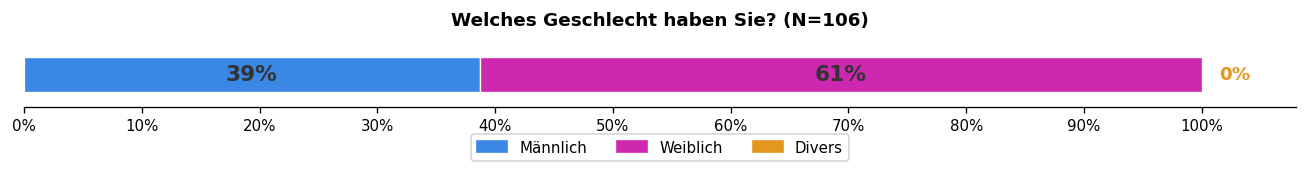

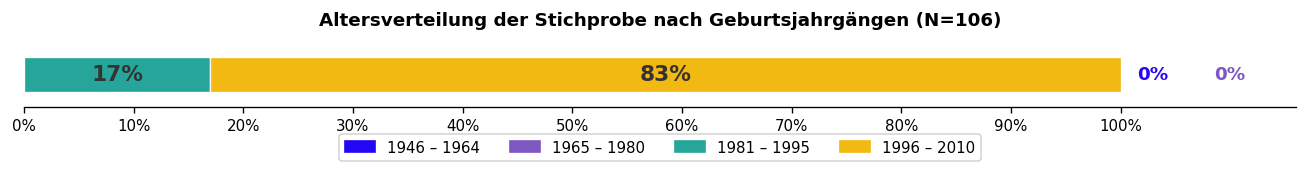

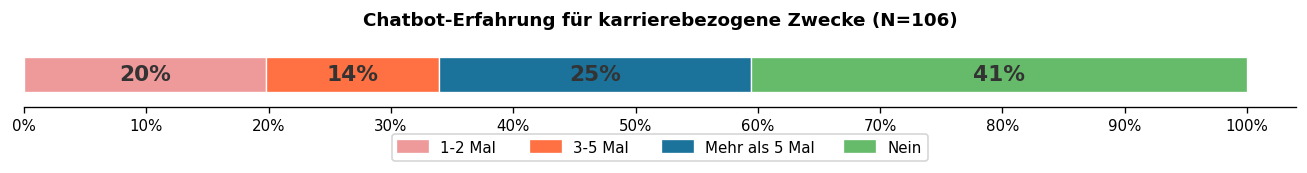

In [14]:
import matplotlib.patches as mpatches

# ── Farben & Reihenfolgen ─────────────────────────────────────────────────────
GESCHLECHT_ORDER  = ['Männlich', 'Weiblich', 'Divers']
GESCHLECHT_COLORS = {'Männlich': "#3a87e5", 'Weiblich': "#cf28b0", 'Divers': "#e3971e"}

# Echte Werte aus dem DataFrame (inkl. trailing spaces wo vorhanden)
JAHRGANG_ORDER  = ['1946 – 1964', '1965 – 1980', '1981 – 1995 ', '1996 – 2010 ']
JAHRGANG_LABELS = ['1946 – 1964', '1965 – 1980', '1981 – 1995',  '1996 – 2010' ]  # für Legende (ohne trailing space)
JAHRGANG_COLORS = ["#2408f5", '#7e57c2', '#26a69a', "#f1b912"]

CHATBOT_ORDER  = ['1-2 Mal ', '3-5 Mal ', 'Mehr als 5 Mal','Nein' ]
CHATBOT_LABELS = ['1-2 Mal ', '3-5 Mal ', 'Mehr als 5 Mal','Nein' ]  # für Legende (ohne trailing space)
CHATBOT_COLORS = ['#ef9a9a', '#ff7043', "#1b739c", '#66bb6a']


def _single_bar_chart(ax, order, color_map_or_list, series, title, n_total):
    """
    Horizontales Balkendiagramm – ein Balken pro Kategorie.
    Prozentwert + n rechts vom Balken. Stil analog Beispielbild.
    """
    counts = series.value_counts()
    # Nur vorhandene Kategorien, in der gewünschten Reihenfolge
    cats   = [c for c in order if c in counts.index]
    vals   = [counts[c] for c in cats]
    total  = sum(vals)
    pcts   = [v / total * 100 for v in vals]

    if isinstance(color_map_or_list, dict):
        colors = [color_map_or_list[c] for c in cats]
    else:
        colors = color_map_or_list[:len(cats)]

    y_pos = range(len(cats))
    bars  = ax.barh(list(y_pos), pcts, color=colors,
                    edgecolor='white', linewidth=0.8, height=0.55)

    # Labels rechts vom Balken
    for i, (pct, n) in enumerate(zip(pcts, vals)):
        ax.text(pct + 1.0, i, f'{pct:.0f}%  (n={n})',
                va='center', fontsize=9.5)

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(cats, fontsize=9.5)
    ax.set_xlim(0, 115)
    ax.set_xlabel('%', fontsize=9)
    ax.set_title(f'{title} (N={n_total})', fontsize=11, fontweight='bold')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    


def _stacked_100_bar(ax, order, color_map, pct_dict, title, n_total, labels=None):
    """
    Einzelner horizontaler 100%-Balken – identischer Stil für alle
    demographischen Variablen. Alle Kategorien inkl. 0% werden angezeigt.

    0%-Segmente: kein sichtbarer Balken, aber das Label wird als
    Annotation knapp rechts neben dem letzten Balken angezeigt.
    """
    left        = 0.0
    zero_labels = []   # (x_position, label_text, color) für 0%-Kategorien

    for kat in order:
        pct   = pct_dict.get(kat, 0.0)
        color = color_map[kat]

        if pct > 0:
            # Normales Segment zeichnen
            ax.barh(0, pct, left=left, height=0.55,
                    color=color, edgecolor='white', linewidth=0.8)
            ax.text(left + pct / 2, 0, f'{pct:.0f}%',
                    ha='center', va='center',
                    fontsize=13, fontweight='bold', color='#333333')
            left += pct
        else:
            # 0%-Segment: merken für Annotation außerhalb
            zero_labels.append((color, kat))

    # 0%-Labels rechts neben dem Balken, nebeneinander gestaffelt
    x_ann = 101.5
    for color, kat in zero_labels:
        ax.text(x_ann, 0, '0%',
                ha='left', va='center',
                fontsize=11, fontweight='bold', color=color)
        x_ann += 7.0   # nächstes Label weiter rechts

    ax.set_xlim(0, 100 + max(8 * len(zero_labels), 4))
    ax.set_ylim(-0.5, 0.5)
    ax.set_yticks([])
    ax.set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%' if x <= 100 else ''))
    ax.tick_params(axis='x', labelsize=9)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
   
    ax.set_title(f'{title} (N={n_total})',
                 fontsize=11, fontweight='bold', pad=10)
    display_labels = labels if labels is not None else order
    legend_handles = [mpatches.Patch(color=color_map[k], label=l) for k, l in zip(order, display_labels)]
    ax.legend(handles=legend_handles, loc='upper center',
              bbox_to_anchor=(0.5, -0.30),
              ncol=len(order), fontsize=9,
              frameon=True, edgecolor='#cccccc')




# ══════════════════════════════════════════════════════
# 1) GESCHLECHT  –  100%-Balken via _stacked_100_bar (gleich wie Jahrgang)
# ══════════════════════════════════════════════════════
gf_counts = df_valid['geschlecht'].value_counts()
total_g   = gf_counts.sum()
gf_pct    = {k: (gf_counts.get(k, 0) / total_g * 100) for k in GESCHLECHT_ORDER}

fig1, ax1 = plt.subplots(figsize=(11, 1.8))
_stacked_100_bar(ax1,
                 order=GESCHLECHT_ORDER,
                 color_map=GESCHLECHT_COLORS,
                 pct_dict=gf_pct,
                 title='Welches Geschlecht haben Sie?',
                 n_total=N)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════
# 2) JAHRGANG  –  100%-Balken (gleicher Stil wie Geschlecht & Chatbot)
# ══════════════════════════════════════════════════════
jf_counts = df_valid['jahrgang'].value_counts()

# ALLE vier Jahrgänge anzeigen – auch solche mit 0 Antworten
# pct_dict enthält für jeden Jahrgang einen Wert (0.0 wenn nicht vorhanden)
total_j   = jf_counts.sum()
jf_pct    = {k: (jf_counts.get(k, 0) / total_j * 100) for k in JAHRGANG_ORDER}
JAHRGANG_COLOR_MAP = dict(zip(JAHRGANG_ORDER, JAHRGANG_COLORS))

fig2, ax2 = plt.subplots(figsize=(11, 1.8))
_stacked_100_bar(ax2,
                 order=JAHRGANG_ORDER,
                 color_map=JAHRGANG_COLOR_MAP,
                 pct_dict=jf_pct,
                 title='Altersverteilung der Stichprobe nach Geburtsjahrgängen',
                 n_total=N,
                 labels=JAHRGANG_LABELS)
plt.tight_layout()
plt.show()

# 3) CHATBOT-ERFAHRUNG  –  100%-Balken (gleicher Stil wie Geschlecht & Jahrgang)
# ══════════════════════════════════════════════════════
cf_counts = df_valid['chatbot_nutzung'].value_counts()

# ALLE Kategorien anzeigen – auch solche mit 0 Antworten
total_c  = cf_counts.sum()
cf_pct   = {k: (cf_counts.get(k, 0) / total_c * 100) for k in CHATBOT_ORDER}
CHATBOT_COLOR_MAP = dict(zip(CHATBOT_ORDER, CHATBOT_COLORS))

fig3, ax3 = plt.subplots(figsize=(11, 1.8))
_stacked_100_bar(ax3,
                 order=CHATBOT_ORDER,
                 color_map=CHATBOT_COLOR_MAP,
                 pct_dict=cf_pct,
                 title='Chatbot-Erfahrung für karrierebezogene Zwecke',
                 n_total=N,
                 labels=CHATBOT_LABELS)
plt.tight_layout()
plt.show()


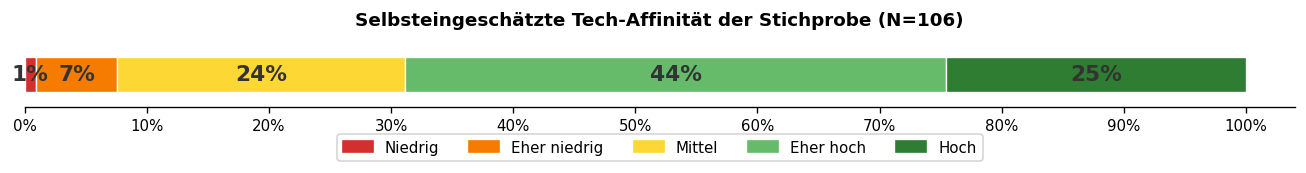

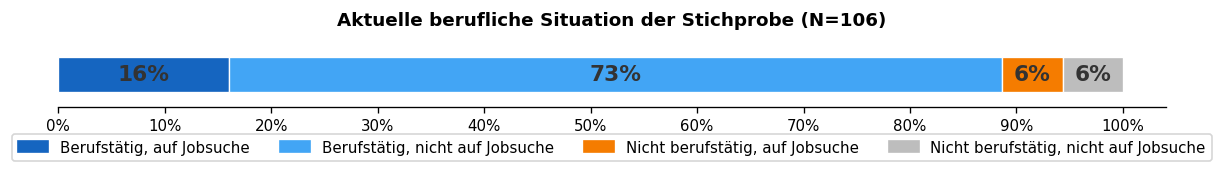

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# 4) TECH-AFFINITÄT  –  100%-Balken
# ══════════════════════════════════════════════════════════════════════════════

# Echte Werte aus dem DataFrame (Spalte: 'Wie schätzen Sie Ihre Tech-Affinität ein?')
# gemappt auf: 'tech_affinitaet'
TECH_ORDER  = ['Niedrig', 'Eher niedrig', 'Mittel', 'Eher hoch', 'Hoch']
TECH_COLORS = {
    'Niedrig':     '#d32f2f',   # Dunkelrot
    'Eher niedrig':'#f57c00',   # Orange
    'Mittel':      '#fdd835',   # Gelb
    'Eher hoch':   '#66bb6a',   # Hellgrün
    'Hoch':        '#2e7d32',   # Dunkelgrün
}

tech_counts = df_valid['tech_affinitaet'].value_counts()
total_tech  = tech_counts.sum()
tech_pct    = {k: (tech_counts.get(k, 0) / total_tech * 100) for k in TECH_ORDER}

fig4, ax4 = plt.subplots(figsize=(11, 1.8))
_stacked_100_bar(ax4,
                 order=TECH_ORDER,
                 color_map=TECH_COLORS,
                 pct_dict=tech_pct,
                 title='Selbsteingeschätzte Tech-Affinität der Stichprobe',
                 n_total=N)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 5) BERUFLICHE SITUATION  –  100%-Balken
# ══════════════════════════════════════════════════════════════════════════════

# Echte Werte aus dem DataFrame (inkl. trailing spaces wo vorhanden)
# Spalte: 'Wie ist Ihre aktuelle berufliche Situation? '
# gemappt auf: 'beruf_situation'
BERUF_ORDER  = [
    'Berufstätig, auf Jobsuche ',
    'Berufstätig, nicht auf Jobsuche ',
    'Nicht berufstätig, auf Jobsuche ',
    'Nicht berufstätig, nicht auf Jobsuche',
]
BERUF_LABELS = [
    'Berufstätig, auf Jobsuche',
    'Berufstätig, nicht auf Jobsuche',
    'Nicht berufstätig, auf Jobsuche',
    'Nicht berufstätig, nicht auf Jobsuche',
]
BERUF_COLORS = {
    'Berufstätig, auf Jobsuche ':             '#1565c0',   # Dunkelblau
    'Berufstätig, nicht auf Jobsuche ':       '#42a5f5',   # Hellblau
    'Nicht berufstätig, auf Jobsuche ':       '#f57c00',   # Orange
    'Nicht berufstätig, nicht auf Jobsuche':  '#bdbdbd',   # Grau
}

beruf_counts = df_valid['beruf_situation'].value_counts()
total_beruf  = beruf_counts.sum()
beruf_pct    = {k: (beruf_counts.get(k, 0) / total_beruf * 100) for k in BERUF_ORDER}

fig5, ax5 = plt.subplots(figsize=(11, 1.8))
_stacked_100_bar(ax5,
                 order=BERUF_ORDER,
                 color_map=BERUF_COLORS,
                 pct_dict=beruf_pct,
                 title='Aktuelle berufliche Situation der Stichprobe',
                 n_total=N,
                 labels=BERUF_LABELS)
plt.tight_layout()
plt.show()


---
## 2. Reliabilität aller Konstrukte – Cronbach's α (F1–F13)

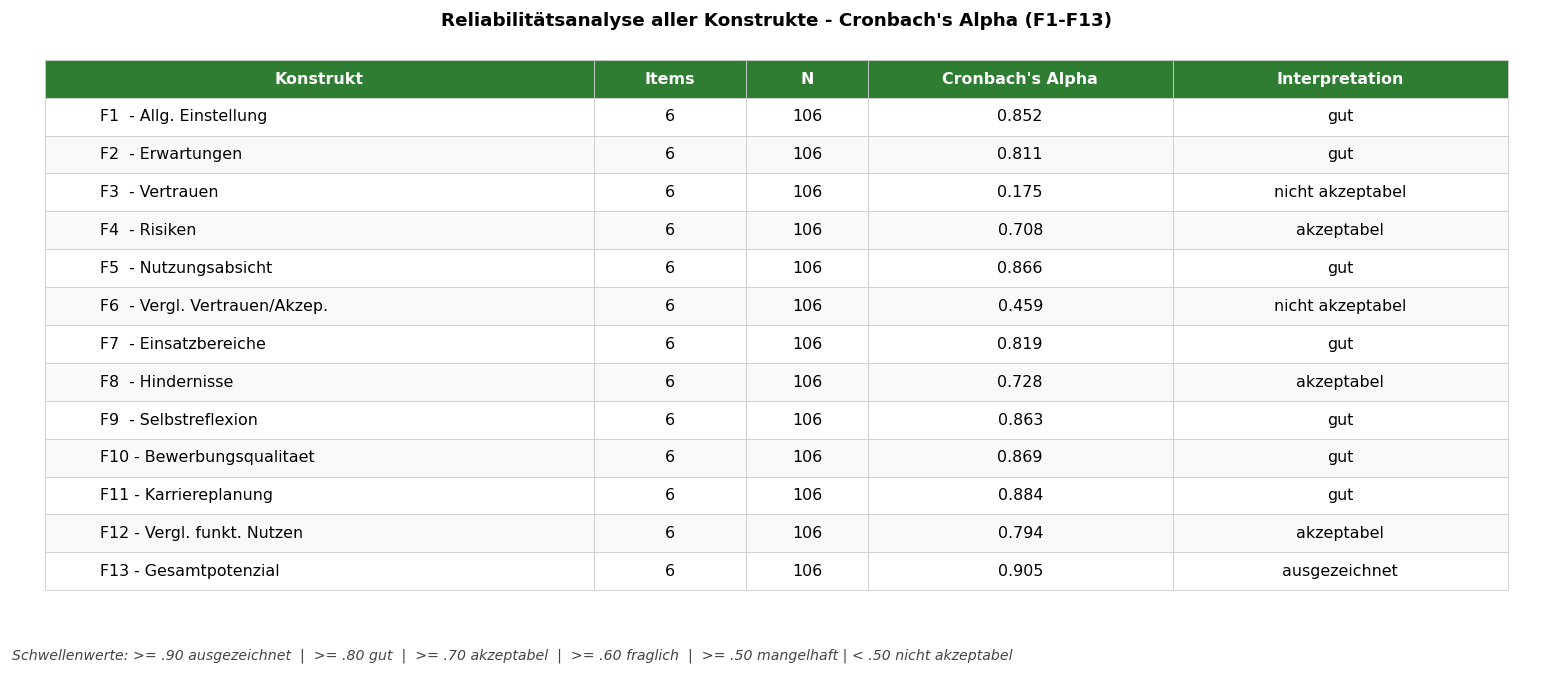

In [16]:
# Uebersichtstabelle: Cronbach's Alpha fuer alle Konstrukte F1-F13

skalen_alpha_all = [
    ('F1  - Allg. Einstellung',       f1_cols),
    ('F2  - Erwartungen',             f2_cols),
    ('F3  - Vertrauen',               f3_cols),
    ('F4  - Risiken',                 f4_cols),
    ('F5  - Nutzungsabsicht',         f5_cols),
    ('F6  - Vergl. Vertrauen/Akzep.', f6_cols),
    ('F7  - Einsatzbereiche',         f7_cols),
    ('F8  - Hindernisse',             f8_cols),
    ('F9  - Selbstreflexion',         f9_cols),
    ('F10 - Bewerbungsqualitaet',     f10_cols),
    ('F11 - Karriereplanung',         f11_cols),
    ('F12 - Vergl. funkt. Nutzen',    f12_cols),
    ('F13 - Gesamtpotenzial',         f13_cols),
]

alpha_rows = []
for label, cols in skalen_alpha_all:
    items_avail = [c for c in cols if c in df_valid.columns]
    a = cronbach_alpha(df_valid[items_avail])
    if np.isnan(a):   interp = '-'
    elif a >= .90:    interp = 'ausgezeichnet'
    elif a >= .80:    interp = 'gut'
    elif a >= .70:    interp = 'akzeptabel'
    elif a >= .60:    interp = 'fraglich'
    elif a >= .50:    interp = 'mangelhaft'
    else:             interp = 'nicht akzeptabel'
    alpha_rows.append([
        label,
        len(items_avail),
        df_valid[items_avail].dropna().shape[0],
        f'{a:.3f}',
        interp
    ])

# Keine Schwellenwert-Zeile in der Tabelle
# -> wird als fig.text unter der Tabelle ausgegeben

HDR_COL  = '#2e7d32'
ROW_ODD  = '#ffffff'
ROW_EVEN = '#f9f9f9'

col_labels_a = ['Konstrukt', 'Items', 'N', "Cronbach's Alpha", 'Interpretation']
col_widths_a = [0.36, 0.10, 0.08, 0.20, 0.22]

n_data_a = len(alpha_rows)
fig_h_a  = 0.45 * n_data_a - 0.5
fig, ax = plt.subplots(figsize=(13, fig_h_a))
fig.patch.set_facecolor('white')
ax.axis('off')
ax.set_title("Reliabilitätsanalyse aller Konstrukte - Cronbach's Alpha (F1-F13)",
             fontsize=11, fontweight='bold', pad=4, loc='center')

tbl = ax.table(
    cellText  = alpha_rows,
    colLabels = col_labels_a,
    cellLoc   = 'center',
    loc       = 'center',
    colWidths = col_widths_a,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.6)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('#cccccc')
    cell.set_linewidth(0.5)
    if row == 0:
        cell.set_facecolor(HDR_COL)
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor(ROW_ODD if row % 2 != 0 else ROW_EVEN)
    if col == 0 and row > 0:
        cell.set_text_props(ha='left')
        cell._loc = 'left'

# Schwellenwerte als Text unter der Tabelle
fig.text(
    0.01, -0.02,
    'Schwellenwerte: >= .90 ausgezeichnet  |  >= .80 gut  |  >= .70 akzeptabel  |  >= .60 fraglich  |  >= .50 mangelhaft | < .50 nicht akzeptabel',
    fontsize=8.5, color='#444444', va='top', style='italic'
)

plt.tight_layout()
plt.show()


---
## 3. Gruppenvergleiche – Mann-Whitney-U-Test (F1–F13)

Vergleich Weiblich vs. Männlich auf Skalenmitttelwert-Ebene.

In [17]:
from scipy.stats import mannwhitneyu

def mwu_test(g1, g2):
    u_stat, p_val = mannwhitneyu(g1, g2, alternative='two-sided')
    n1, n2 = len(g1), len(g2)
    r_abs = abs(1 - (2 * u_stat / (n1 * n2)))
    return u_stat, p_val, r_abs

def sig_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'n.s.'

def interpret_r(r):
    if r < 0.1: return 'sehr klein'
    elif r < 0.2: return 'klein'
    elif r < 0.3: return 'mittel'
    elif r < 0.4: return 'gross'
    else: return 'sehr gross'

weiblich  = df_valid[df_valid['geschlecht'] == 'Weiblich']
maennlich = df_valid[df_valid['geschlecht'] == 'Männlich']

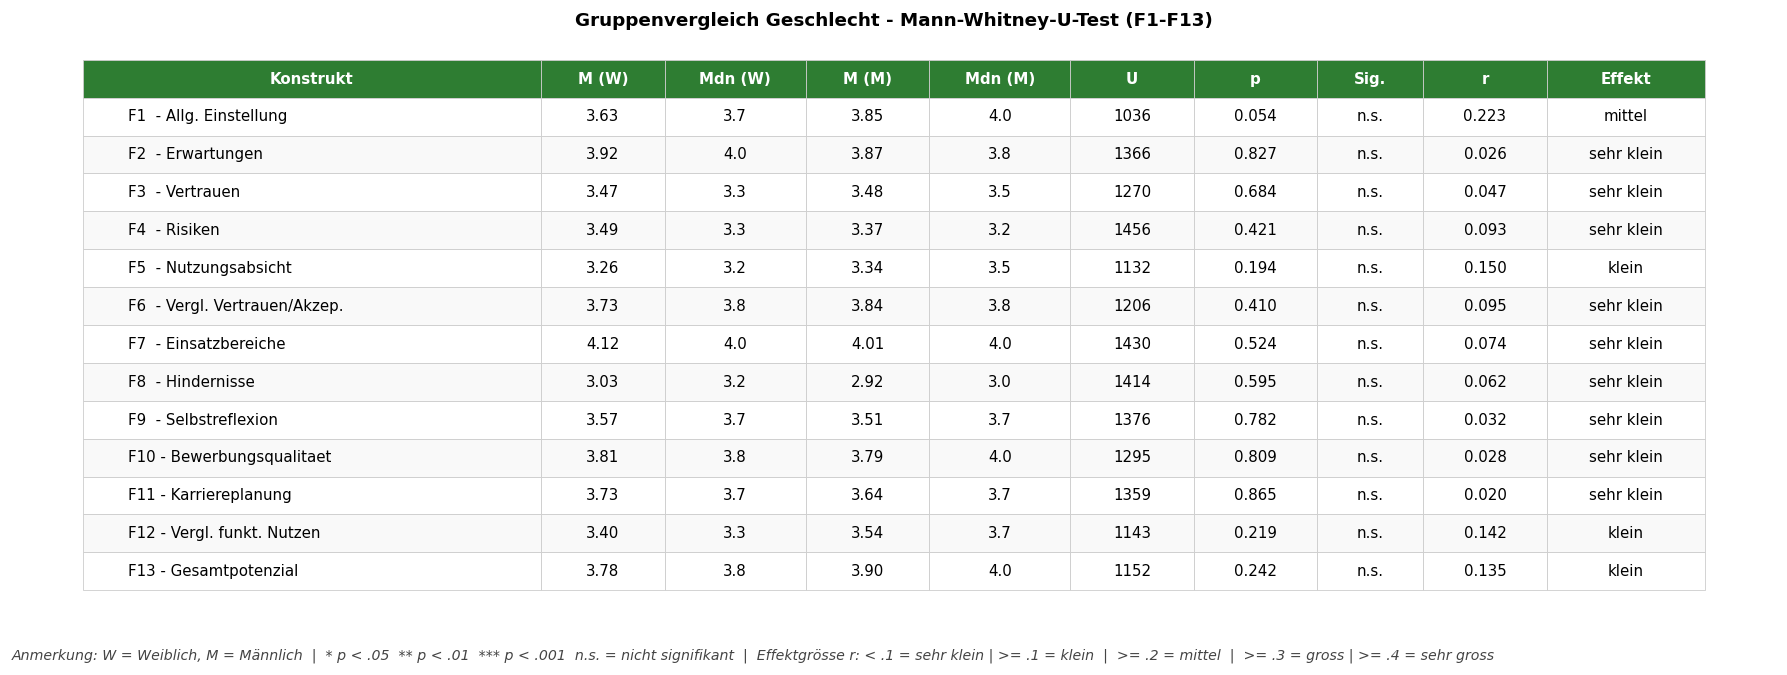

In [18]:
# Uebersichtstabelle: Mann-Whitney-U-Test fuer alle Konstrukte F1-F13
# Gruppenvergleich: Weiblich vs. Maennlich

skalen_mwu_all = [
    ('F1  - Allg. Einstellung',       'skala_f1'),
    ('F2  - Erwartungen',             'skala_f2'),
    ('F3  - Vertrauen',               'skala_f3'),
    ('F4  - Risiken',                 'skala_f4'),
    ('F5  - Nutzungsabsicht',         'skala_f5'),
    ('F6  - Vergl. Vertrauen/Akzep.', 'skala_f6'),
    ('F7  - Einsatzbereiche',         'skala_f7'),
    ('F8  - Hindernisse',             'skala_f8'),
    ('F9  - Selbstreflexion',         'skala_f9'),
    ('F10 - Bewerbungsqualitaet',     'skala_f10'),
    ('F11 - Karriereplanung',         'skala_f11'),
    ('F12 - Vergl. funkt. Nutzen',    'skala_f12'),
    ('F13 - Gesamtpotenzial',         'skala_f13'),
]

mwu_rows = []
p_vals   = []
for label, col in skalen_mwu_all:
    if col not in df_valid.columns:
        continue
    g_w = weiblich[col].dropna()
    g_m = maennlich[col].dropna()
    u, p, r = mwu_test(g_w, g_m) 
    p_vals.append(p)
    mwu_rows.append([
        label,
        f'{g_w.mean():.2f}', f'{g_w.median():.1f}',
        f'{g_m.mean():.2f}', f'{g_m.median():.1f}',
        f'{u:.0f}',
        f'{p:.3f}',
        sig_stars(p),
        f'{r:.3f}',
        interpret_r(r),
    ])

HDR_COL  = '#2e7d32'
ROW_ODD  = '#ffffff'
ROW_EVEN = '#f9f9f9'
SIG_COL  = '#fff9c4'

col_labels_m = ['Konstrukt',
                'M (W)', 'Mdn (W)',
                'M (M)', 'Mdn (M)',
                'U', 'p', 'Sig.', 'r', 'Effekt']
col_widths_m = [0.26, 0.07, 0.08, 0.07, 0.08, 0.07, 0.07, 0.06, 0.07, 0.09]

n_data_m = len(mwu_rows)
fig_h_m  = 0.45 * n_data_m - 0.5
fig2, ax2 = plt.subplots(figsize=(15, fig_h_m))
fig2.patch.set_facecolor('white')
ax2.axis('off')
ax2.set_title('Gruppenvergleich Geschlecht - Mann-Whitney-U-Test (F1-F13)',
              fontsize=11, fontweight='bold', pad=4, loc='center')

tbl2 = ax2.table(
    cellText  = mwu_rows,
    colLabels = col_labels_m,
    cellLoc   = 'center',
    loc       = 'center',
    colWidths = col_widths_m,
)
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(9.0)
tbl2.scale(1, 1.6)

for (row, col), cell in tbl2.get_celld().items():
    cell.set_edgecolor('#cccccc')
    cell.set_linewidth(0.5)
    if row == 0:
        cell.set_facecolor(HDR_COL)
        cell.set_text_props(color='white', fontweight='bold')
    else:
        try:
            p_val = float(p_vals[row - 1])
            bg = SIG_COL if p_val < .05 else (ROW_ODD if row % 2 != 0 else ROW_EVEN)
        except IndexError:
            bg = ROW_ODD
        cell.set_facecolor(bg)
    if col == 0 and row > 0:
        cell.set_text_props(ha='left')
        cell._loc = 'left'

fig2.text(
    0.01, -0.02,
    'Anmerkung: W = Weiblich, M = Männlich  |  * p < .05  ** p < .01  *** p < .001  n.s. = nicht signifikant  |  Effektgrösse r: < .1 = sehr klein | >= .1 = klein  |  >= .2 = mittel  |  >= .3 = gross | >= .4 = sehr gross',
    fontsize=8.5, color='#444444', va='top', style='italic'
)

plt.tight_layout()
plt.show()

In [19]:
skalen_alpha = [
    ('F1  – Allg. Einstellung',     f1_cols),
    ('F2  – Erwartungen',           f2_cols),
    ('F3  – Vertrauen',             f3_cols),
    ('F4  – Risiken',               f4_cols),
    ('F5  – Nutzungsabsicht',       f5_cols),
    ('F6  – Vergleich (Vertrauen)', f6_cols),
    ('F7  – Einsatzbereiche',       f7_cols),
    ('F8  – Hindernisse',           f8_cols),
    ('F9  – Selbstreflexion',       f9_cols),
    ('F10 – Bewerbungsqualität',    f10_cols),
    ('F11 – Karriereplanung',       f11_cols),
    ('F12 – Vergleich (funkt.)',    f12_cols),
    ('F13 – Gesamtpotenzial',       f13_cols),
]

print(f"{'Skala':<35} {'Items':>5} {'Cronbach α':>12} {'Interpretation'}")
print("-" * 70)
for label, cols in skalen_alpha:
    items_avail = [c for c in cols if c in df_valid.columns]
    alpha = cronbach_alpha(df_valid[items_avail])
    if np.isnan(alpha):
        interp = '-'


    elif alpha >= .90:    interp = 'ausgezeichnet'
    elif alpha >= .80:    interp = 'gut'
    elif alpha >= .70:    interp = 'akzeptabel'
    elif alpha >= .60:    interp = 'fraglich'
    elif alpha >= .50:    interp = 'mangelhaft'
    else:             interp = 'nicht akzeptabel'

    print(f"  {label:<33} {len(items_avail):>5} {alpha:>12.3f}  {interp}")


Skala                               Items   Cronbach α Interpretation
----------------------------------------------------------------------
  F1  – Allg. Einstellung               6        0.852  gut
  F2  – Erwartungen                     6        0.811  gut
  F3  – Vertrauen                       6        0.175  nicht akzeptabel
  F4  – Risiken                         6        0.708  akzeptabel
  F5  – Nutzungsabsicht                 6        0.866  gut
  F6  – Vergleich (Vertrauen)           6        0.459  nicht akzeptabel
  F7  – Einsatzbereiche                 6        0.819  gut
  F8  – Hindernisse                     6        0.728  akzeptabel
  F9  – Selbstreflexion                 6        0.863  gut
  F10 – Bewerbungsqualität              6        0.869  gut
  F11 – Karriereplanung                 6        0.884  gut
  F12 – Vergleich (funkt.)              6        0.794  akzeptabel
  F13 – Gesamtpotenzial                 6        0.905  ausgezeichnet


---
## 3. Methodische Entscheidung: Gruppenvergleiche

### Warum Mann-Whitney-U-Test?

Für den Vergleich zweier unabhängiger Gruppen (Weiblich vs. Männlich) stehen bei Likert-Daten zwei Verfahren zur Diskussion:

1. **Cohen's d** (parametrisch): Setzt Intervallskalenniveau und Normalverteilung voraus. Likert-Skalen gelten formal als Ordinalskalen, und mit n < 50 pro Gruppe ist die Normalverteilungsannahme kaum gesichert.

2. **Mann-Whitney-U-Test** (nicht-parametrisch): Vergleicht die Rangverteilungen zweier unabhängiger Gruppen ohne Normalverteilungsannahme. Geeignet für ordinale Daten (Likert-Skalen) und kleine bis mittlere Stichproben.

**Entscheidung: Mann-Whitney-U-Test**

Begründung: Bei Likert-Skalen (ordinales Skalenniveau) und nicht sicher normalverteilten Daten ist der Mann-Whitney-U-Test methodisch überlegen. Dies entspricht der wissenschaftlichen Empfehlung von *Sullivan & Artino (2013)* sowie *Norman (2010)*, die explizit auf die Problematik parametrischer Verfahren bei Likert-Daten hinweisen.





In [20]:
def mwu_test(g1, g2):
    """Mann-Whitney-U-Test + Effektgrösse r = Z/sqrt(N)."""
    g1, g2 = np.array(g1.dropna()), np.array(g2.dropna())
    if len(g1) < 3 or len(g2) < 3:
        return np.nan, np.nan, np.nan
    u_stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
    n = len(g1) + len(g2)
    # z-Wert aus U-Statistik
    mu_u = len(g1) * len(g2) / 2
    sigma_u = np.sqrt(len(g1) * len(g2) * (n + 1) / 12)
    z = (u_stat - mu_u) / sigma_u if sigma_u > 0 else 0
    r = abs(z) / np.sqrt(n)
    return u_stat, p, r

def interpret_r(r):
    if pd.isna(r): return '-'
    r = abs(r)
    if r < 0.1: return 'sehr klein'
    elif r < 0.2: return 'klein'
    elif r < 0.3: return 'mittel'
    elif r < 0.4: return 'gross'
    else: return 'sehr gross'

print("Mann-Whitney-U-Funktion geladen ✓")


Mann-Whitney-U-Funktion geladen ✓


---
## 4. Deskriptive Statistik – Begründung

### Warum Median und Standardabweichung?

Bei Likert-Skalen (ordinal skalierte Daten mit 5 Stufen) werden standardmässig folgende Kennwerte berechnet:

- **Mittelwert (M)**: Bei Likert-Skalen ist der Mittelwert eine nützliche Orientierungsgrösse, auch wenn er theoretisch nur bei Intervallskalenniveau exakt interpretierbar ist. In der sozialwissenschaftlichen Praxis wird er häufig ergänzend ausgewiesen (vgl. Norman, 2010).

- **Median (Mdn)**: Der Median ist der robusteste Lageparameter für Ordinaldaten, da er nicht durch Ausreisser verzerrt wird und das Zentrum der Rangverteilung korrekt beschreibt.

- **Standardabweichung (SD)**: Gibt die Streuung der Antworten an. Eine hohe SD bedeutet, dass die Teilnehmenden uneinheitlich geantwortet haben (heterogene Meinungen); eine niedrige SD signalisiert Konsens.

- **Top-2-Box (%)**: Anteil der Teilnehmenden, die „Stimme eher zu" (4) oder „Stimme zu" (5) gewählt haben. Dies ist ein in der Markt- und Sozialforschung verbreitetes Mass für die Zustimmungsquote.

> Hinweis: Top-2-Box = Kategorien 4+5, **nicht** die zwei häufigsten Kategorien.


---
## 5. Teil 1 – Nutzungsakzeptanz (F1–F8)

### F1 – Allgemeine Einstellung gegenüber Career Counseling Chatbots

In [21]:
f1_items = {
    'f1_ki_verstaendnis_n':       'Grundlegendes Verständnis von KI-Chatbots',
    'f1_bewerb_unterstuetzung_n': 'Sinnvolle Unterstützung im Bewerbungsprozess',
    'f1_zukunft_rolle_n':         'Wichtige Rolle in der Jobsuche (Zukunft)',
    'f1_wohl_nutzung_n':          'Wohlfühlen bei der Nutzung von Chatbots',
    'f1_offen_ausprobieren_n':    'Offen für Chatbots in der Jobsuche',
    'f1_keine_sorgen_n':          'Chatbot im Bewerbungsprozess bereitet keine Sorgen',
}
# item_comparison_table → siehe vollständige Auswertungszelle weiter unten

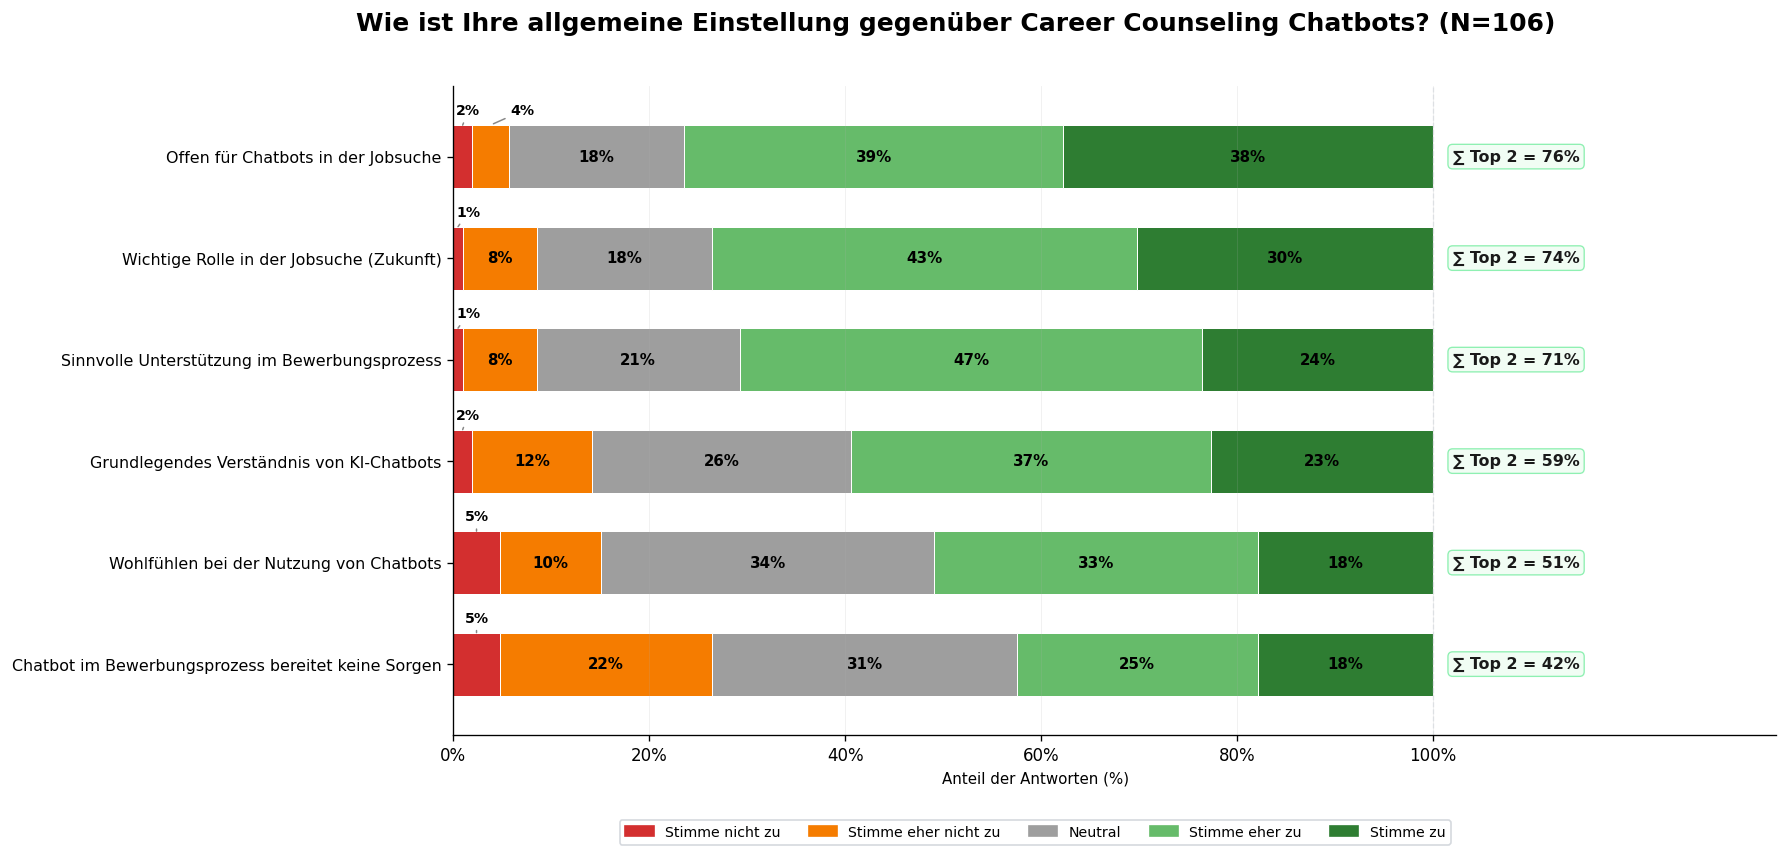

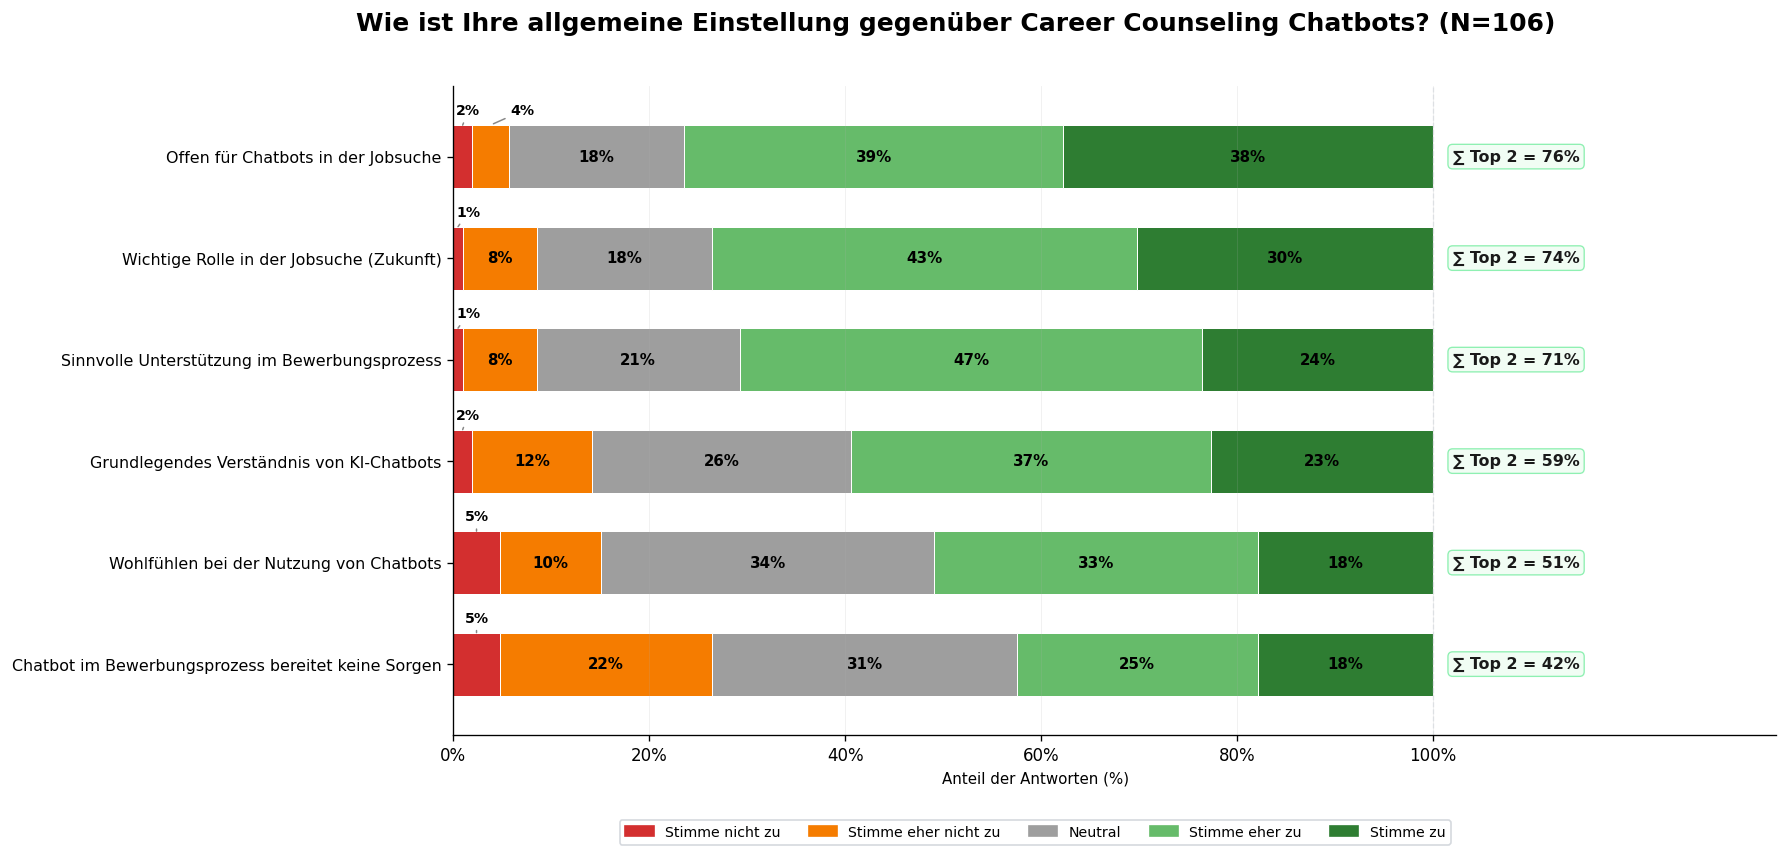

In [22]:
compact_likert_chart(df_valid, f1_items,
    title=f'Wie ist Ihre allgemeine Einstellung gegenüber Career Counseling Chatbots? (N={N})')


**Mann-Whitney-U-Test: Weiblich vs. Männlich (F1-Skalenmittelwert)**

In [23]:
u, p, r = mwu_test(weiblich['skala_f1'], maennlich['skala_f1'])
print(f"F1 – Allg. Einstellung: U={u:.0f}, p={p:.3f} {sig_stars(p)}, r={r:.3f} ({interpret_r(r)})")
print(f"  Weiblich:  M={weiblich['skala_f1'].mean():.2f}, Mdn={weiblich['skala_f1'].median():.1f}, SD={weiblich['skala_f1'].std():.2f}")
print(f"  Männlich:  M={maennlich['skala_f1'].mean():.2f}, Mdn={maennlich['skala_f1'].median():.1f}, SD={maennlich['skala_f1'].std():.2f}")


F1 – Allg. Einstellung: U=1036, p=0.054 n.s., r=0.187 (klein)
  Weiblich:  M=3.63, Mdn=3.7, SD=0.72
  Männlich:  M=3.85, Mdn=4.0, SD=0.80


### F2 – Erwartungen im Bewerbungsprozess

In [24]:
f2_items = {
    'f2_stellen_finden_n':            'Hilft, passende Stellen zu finden',
    'f2_effizienter_n':               'Bewerbungsprozess effizienter gestalten',
    'f2_infos_liefern_n':             'Nützliche Informationen liefern',
    'f2_fragen_erleichtern_n':        'Fragen zur Jobsuche erleichtern',
    'f2_faehigkeiten_einschaetzen_n': 'Nachgefragte Fähigkeiten einschätzen',
    'f2_verfuegbarkeit_n':            'Ständige Verfügbarkeit als Vorteil',
}
item_comparison_table(df_valid, f2_items,
    title=f'F2 – Erwartungen: Item-Vergleich (N={N})')



F2 – Erwartungen: Item-Vergleich (N=106)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Nützliche Informationen liefern,106,4.13,4.0,0.77,82
1,Ständige Verfügbarkeit als Vorteil,106,4.02,4.0,0.86,75
2,Fragen zur Jobsuche erleichtern,106,3.89,4.0,0.98,72
3,Nachgefragte Fähigkeiten einschätzen,106,3.78,4.0,0.98,71
4,Bewerbungsprozess effizienter gestalten,106,3.85,4.0,0.93,69
5,"Hilft, passende Stellen zu finden",106,3.75,4.0,1.00,67


  ► Höchster Top-2-Wert:   Nützliche Informationen liefern (82%)
  ► Tiefster  Top-2-Wert:  Hilft, passende Stellen zu finden (67%)
  ► Höchster Mittelwert:   Nützliche Informationen liefern (M=4.13)
  ► Höchste SD (Streuung): Hilft, passende Stellen zu finden (SD=1.00)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Nützliche Informationen liefern,106,4.13,4.0,0.77,82
1,Ständige Verfügbarkeit als Vorteil,106,4.02,4.0,0.86,75
2,Fragen zur Jobsuche erleichtern,106,3.89,4.0,0.98,72
3,Nachgefragte Fähigkeiten einschätzen,106,3.78,4.0,0.98,71
4,Bewerbungsprozess effizienter gestalten,106,3.85,4.0,0.93,69
5,"Hilft, passende Stellen zu finden",106,3.75,4.0,1.00,67


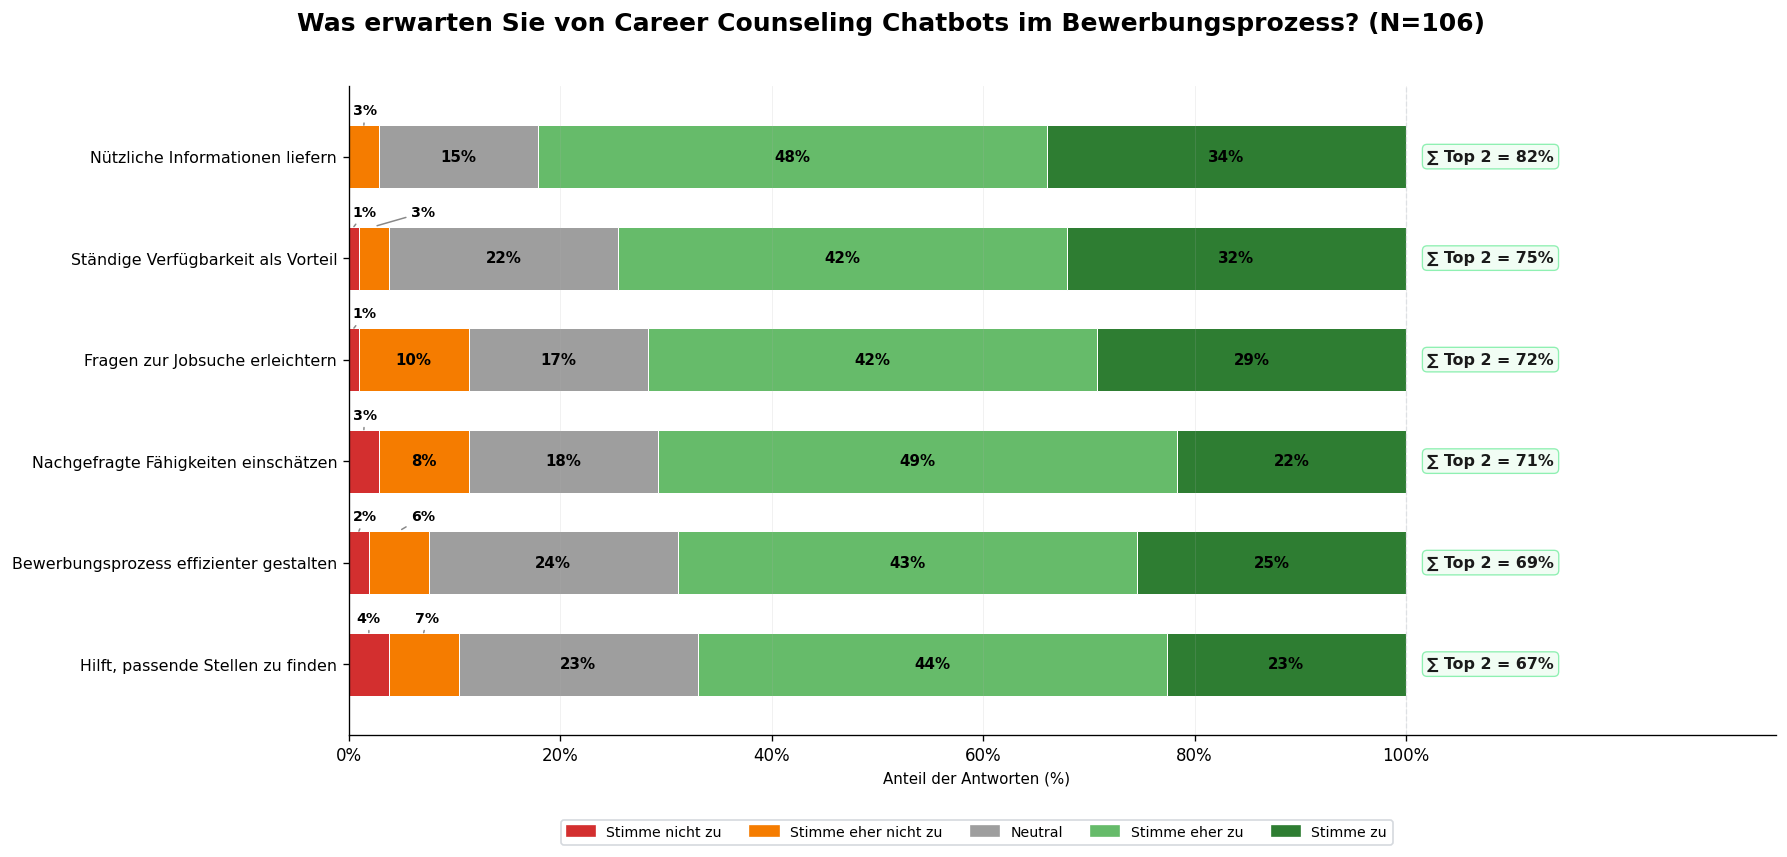

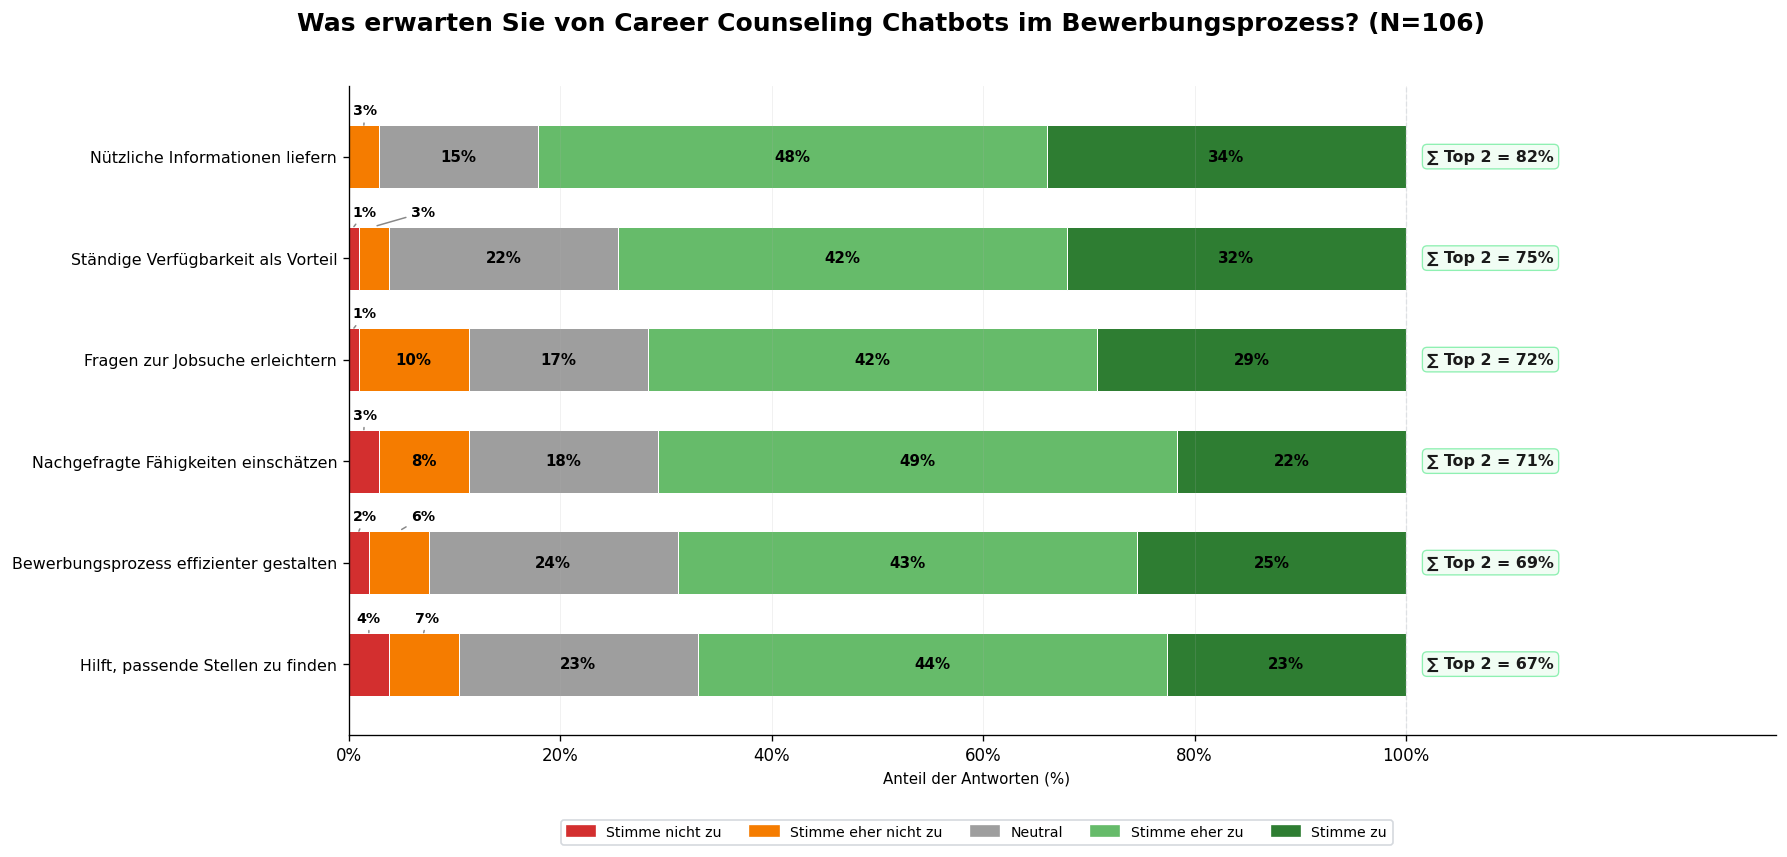

In [25]:
compact_likert_chart(df_valid, f2_items,
    title=f'Was erwarten Sie von Career Counseling Chatbots im Bewerbungsprozess? (N={N})')


In [26]:
u, p, r = mwu_test(weiblich['skala_f2'], maennlich['skala_f2'])
print(f"F2 – Erwartungen: U={u:.0f}, p={p:.3f} {sig_stars(p)}, r={r:.3f} ({interpret_r(r)})")
print(f"  Weiblich:  M={weiblich['skala_f2'].mean():.2f}, Mdn={weiblich['skala_f2'].median():.1f}, SD={weiblich['skala_f2'].std():.2f}")
print(f"  Männlich:  M={maennlich['skala_f2'].mean():.2f}, Mdn={maennlich['skala_f2'].median():.1f}, SD={maennlich['skala_f2'].std():.2f}")


F2 – Erwartungen: U=1366, p=0.827 n.s., r=0.021 (sehr klein)
  Weiblich:  M=3.92, Mdn=4.0, SD=0.60
  Männlich:  M=3.87, Mdn=3.8, SD=0.76


### Deskriptive Statistik für F1 - F13

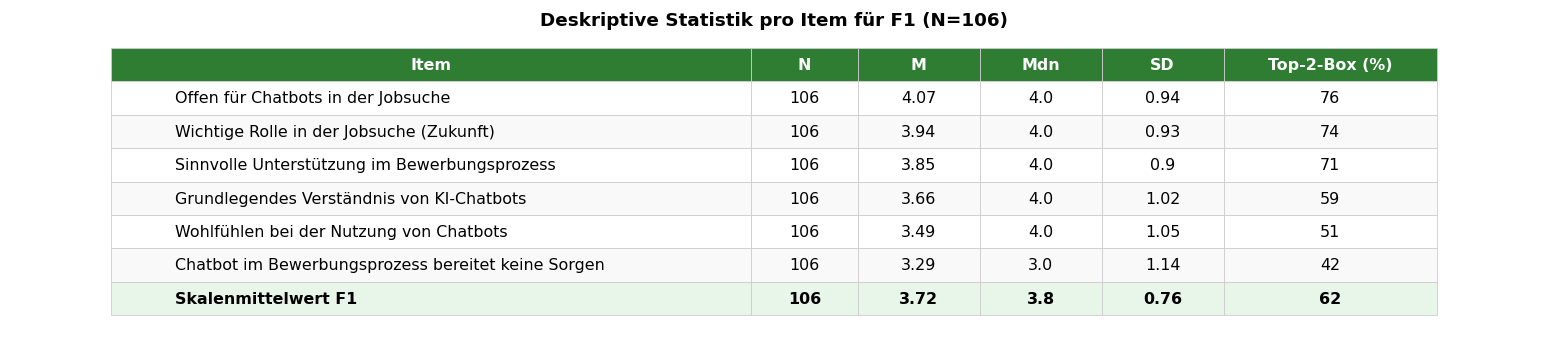

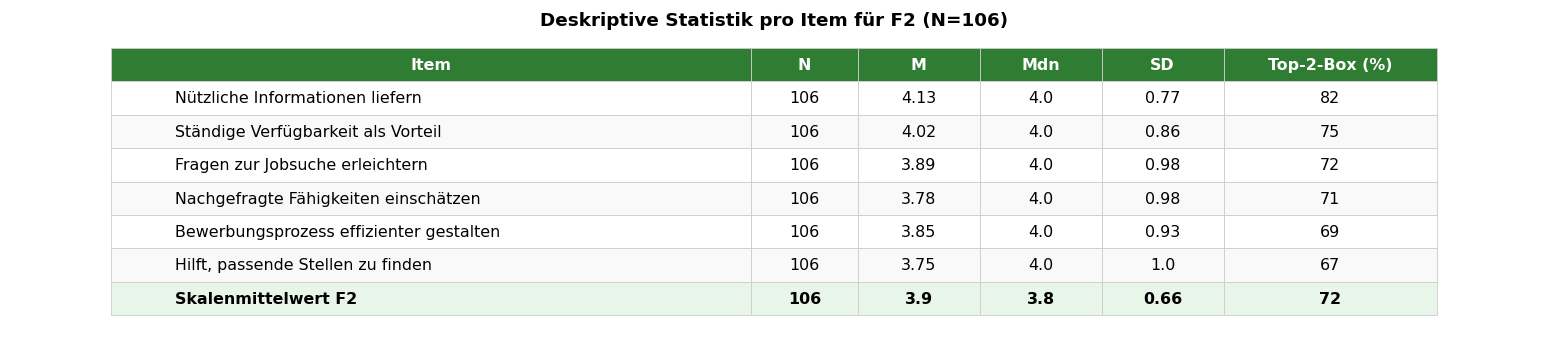

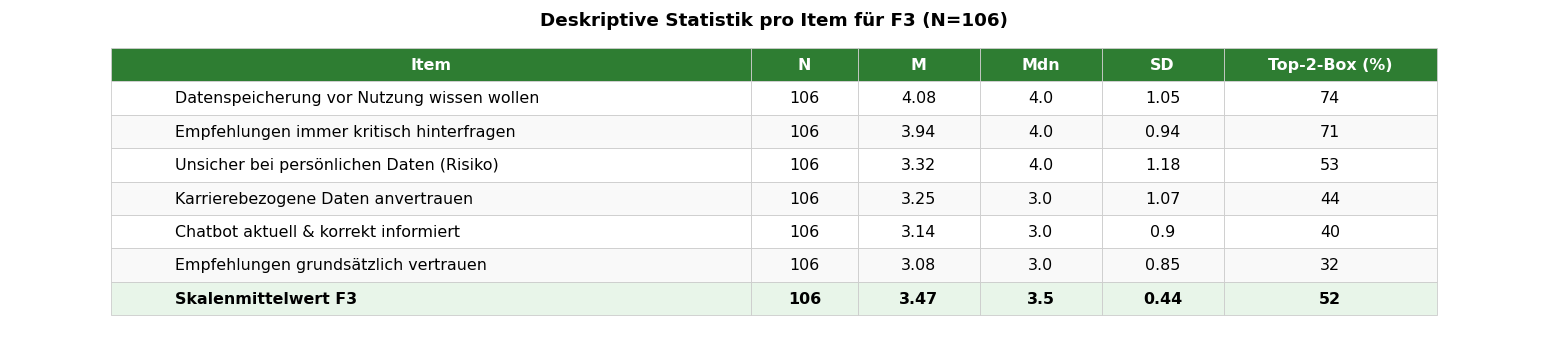

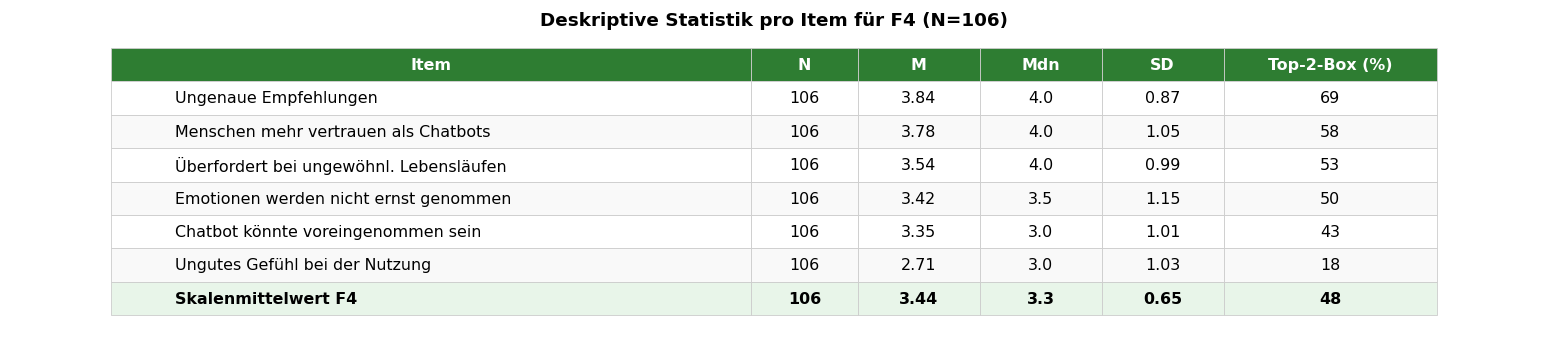

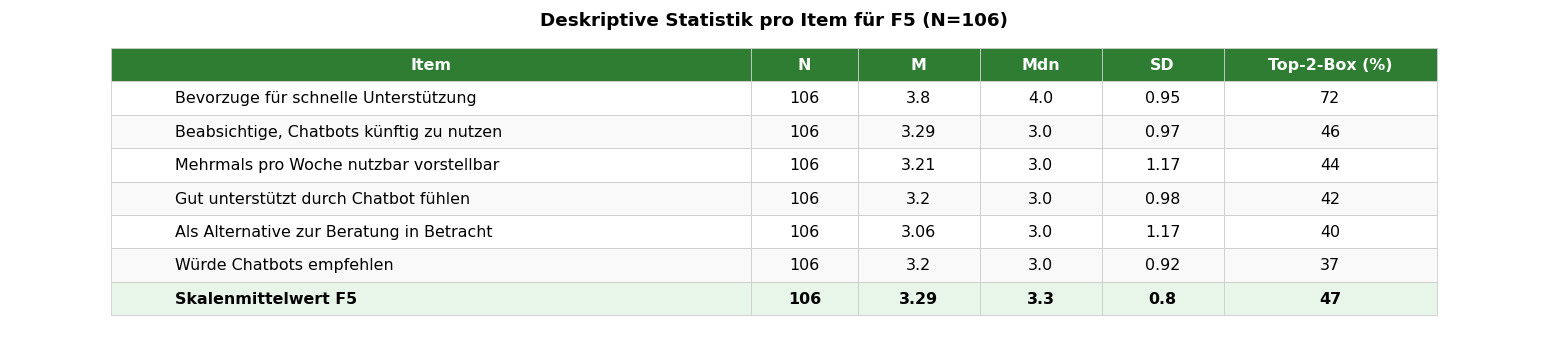

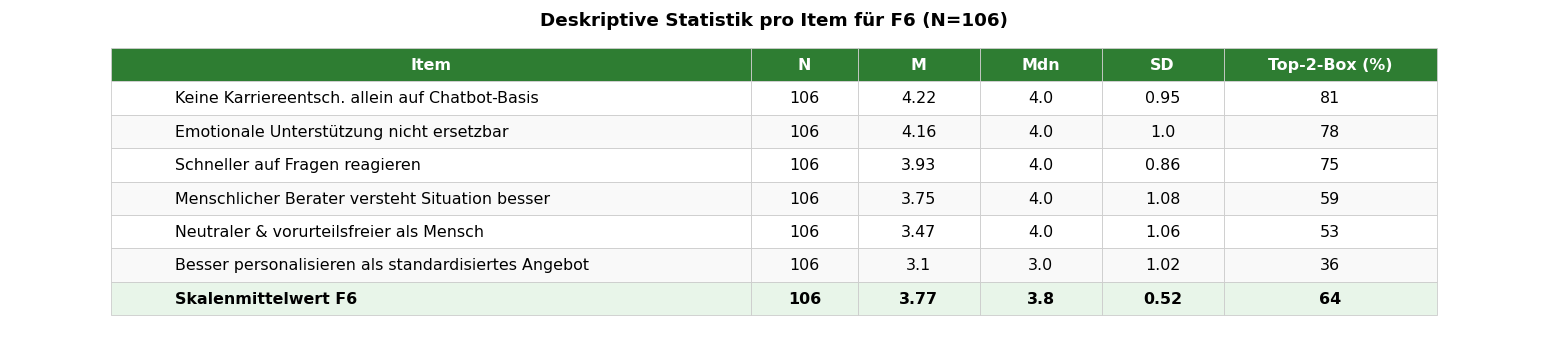

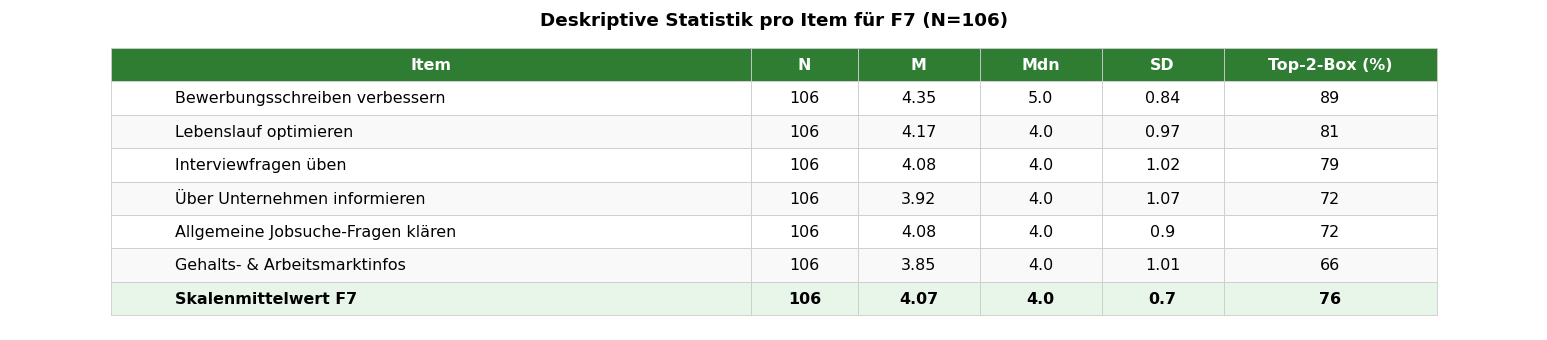

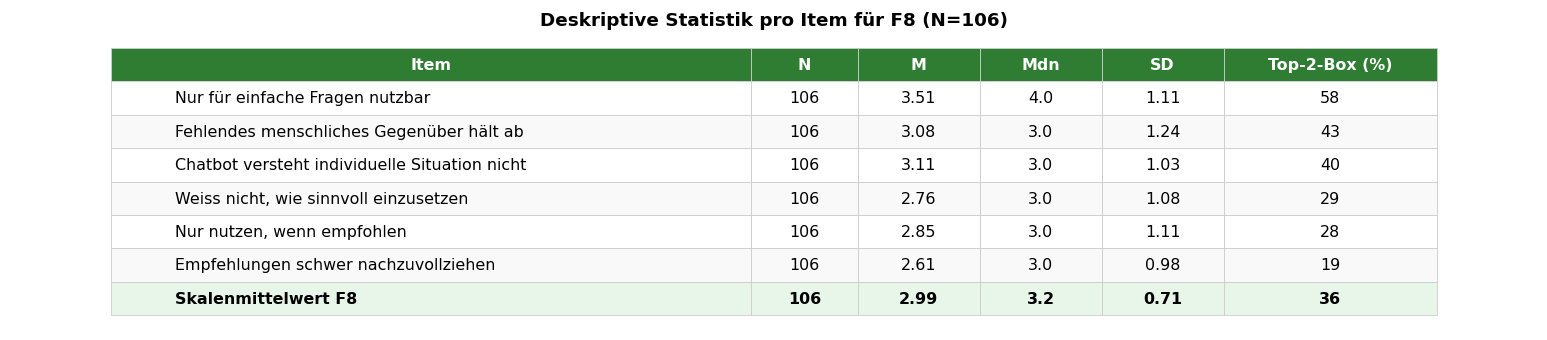

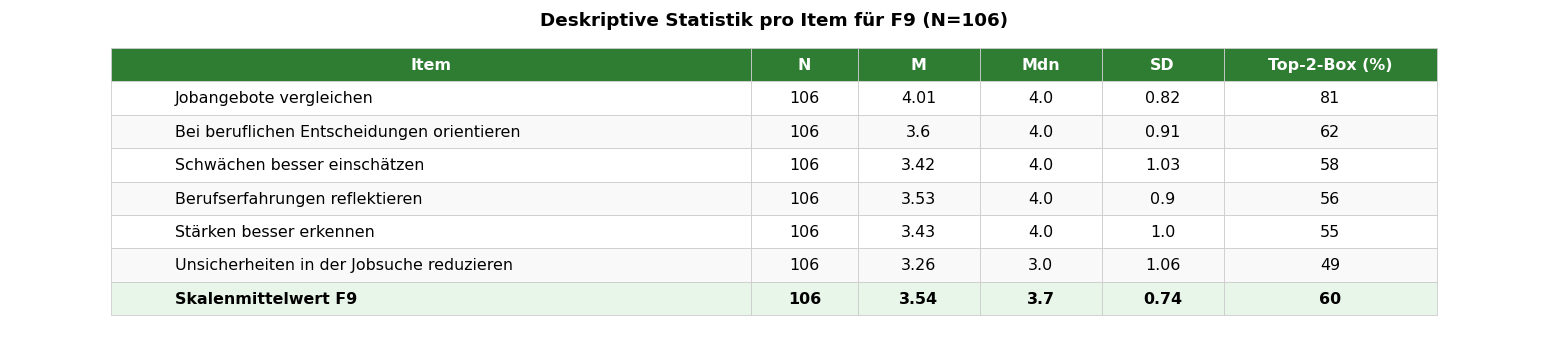

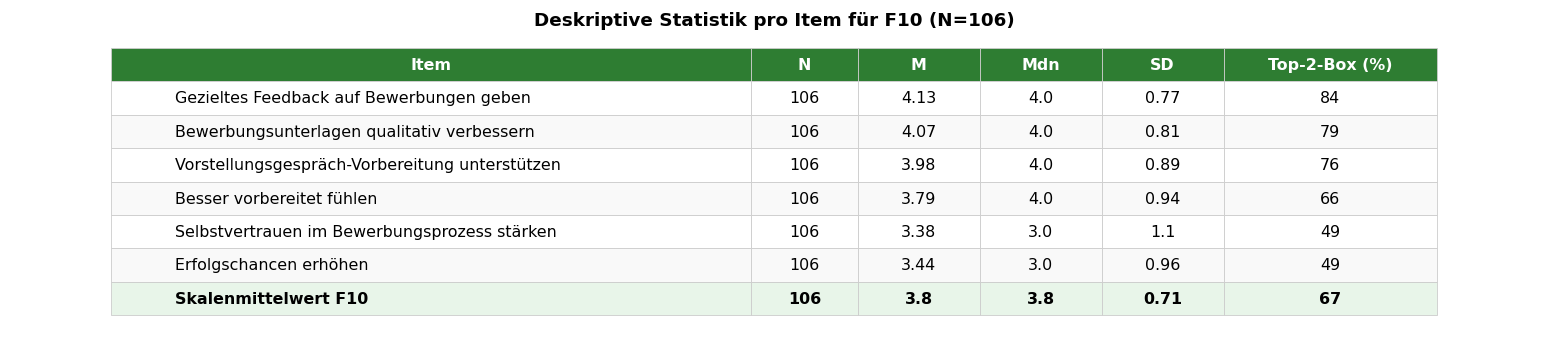

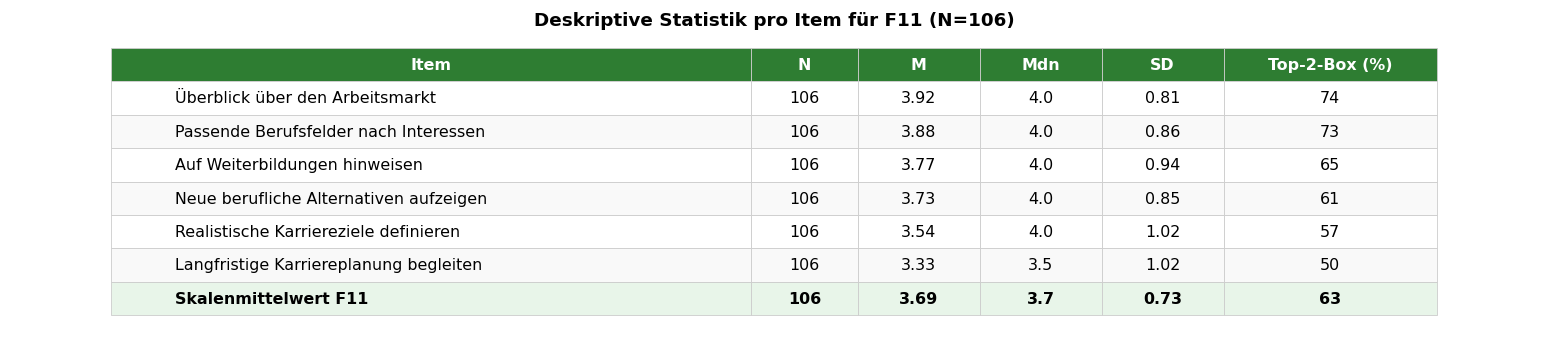

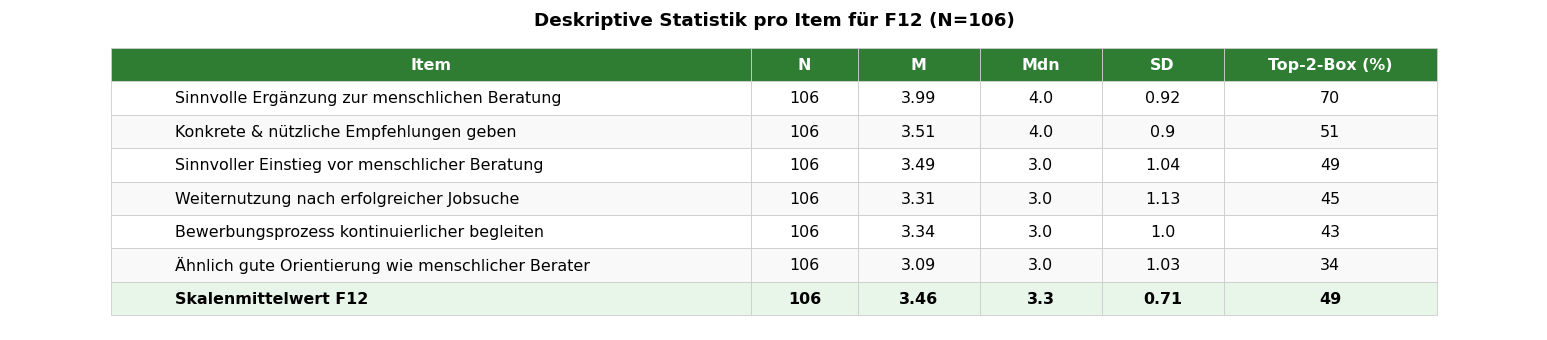

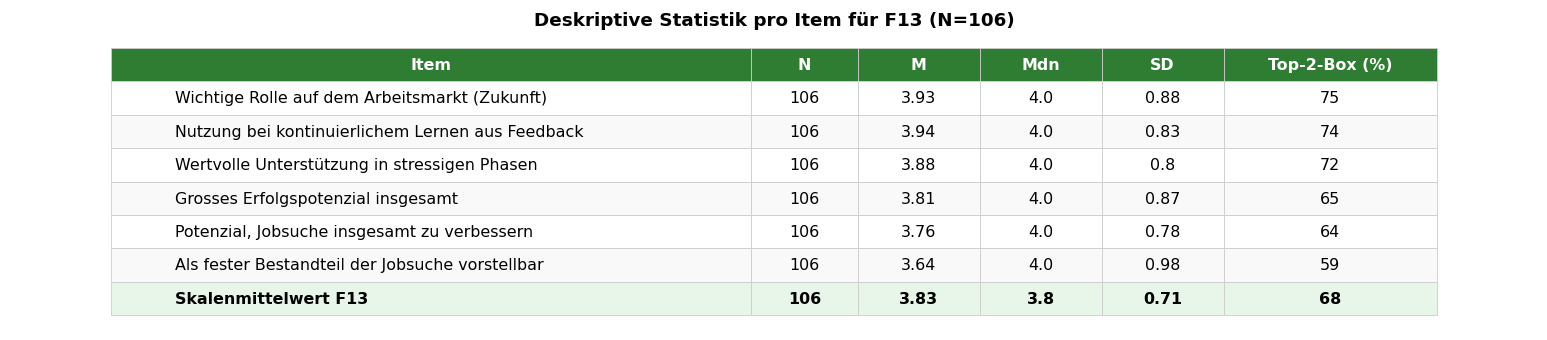

In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# HILFSFUNKTION – wiederverwendbar für alle Konstrukte
# ══════════════════════════════════════════════════════════════════════════════

def plot_desc_tabelle(items_dict, konstrukt_label, n_total):
    rows = []
    for col, label in items_dict.items():
        s = df_valid[col].dropna()
        rows.append({
            'Item':          label,
            'N':             len(s),
            'M':             round(s.mean(), 2),
            'Mdn':           round(s.median(), 1),
            'SD':            round(s.std(), 2),
            'Top-2-Box (%)': round(top2_box(s)),
        })

    desc_df = pd.DataFrame(rows).sort_values('Top-2-Box (%)', ascending=False).reset_index(drop=True)
    desc_df.index = range(1, len(desc_df) + 1)

    skala_vals = df_valid[[c for c in items_dict.keys()]].mean(axis=1)
    skala_top2 = round(sum(top2_box(df_valid[c]) for c in items_dict.keys()) / len(items_dict))

    skala_row = pd.DataFrame([{
        'Item':          f'Skalenmittelwert {konstrukt_label}',
        'N':             len(skala_vals.dropna()),
        'M':             round(skala_vals.mean(), 2),
        'Mdn':           round(skala_vals.median(), 1),
        'SD':            round(skala_vals.std(), 2),
        'Top-2-Box (%)': skala_top2,
    }], index=['∑'])

    desc_df_full = pd.concat([desc_df, skala_row])

    cols_show  = ['Item', 'N', 'M', 'Mdn', 'SD', 'Top-2-Box (%)']
    col_widths = [0.42, 0.07, 0.08, 0.08, 0.08, 0.14]
    n_rows     = len(desc_df_full)
    fig_h      = 0.42 * n_rows 

    fig, ax = plt.subplots(figsize=(13, fig_h))
    fig.patch.set_facecolor('white')
    ax.axis('off')
    ax.set_title(f'Deskriptive Statistik pro Item für {konstrukt_label} (N={n_total})',
                 fontsize=11, fontweight='bold', pad=6, loc='center')

    tbl = ax.table(
        cellText  = desc_df_full[cols_show].values,
        colLabels = cols_show,
        cellLoc   = 'center',
        loc       = 'center',
        colWidths = col_widths,
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9.5)
    tbl.scale(1, 1.55)

    HEADER_COLOR = '#2e7d32'
    ROW_EVEN     = '#f9f9f9'
    ROW_ODD      = '#ffffff'
    FOOTER_COLOR = '#e8f5e9'

    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor('#cccccc')
        cell.set_linewidth(0.5)
        if row == 0:
            cell.set_facecolor(HEADER_COLOR)
            cell.set_text_props(color='white', fontweight='bold', fontsize=9.5)
        elif row == n_rows:
            cell.set_facecolor(FOOTER_COLOR)
            cell.set_text_props(fontweight='bold')
        else:
            cell.set_facecolor(ROW_EVEN if row % 2 == 0 else ROW_ODD)
        if col == 0 and row > 0:
            cell.set_text_props(ha='left')
            cell._loc = 'left'

    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# F1 – Allgemeine Einstellung
# ══════════════════════════════════════════════════════════════════════════════
f1_items = {
    'f1_ki_verstaendnis_n':       'Grundlegendes Verständnis von KI-Chatbots',
    'f1_bewerb_unterstuetzung_n': 'Sinnvolle Unterstützung im Bewerbungsprozess',
    'f1_zukunft_rolle_n':         'Wichtige Rolle in der Jobsuche (Zukunft)',
    'f1_wohl_nutzung_n':          'Wohlfühlen bei der Nutzung von Chatbots',
    'f1_offen_ausprobieren_n':    'Offen für Chatbots in der Jobsuche',
    'f1_keine_sorgen_n':          'Chatbot im Bewerbungsprozess bereitet keine Sorgen',
}
plot_desc_tabelle(f1_items, 'F1', N)


# ══════════════════════════════════════════════════════════════════════════════
# F2 – Erwartungen im Bewerbungsprozess
# ══════════════════════════════════════════════════════════════════════════════
f2_items = {
    'f2_stellen_finden_n':            'Hilft, passende Stellen zu finden',
    'f2_effizienter_n':               'Bewerbungsprozess effizienter gestalten',
    'f2_infos_liefern_n':             'Nützliche Informationen liefern',
    'f2_fragen_erleichtern_n':        'Fragen zur Jobsuche erleichtern',
    'f2_faehigkeiten_einschaetzen_n': 'Nachgefragte Fähigkeiten einschätzen',
    'f2_verfuegbarkeit_n':            'Ständige Verfügbarkeit als Vorteil',
}
plot_desc_tabelle(f2_items, 'F2', N)


# ══════════════════════════════════════════════════════════════════════════════
# F3 – Vertrauen
# ══════════════════════════════════════════════════════════════════════════════
f3_items = {
    'f3_empf_vertrauen_n':        'Empfehlungen grundsätzlich vertrauen',
    'f3_aktuell_korrekt_n':       'Chatbot aktuell & korrekt informiert',
    'f3_daten_anvertrauen_n':     'Karrierebezogene Daten anvertrauen',
    'f3_kritisch_hinterfragen_n': 'Empfehlungen immer kritisch hinterfragen',
    'f3_unsicher_daten_n':        'Unsicher bei persönlichen Daten (Risiko)',
    'f3_daten_speicherung_n':     'Datenspeicherung vor Nutzung wissen wollen',
}
plot_desc_tabelle(f3_items, 'F3', N)


# ══════════════════════════════════════════════════════════════════════════════
# F4 – Risiken
# ══════════════════════════════════════════════════════════════════════════════
f4_items = {
    'f4_ungenaue_empf_n':          'Ungenaue Empfehlungen',
    'f4_voreingenommen_n':         'Chatbot könnte voreingenommen sein',
    'f4_ueberforderung_n':         'Überfordert bei ungewöhnl. Lebensläufen',
    'f4_emotionen_nicht_ernst_n':  'Emotionen werden nicht ernst genommen',
    'f4_ungutes_gefuehl_n':        'Ungutes Gefühl bei der Nutzung',
    'f4_menschen_mehr_vertrauen_n':'Menschen mehr vertrauen als Chatbots',
}
plot_desc_tabelle(f4_items, 'F4', N)


# ══════════════════════════════════════════════════════════════════════════════
# F5 – Nutzungsabsicht
# ══════════════════════════════════════════════════════════════════════════════
f5_items = {
    'f5_absicht_nutzen_n':        'Beabsichtige, Chatbots künftig zu nutzen',
    'f5_mehrmals_woche_n':        'Mehrmals pro Woche nutzbar vorstellbar',
    'f5_empfehlen_n':             'Würde Chatbots empfehlen',
    'f5_schnell_unkompliziert_n': 'Bevorzuge für schnelle Unterstützung',
    'f5_alternative_beratung_n':  'Als Alternative zur Beratung in Betracht',
    'f5_gut_unterstuetzt_n':      'Gut unterstützt durch Chatbot fühlen',
}
plot_desc_tabelle(f5_items, 'F5', N)


# ══════════════════════════════════════════════════════════════════════════════
# F6 – Vergleich menschliche Beratung: Vertrauen & Akzeptanz
# ══════════════════════════════════════════════════════════════════════════════
f6_items = {
    'f6_personalisierung_n':       'Besser personalisieren als standardisiertes Angebot',
    'f6_neutraler_n':              'Neutraler & vorurteilsfreier als Mensch',
    'f6_schneller_n':              'Schneller auf Fragen reagieren',
    'f6_kein_allein_entscheid_n':  'Keine Karriereentsch. allein auf Chatbot-Basis',
    'f6_mensch_versteht_besser_n': 'Menschlicher Berater versteht Situation besser',
    'f6_emotion_nicht_ersetzen_n': 'Emotionale Unterstützung nicht ersetzbar',
}
plot_desc_tabelle(f6_items, 'F6', N)


# ══════════════════════════════════════════════════════════════════════════════
# F7 – Einsatzbereiche
# ══════════════════════════════════════════════════════════════════════════════
f7_items = {
    'f7_lebenslauf_n':        'Lebenslauf optimieren',
    'f7_bewerbschreiben_n':   'Bewerbungsschreiben verbessern',
    'f7_interview_n':         'Interviewfragen üben',
    'f7_gehaltsinfos_n':      'Gehalts- & Arbeitsmarktinfos',
    'f7_unternehmen_infos_n': 'Über Unternehmen informieren',
    'f7_allg_fragen_n':       'Allgemeine Jobsuche-Fragen klären',
}
plot_desc_tabelle(f7_items, 'F7', N)


# ══════════════════════════════════════════════════════════════════════════════
# F8 – Hindernisse
# ══════════════════════════════════════════════════════════════════════════════
f8_items = {
    'f8_situation_nicht_verstehen_n': 'Chatbot versteht individuelle Situation nicht',
    'f8_empf_nicht_nachvollziehen_n': 'Empfehlungen schwer nachzuvollziehen',
    'f8_kein_mensch_gegenueber_n':    'Fehlendes menschliches Gegenüber hält ab',
    'f8_nicht_wie_einsetzen_n':       'Weiss nicht, wie sinnvoll einzusetzen',
    'f8_nur_einfache_fragen_n':       'Nur für einfache Fragen nutzbar',
    'f8_nur_wenn_empfohlen_n':        'Nur nutzen, wenn empfohlen',
}
plot_desc_tabelle(f8_items, 'F8', N)


# ══════════════════════════════════════════════════════════════════════════════
# F9 – Selbstreflexion & Entscheidungsfindung
# ══════════════════════════════════════════════════════════════════════════════
f9_items = {
    'f9_staerken_erkennen_n':         'Stärken besser erkennen',
    'f9_schwaechen_einschaetzen_n':   'Schwächen besser einschätzen',
    'f9_berufserf_reflektieren_n':    'Berufserfahrungen reflektieren',
    'f9_entscheidung_orientierung_n': 'Bei beruflichen Entscheidungen orientieren',
    'f9_unsicherheiten_reduzieren_n': 'Unsicherheiten in der Jobsuche reduzieren',
    'f9_jobangebote_vergleichen_n':   'Jobangebote vergleichen',
}
plot_desc_tabelle(f9_items, 'F9', N)


# ══════════════════════════════════════════════════════════════════════════════
# F10 – Bewerbungsqualität & Vorbereitung
# ══════════════════════════════════════════════════════════════════════════════
f10_items = {
    'f10_qualitaet_verbessern_n':               'Bewerbungsunterlagen qualitativ verbessern',
    'f10_gezieltes_feedback_n':                 'Gezieltes Feedback auf Bewerbungen geben',
    'f10_vorbereitung_vorstellungsgespraech_n': 'Vorstellungsgespräch-Vorbereitung unterstützen',
    'f10_besser_vorbereitet_fuehlen_n':         'Besser vorbereitet fühlen',
    'f10_selbstvertrauen_n':                    'Selbstvertrauen im Bewerbungsprozess stärken',
    'f10_erfolgschancen_n':                     'Erfolgschancen erhöhen',
}
plot_desc_tabelle(f10_items, 'F10', N)


# ══════════════════════════════════════════════════════════════════════════════
# F11 – Karriereplanung & Berufliche Orientierung
# ══════════════════════════════════════════════════════════════════════════════
f11_items = {
    'f11_alternativen_aufzeigen_n':  'Neue berufliche Alternativen aufzeigen',
    'f11_berufsfelder_passen_n':     'Passende Berufsfelder nach Interessen',
    'f11_arbeitsmarkt_ueberblick_n': 'Überblick über den Arbeitsmarkt',
    'f11_karriereziele_definieren_n':'Realistische Karriereziele definieren',
    'f11_langfristig_begleiten_n':   'Langfristige Karriereplanung begleiten',
    'f11_weiterbildung_hinweisen_n': 'Auf Weiterbildungen hinweisen',
}
plot_desc_tabelle(f11_items, 'F11', N)


# ══════════════════════════════════════════════════════════════════════════════
# F12 – Vergleich menschliche Beratung: Funktionaler Nutzen
# ══════════════════════════════════════════════════════════════════════════════
f12_items = {
    'f12_aehnlich_gut_n':            'Ähnlich gute Orientierung wie menschlicher Berater',
    'f12_kontinuierlicher_n':        'Bewerbungsprozess kontinuierlicher begleiten',
    'f12_konkrete_empfehlungen_n':   'Konkrete & nützliche Empfehlungen geben',
    'f12_sinnvolle_ergaenzung_n':    'Sinnvolle Ergänzung zur menschlichen Beratung',
    'f12_sinnvoller_einstieg_n':     'Sinnvoller Einstieg vor menschlicher Beratung',
    'f12_weiternutzen_nach_erfolg_n':'Weiternutzung nach erfolgreicher Jobsuche',
}
plot_desc_tabelle(f12_items, 'F12', N)


# ══════════════════════════════════════════════════════════════════════════════
# F13 – Gesamtbewertung & Erfolgspotenzial
# ══════════════════════════════════════════════════════════════════════════════
f13_items = {
    'f13_potenzial_jobsuche_n':        'Potenzial, Jobsuche insgesamt zu verbessern',
    'f13_fester_bestandteil_n':        'Als fester Bestandteil der Jobsuche vorstellbar',
    'f13_stressige_phasen_n':          'Wertvolle Unterstützung in stressigen Phasen',
    'f13_wichtige_rolle_zukunft_n':    'Wichtige Rolle auf dem Arbeitsmarkt (Zukunft)',
    'f13_lernend_nutzen_n':            'Nutzung bei kontinuierlichem Lernen aus Feedback',
    'f13_gesamtes_erfolgspotenzial_n': 'Grosses Erfolgspotenzial insgesamt',
}
plot_desc_tabelle(f13_items, 'F13', N)

### F3 umpolen

### F3 – Vertrauen in Career Counseling Chatbots

In [28]:
f3_items = {
    'f3_empf_vertrauen_n':       'Empfehlungen grundsätzlich vertrauen',
    'f3_aktuell_korrekt_n':      'Chatbot aktuell & korrekt informiert',
    'f3_daten_anvertrauen_n':    'Karrierebezogene Daten anvertrauen',
    'f3_kritisch_hinterfragen_n':'Empfehlungen immer kritisch hinterfragen',
    'f3_unsicher_daten_n':       'Unsicher bei persönlichen Daten (Risiko)',
    'f3_daten_speicherung_n':    'Datenspeicherung vor Nutzung wissen wollen',
}
item_comparison_table(df_valid, f3_items,
    title=f'F3 – Vertrauen: Item-Vergleich (N={N})')



F3 – Vertrauen: Item-Vergleich (N=106)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Datenspeicherung vor Nutzung wissen wollen,106,4.08,4.0,1.05,74
1,Empfehlungen immer kritisch hinterfragen,106,3.94,4.0,0.94,71
2,Unsicher bei persönlichen Daten (Risiko),106,3.32,4.0,1.18,53
3,Karrierebezogene Daten anvertrauen,106,3.25,3.0,1.07,44
4,Chatbot aktuell & korrekt informiert,106,3.14,3.0,0.90,40
5,Empfehlungen grundsätzlich vertrauen,106,3.08,3.0,0.85,32


  ► Höchster Top-2-Wert:   Datenspeicherung vor Nutzung wissen wollen (74%)
  ► Tiefster  Top-2-Wert:  Empfehlungen grundsätzlich vertrauen (32%)
  ► Höchster Mittelwert:   Datenspeicherung vor Nutzung wissen wollen (M=4.08)
  ► Höchste SD (Streuung): Unsicher bei persönlichen Daten (Risiko) (SD=1.18)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Datenspeicherung vor Nutzung wissen wollen,106,4.08,4.0,1.05,74
1,Empfehlungen immer kritisch hinterfragen,106,3.94,4.0,0.94,71
2,Unsicher bei persönlichen Daten (Risiko),106,3.32,4.0,1.18,53
3,Karrierebezogene Daten anvertrauen,106,3.25,3.0,1.07,44
4,Chatbot aktuell & korrekt informiert,106,3.14,3.0,0.90,40
5,Empfehlungen grundsätzlich vertrauen,106,3.08,3.0,0.85,32


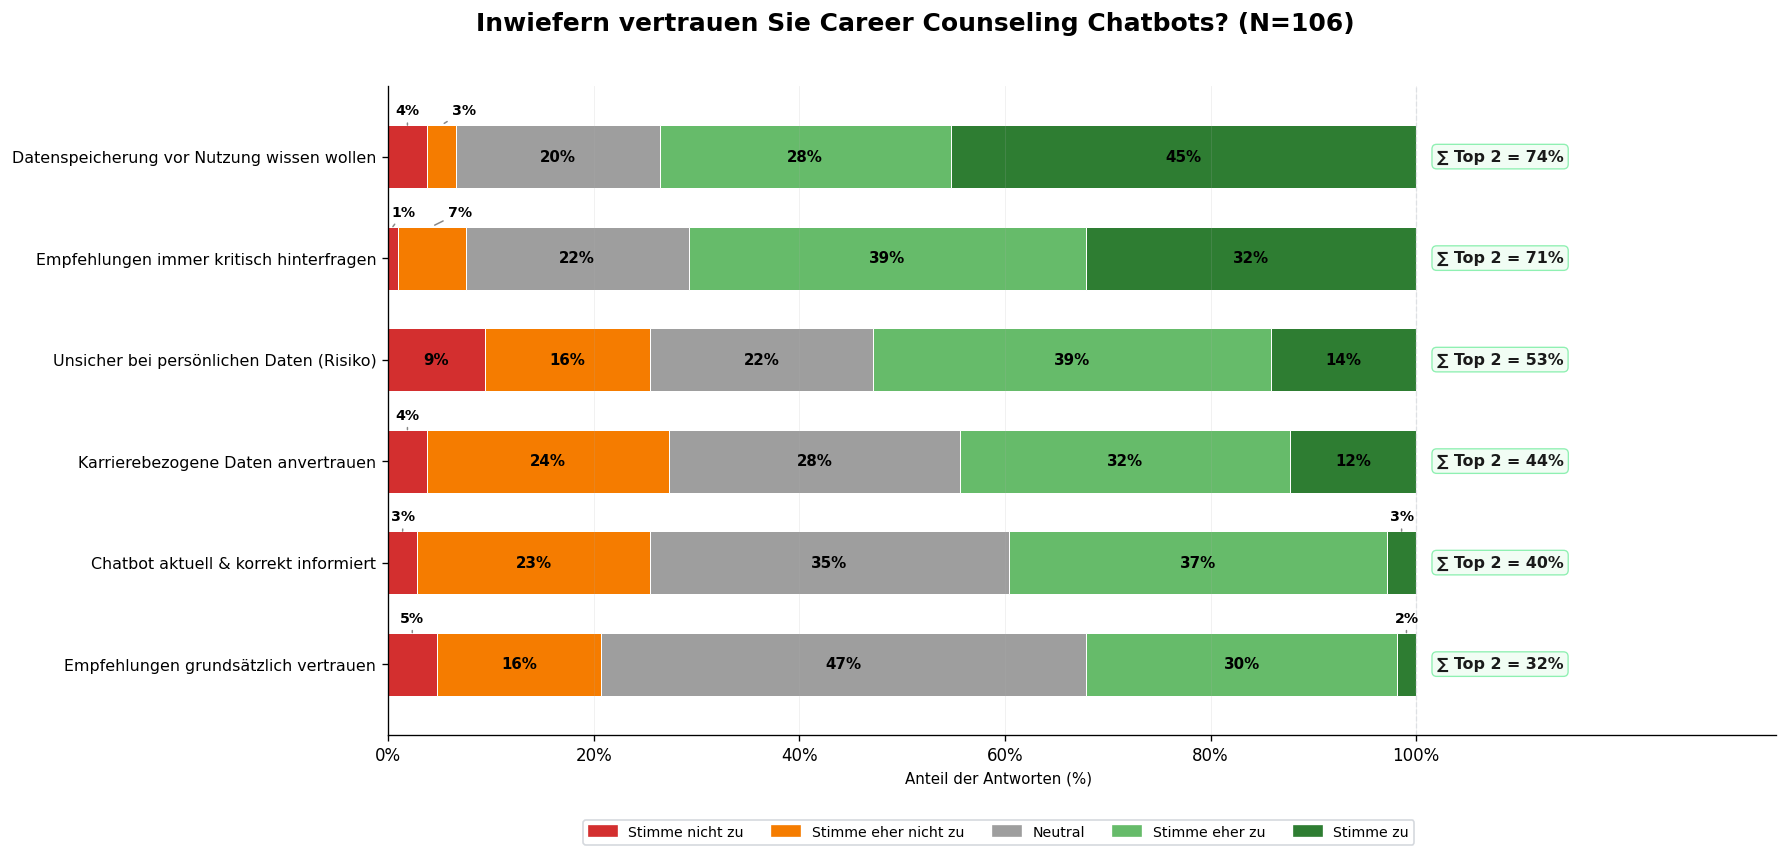

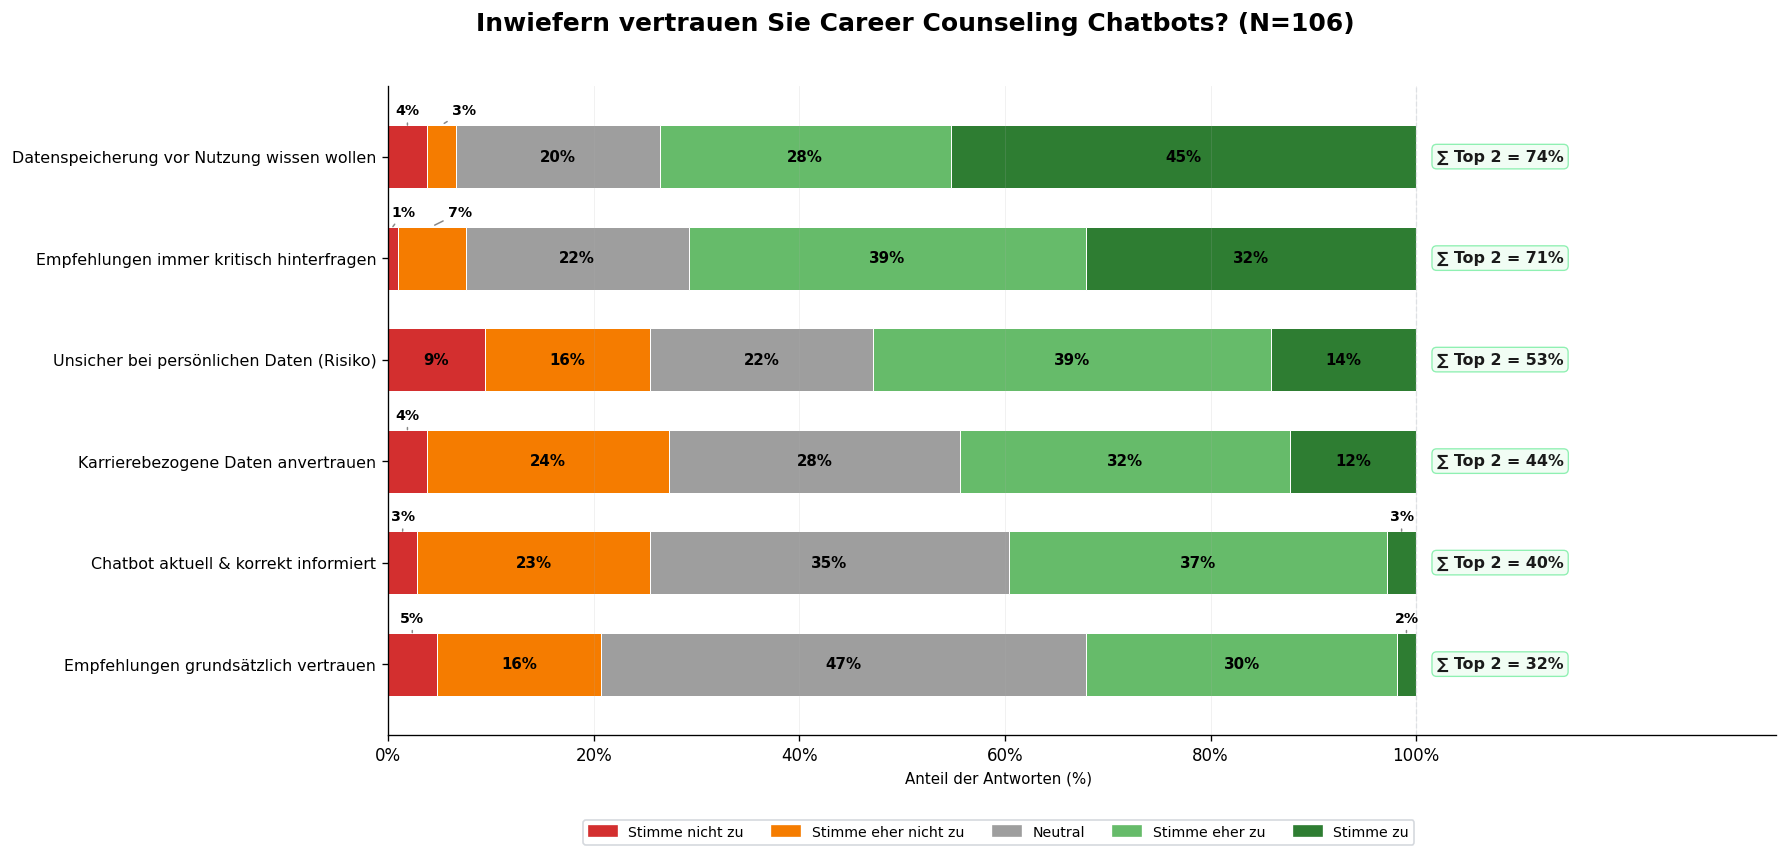

In [29]:
compact_likert_chart(df_valid, f3_items,
    title=f'Inwiefern vertrauen Sie Career Counseling Chatbots? (N={N})')


In [30]:
u, p, r = mwu_test(weiblich['skala_f3'], maennlich['skala_f3'])
print(f"F3 – Vertrauen: U={u:.0f}, p={p:.3f} {sig_stars(p)}, r={r:.3f} ({interpret_r(r)})")
print(f"  Weiblich:  M={weiblich['skala_f3'].mean():.2f}, Mdn={weiblich['skala_f3'].median():.1f}, SD={weiblich['skala_f3'].std():.2f}")
print(f"  Männlich:  M={maennlich['skala_f3'].mean():.2f}, Mdn={maennlich['skala_f3'].median():.1f}, SD={maennlich['skala_f3'].std():.2f}")


F3 – Vertrauen: U=1270, p=0.684 n.s., r=0.039 (sehr klein)
  Weiblich:  M=3.47, Mdn=3.3, SD=0.43
  Männlich:  M=3.48, Mdn=3.5, SD=0.48


### F4 – Wahrgenommene Risiken

In [31]:
f4_items = {
    'f4_ungenaue_empf_n':          'Ungenaue Empfehlungen',
    'f4_voreingenommen_n':         'Chatbot könnte voreingenommen sein',
    'f4_ueberforderung_n':         'Überfordert bei ungewöhnl. Lebensläufen',
    'f4_emotionen_nicht_ernst_n':  'Emotionen werden nicht ernst genommen',
    'f4_ungutes_gefuehl_n':        'Ungutes Gefühl bei der Nutzung',
    'f4_menschen_mehr_vertrauen_n':'Menschen mehr vertrauen als Chatbots',
}
item_comparison_table(df_valid, f4_items,
    title=f'F4 – Risiken: Item-Vergleich (N={N})')



F4 – Risiken: Item-Vergleich (N=106)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Ungenaue Empfehlungen,106,3.84,4.0,0.87,69
1,Menschen mehr vertrauen als Chatbots,106,3.78,4.0,1.05,58
2,Überfordert bei ungewöhnl. Lebensläufen,106,3.54,4.0,0.99,53
3,Emotionen werden nicht ernst genommen,106,3.42,3.5,1.15,50
4,Chatbot könnte voreingenommen sein,106,3.35,3.0,1.01,43
5,Ungutes Gefühl bei der Nutzung,106,2.71,3.0,1.03,18


  ► Höchster Top-2-Wert:   Ungenaue Empfehlungen (69%)
  ► Tiefster  Top-2-Wert:  Ungutes Gefühl bei der Nutzung (18%)
  ► Höchster Mittelwert:   Ungenaue Empfehlungen (M=3.84)
  ► Höchste SD (Streuung): Emotionen werden nicht ernst genommen (SD=1.15)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Ungenaue Empfehlungen,106,3.84,4.0,0.87,69
1,Menschen mehr vertrauen als Chatbots,106,3.78,4.0,1.05,58
2,Überfordert bei ungewöhnl. Lebensläufen,106,3.54,4.0,0.99,53
3,Emotionen werden nicht ernst genommen,106,3.42,3.5,1.15,50
4,Chatbot könnte voreingenommen sein,106,3.35,3.0,1.01,43
5,Ungutes Gefühl bei der Nutzung,106,2.71,3.0,1.03,18


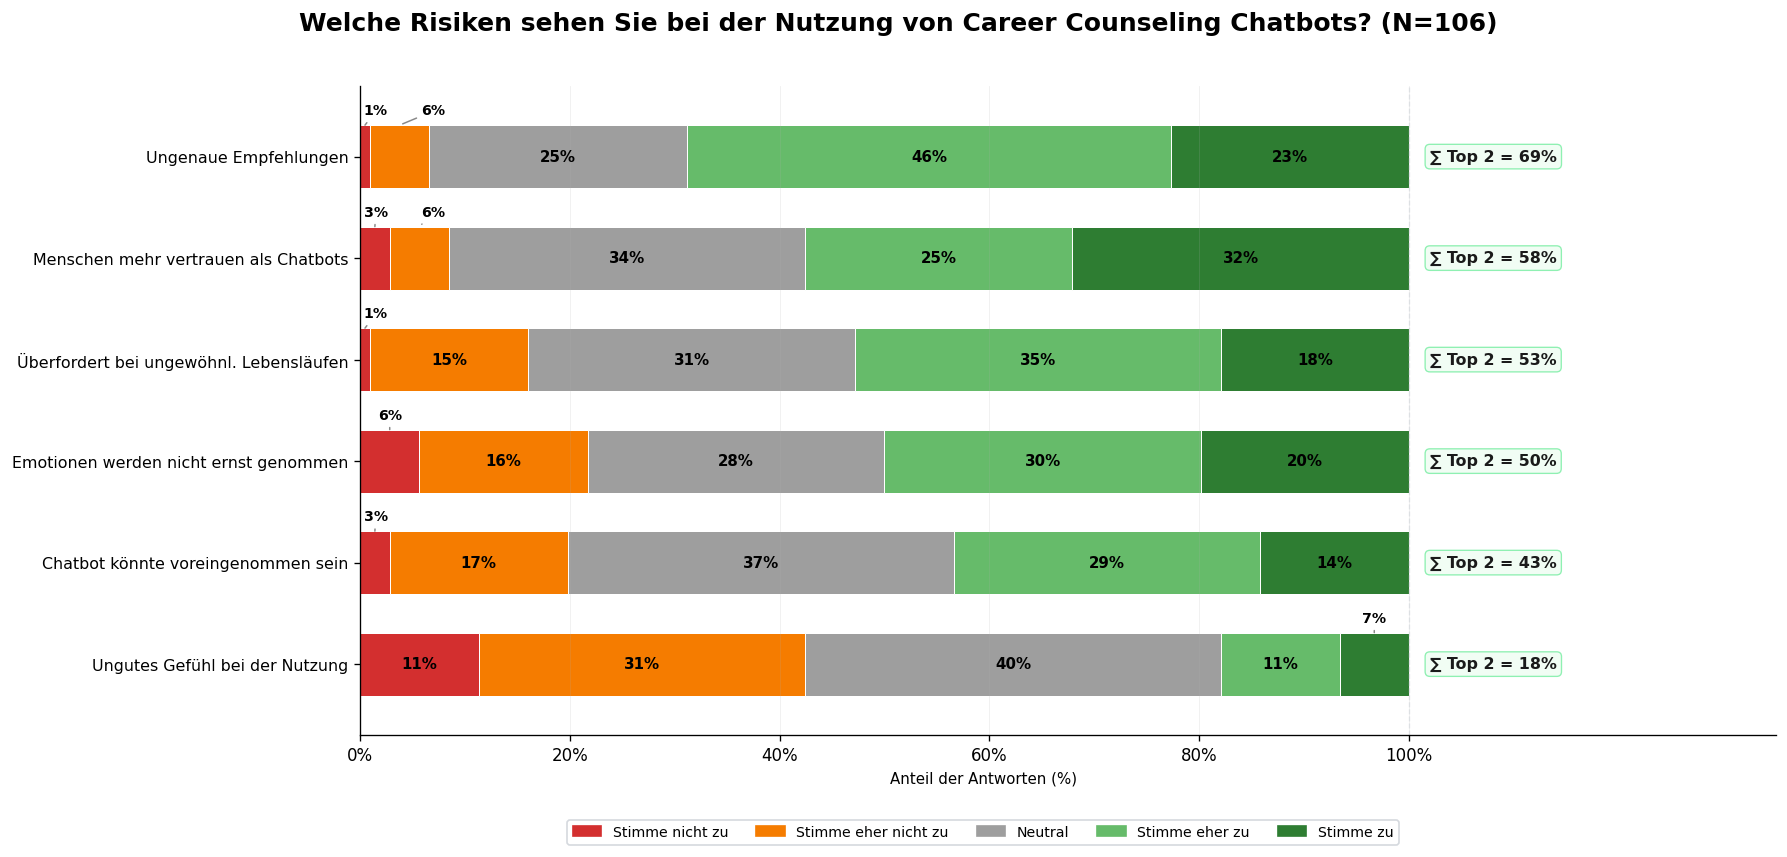

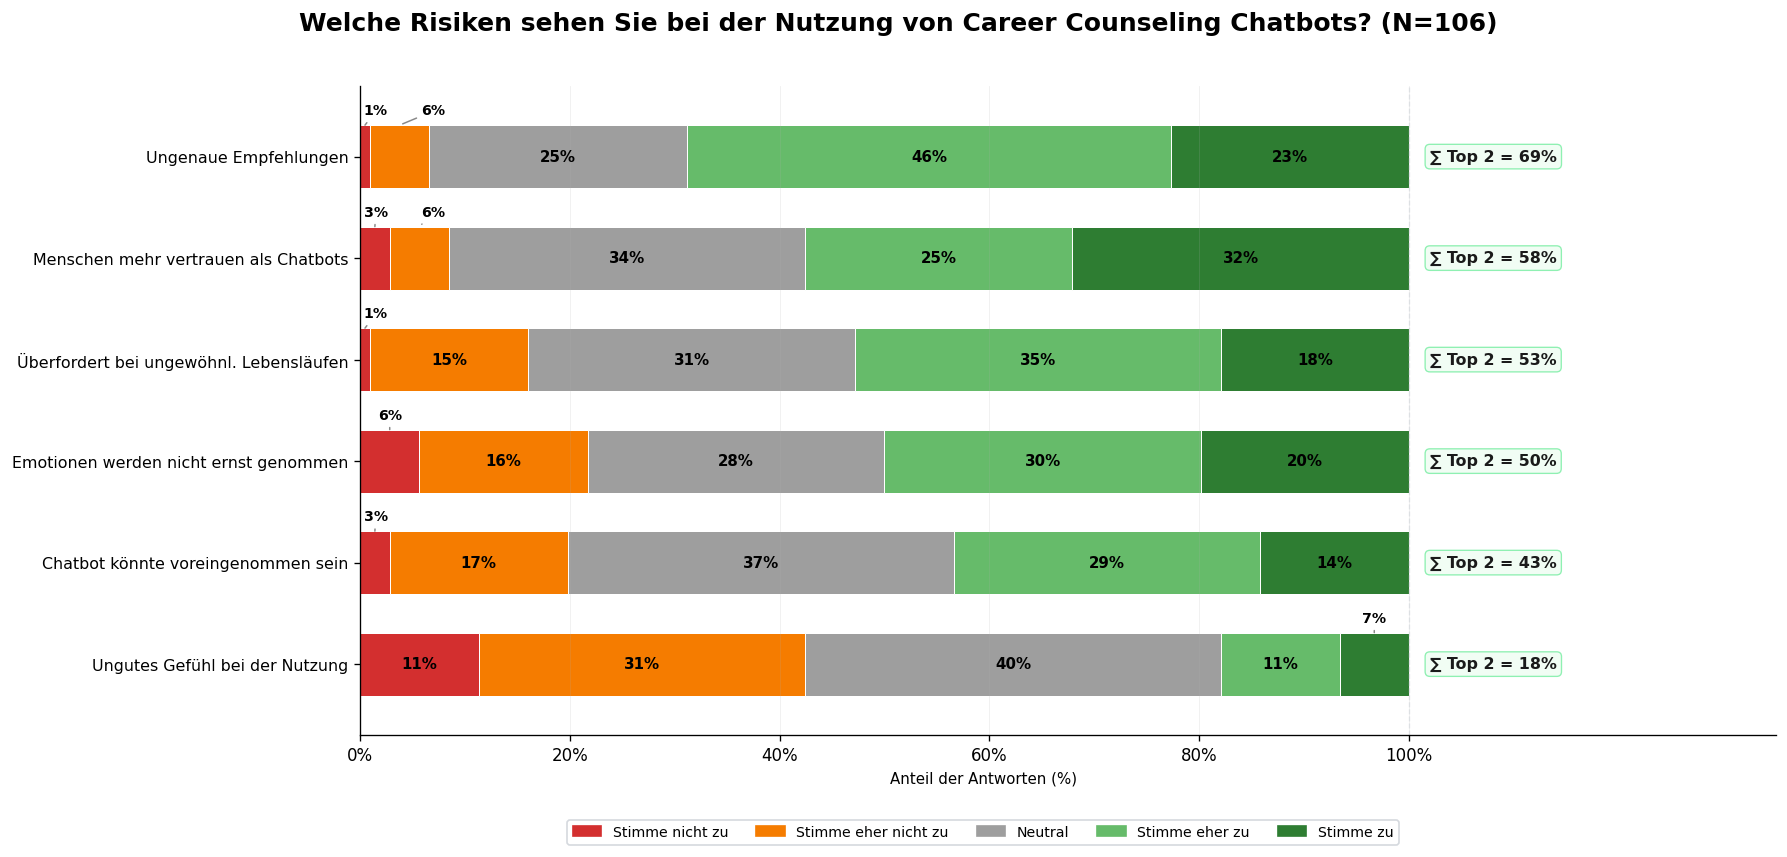

In [32]:
compact_likert_chart(df_valid, f4_items,
    title=f'Welche Risiken sehen Sie bei der Nutzung von Career Counseling Chatbots? (N={N})')


In [33]:
u, p, r = mwu_test(weiblich['skala_f4'], maennlich['skala_f4'])
print(f"F4 – Risiken: U={u:.0f}, p={p:.3f} {sig_stars(p)}, r={r:.3f} ({interpret_r(r)})")
print(f"  Weiblich:  M={weiblich['skala_f4'].mean():.2f}, Mdn={weiblich['skala_f4'].median():.1f}, SD={weiblich['skala_f4'].std():.2f}")
print(f"  Männlich:  M={maennlich['skala_f4'].mean():.2f}, Mdn={maennlich['skala_f4'].median():.1f}, SD={maennlich['skala_f4'].std():.2f}")


F4 – Risiken: U=1456, p=0.421 n.s., r=0.078 (sehr klein)
  Weiblich:  M=3.49, Mdn=3.3, SD=0.58
  Männlich:  M=3.37, Mdn=3.2, SD=0.75


### F5 – Nutzungsabsicht (künftig)

In [34]:
f5_items = {
    'f5_absicht_nutzen_n':       'Beabsichtige, Chatbots künftig zu nutzen',
    'f5_mehrmals_woche_n':       'Mehrmals pro Woche nutzbar vorstellbar',
    'f5_empfehlen_n':            'Würde Chatbots empfehlen',
    'f5_schnell_unkompliziert_n':'Bevorzuge für schnelle Unterstützung',
    'f5_alternative_beratung_n': 'Als Alternative zur Beratung in Betracht',
    'f5_gut_unterstuetzt_n':     'Gut unterstützt durch Chatbot fühlen',
}
item_comparison_table(df_valid, f5_items,
    title=f'F5 – Nutzungsabsicht: Item-Vergleich (N={N})')



F5 – Nutzungsabsicht: Item-Vergleich (N=106)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Bevorzuge für schnelle Unterstützung,106,3.80,4.0,0.95,72
1,"Beabsichtige, Chatbots künftig zu nutzen",106,3.29,3.0,0.97,46
2,Mehrmals pro Woche nutzbar vorstellbar,106,3.21,3.0,1.17,44
3,Gut unterstützt durch Chatbot fühlen,106,3.20,3.0,0.98,42
4,Als Alternative zur Beratung in Betracht,106,3.06,3.0,1.17,40
5,Würde Chatbots empfehlen,106,3.20,3.0,0.92,37


  ► Höchster Top-2-Wert:   Bevorzuge für schnelle Unterstützung (72%)
  ► Tiefster  Top-2-Wert:  Würde Chatbots empfehlen (37%)
  ► Höchster Mittelwert:   Bevorzuge für schnelle Unterstützung (M=3.80)
  ► Höchste SD (Streuung): Mehrmals pro Woche nutzbar vorstellbar (SD=1.17)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Bevorzuge für schnelle Unterstützung,106,3.80,4.0,0.95,72
1,"Beabsichtige, Chatbots künftig zu nutzen",106,3.29,3.0,0.97,46
2,Mehrmals pro Woche nutzbar vorstellbar,106,3.21,3.0,1.17,44
3,Gut unterstützt durch Chatbot fühlen,106,3.20,3.0,0.98,42
4,Als Alternative zur Beratung in Betracht,106,3.06,3.0,1.17,40
5,Würde Chatbots empfehlen,106,3.20,3.0,0.92,37


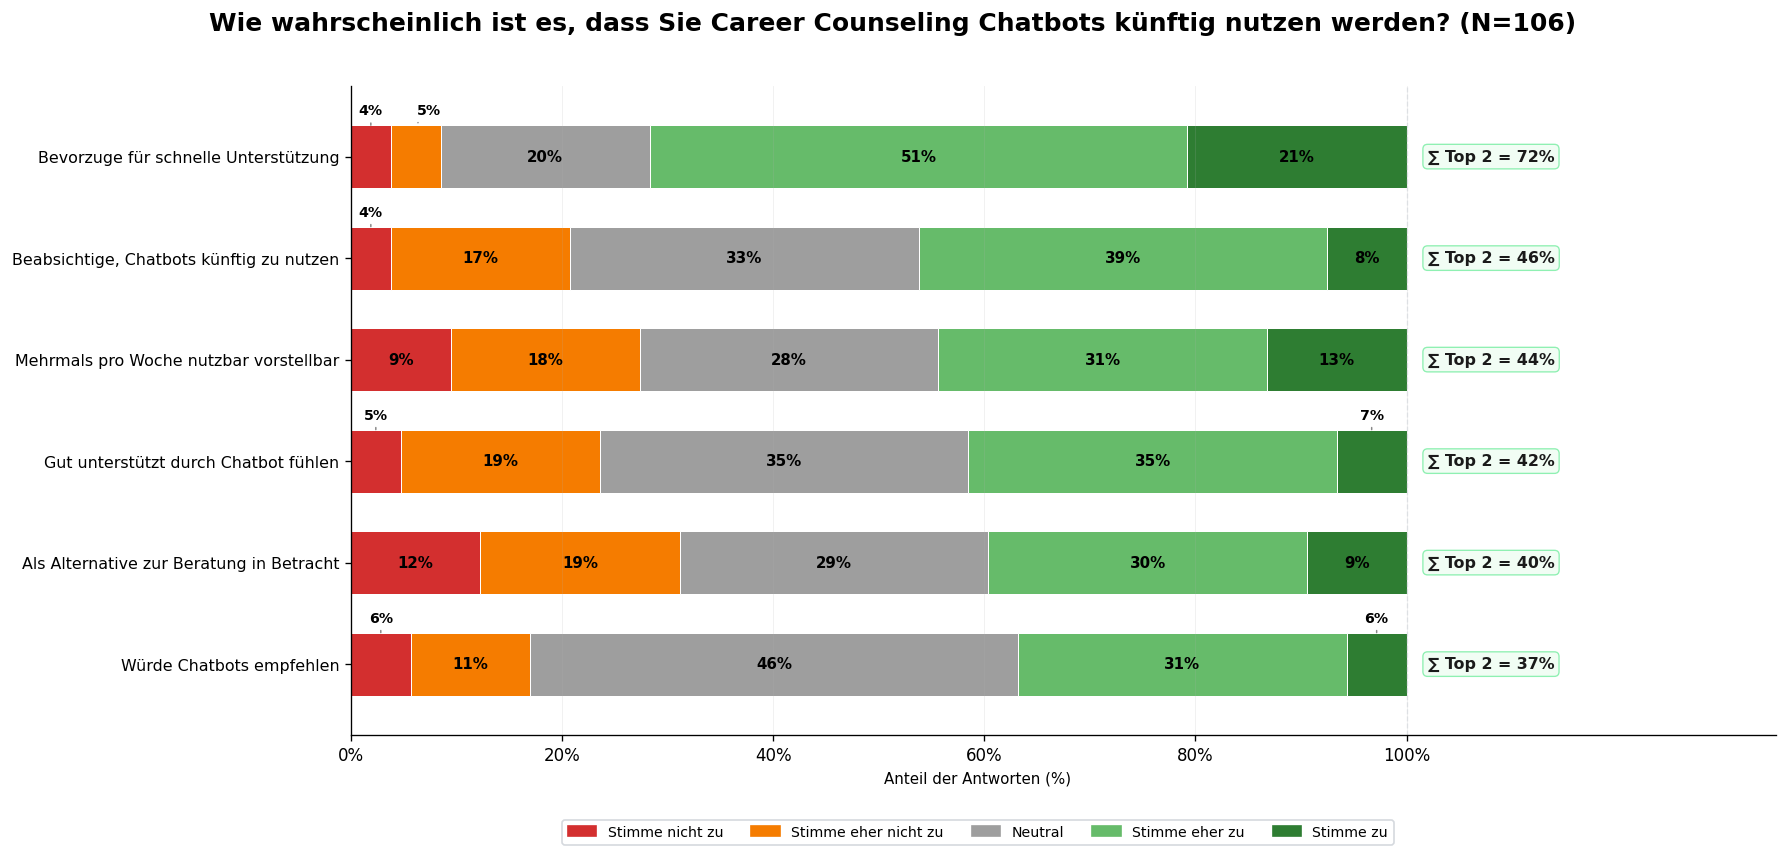

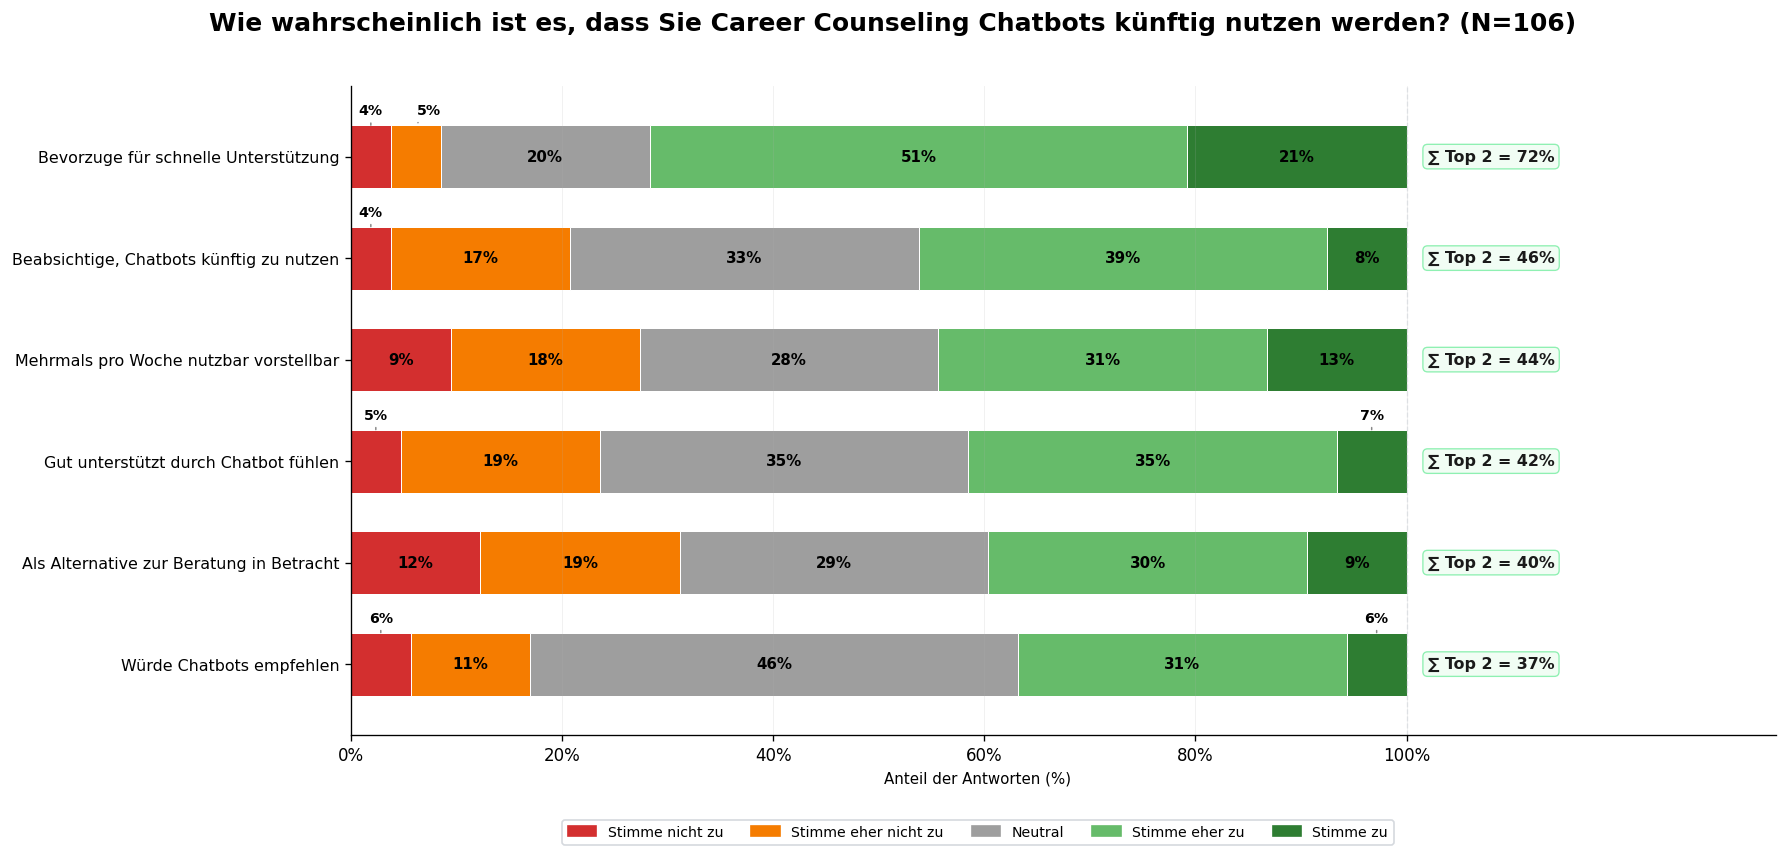

In [35]:
compact_likert_chart(df_valid, f5_items,
    title=f'Wie wahrscheinlich ist es, dass Sie Career Counseling Chatbots künftig nutzen werden? (N={N})')


In [36]:
u, p, r = mwu_test(weiblich['skala_f5'], maennlich['skala_f5'])
print(f"F5 – Nutzungsabsicht: U={u:.0f}, p={p:.3f} {sig_stars(p)}, r={r:.3f} ({interpret_r(r)})")
print(f"  Weiblich:  M={weiblich['skala_f5'].mean():.2f}, Mdn={weiblich['skala_f5'].median():.1f}, SD={weiblich['skala_f5'].std():.2f}")
print(f"  Männlich:  M={maennlich['skala_f5'].mean():.2f}, Mdn={maennlich['skala_f5'].median():.1f}, SD={maennlich['skala_f5'].std():.2f}")


F5 – Nutzungsabsicht: U=1132, p=0.194 n.s., r=0.126 (klein)
  Weiblich:  M=3.26, Mdn=3.2, SD=0.71
  Männlich:  M=3.34, Mdn=3.5, SD=0.92


### F6 – Vergleich mit menschlicher Beratung: Vertrauen & Akzeptanz

In [37]:
f6_items = {
    'f6_personalisierung_n':         'Besser personalisieren als standardisiertes Angebot',
    'f6_neutraler_n':                'Neutraler & vorurteilsfreier als Mensch',
    'f6_schneller_n':                'Schneller auf Fragen reagieren',
    'f6_kein_allein_entscheid_n':    'Keine Karriereentsch. allein auf Chatbot-Basis',
    'f6_mensch_versteht_besser_n':   'Menschlicher Berater versteht Situation besser',
    'f6_emotion_nicht_ersetzen_n':   'Emotionale Unterstützung nicht ersetzbar',
}
item_comparison_table(df_valid, f6_items,
    title=f'F6 – Vergleich menschl. Beratung (Vertrauen): Item-Vergleich (N={N})')



F6 – Vergleich menschl. Beratung (Vertrauen): Item-Vergleich (N=106)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Keine Karriereentsch. allein auf Chatbot-Basis,106,4.22,4.0,0.95,81
1,Emotionale Unterstützung nicht ersetzbar,106,4.16,4.0,1.00,78
2,Schneller auf Fragen reagieren,106,3.93,4.0,0.86,75
3,Menschlicher Berater versteht Situation besser,106,3.75,4.0,1.08,59
4,Neutraler & vorurteilsfreier als Mensch,106,3.47,4.0,1.06,53
5,Besser personalisieren als standardisiertes An...,106,3.10,3.0,1.02,36


  ► Höchster Top-2-Wert:   Keine Karriereentsch. allein auf Chatbot-Basis (81%)
  ► Tiefster  Top-2-Wert:  Besser personalisieren als standardisiertes Angebot (36%)
  ► Höchster Mittelwert:   Keine Karriereentsch. allein auf Chatbot-Basis (M=4.22)
  ► Höchste SD (Streuung): Menschlicher Berater versteht Situation besser (SD=1.08)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Keine Karriereentsch. allein auf Chatbot-Basis,106,4.22,4.0,0.95,81
1,Emotionale Unterstützung nicht ersetzbar,106,4.16,4.0,1.00,78
2,Schneller auf Fragen reagieren,106,3.93,4.0,0.86,75
3,Menschlicher Berater versteht Situation besser,106,3.75,4.0,1.08,59
4,Neutraler & vorurteilsfreier als Mensch,106,3.47,4.0,1.06,53
5,Besser personalisieren als standardisiertes An...,106,3.10,3.0,1.02,36


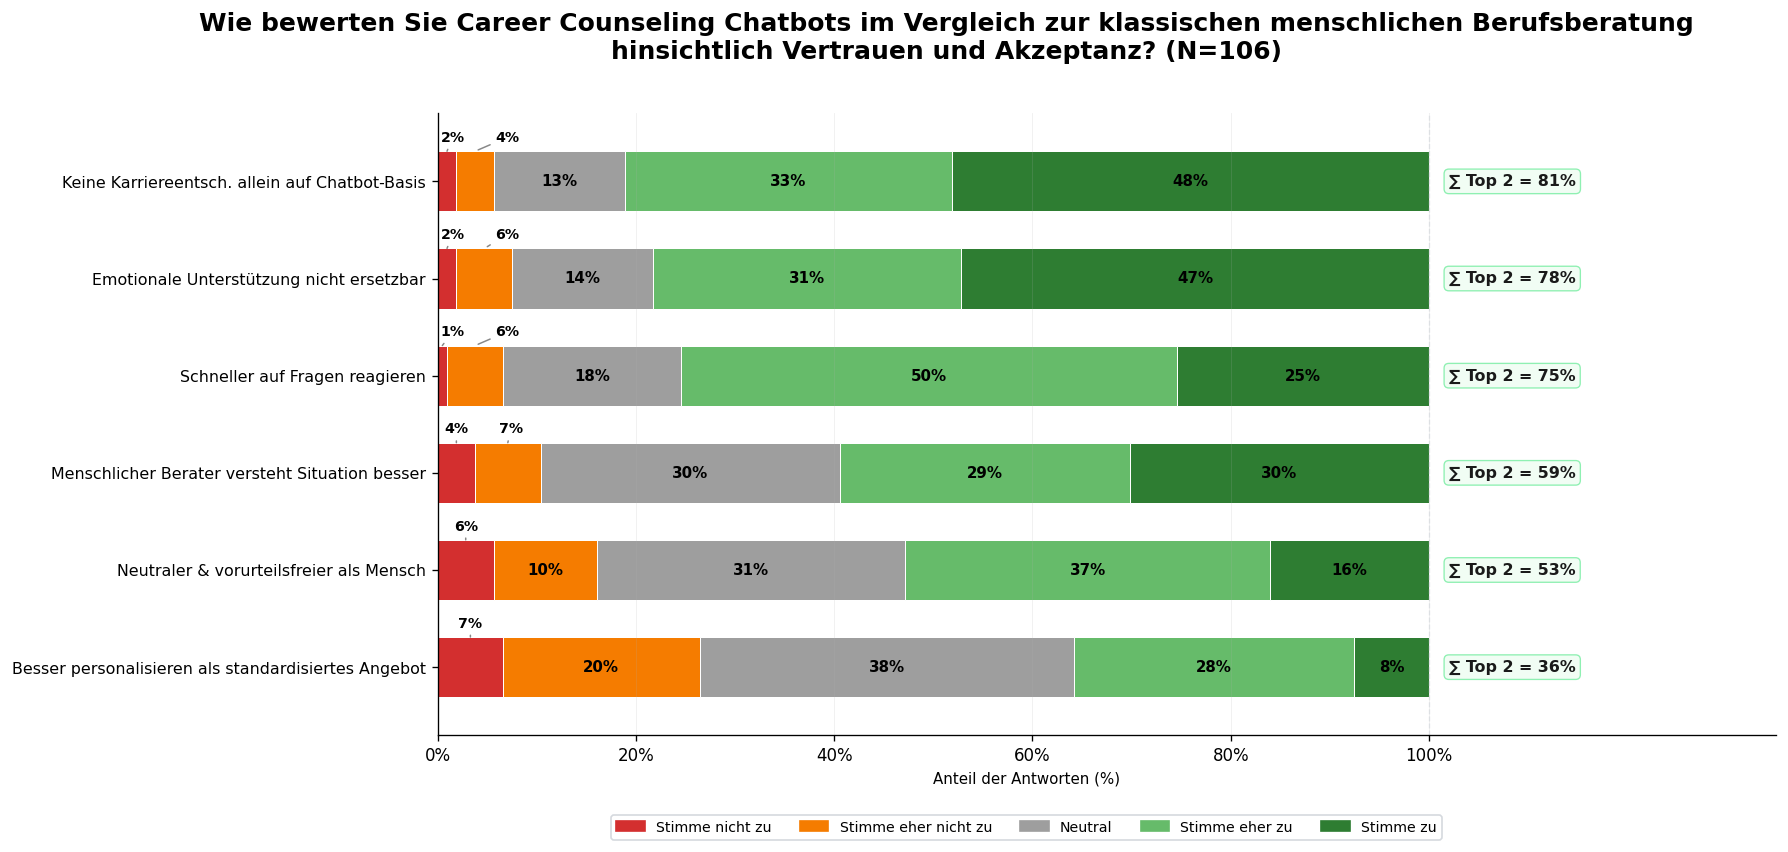

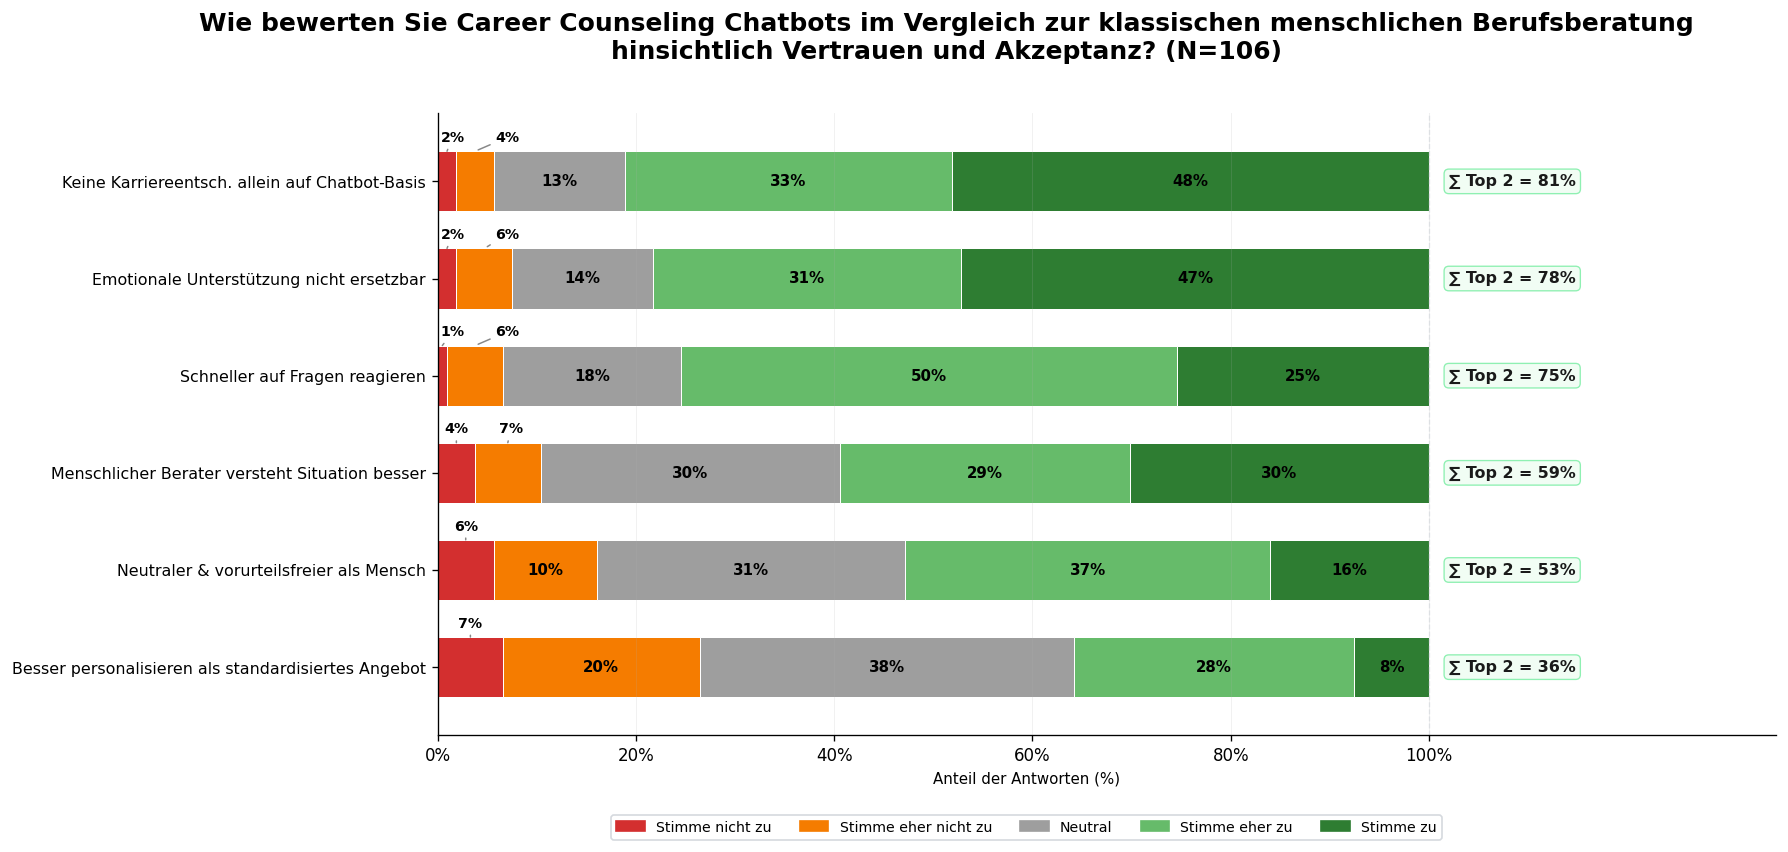

In [38]:
compact_likert_chart(df_valid, f6_items,
    title=f'Wie bewerten Sie Career Counseling Chatbots im Vergleich zur klassischen menschlichen Berufsberatung\nhinsichtlich Vertrauen und Akzeptanz? (N={N})')


In [39]:
u, p, r = mwu_test(weiblich['skala_f6'], maennlich['skala_f6'])
print(f"F6 – Vergleich Vertrauen: U={u:.0f}, p={p:.3f} {sig_stars(p)}, r={r:.3f} ({interpret_r(r)})")


F6 – Vergleich Vertrauen: U=1206, p=0.410 n.s., r=0.080 (sehr klein)


### F7 – Einsatzbereiche im Bewerbungsprozess

In [40]:
f7_items = {
    'f7_lebenslauf_n':       'Lebenslauf optimieren',
    'f7_bewerbschreiben_n':  'Bewerbungsschreiben verbessern',
    'f7_interview_n':        'Interviewfragen üben',
    'f7_gehaltsinfos_n':     'Gehalts- & Arbeitsmarktinfos',
    'f7_unternehmen_infos_n':'Über Unternehmen informieren',
    'f7_allg_fragen_n':      'Allgemeine Jobsuche-Fragen klären',
}
item_comparison_table(df_valid, f7_items,
    title=f'F7 – Einsatzbereiche: Item-Vergleich (N={N})')



F7 – Einsatzbereiche: Item-Vergleich (N=106)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Bewerbungsschreiben verbessern,106,4.35,5.0,0.84,89
1,Lebenslauf optimieren,106,4.17,4.0,0.97,81
2,Interviewfragen üben,106,4.08,4.0,1.02,79
3,Über Unternehmen informieren,106,3.92,4.0,1.07,72
4,Allgemeine Jobsuche-Fragen klären,106,4.08,4.0,0.90,72
5,Gehalts- & Arbeitsmarktinfos,106,3.85,4.0,1.01,66


  ► Höchster Top-2-Wert:   Bewerbungsschreiben verbessern (89%)
  ► Tiefster  Top-2-Wert:  Gehalts- & Arbeitsmarktinfos (66%)
  ► Höchster Mittelwert:   Bewerbungsschreiben verbessern (M=4.35)
  ► Höchste SD (Streuung): Über Unternehmen informieren (SD=1.07)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Bewerbungsschreiben verbessern,106,4.35,5.0,0.84,89
1,Lebenslauf optimieren,106,4.17,4.0,0.97,81
2,Interviewfragen üben,106,4.08,4.0,1.02,79
3,Über Unternehmen informieren,106,3.92,4.0,1.07,72
4,Allgemeine Jobsuche-Fragen klären,106,4.08,4.0,0.90,72
5,Gehalts- & Arbeitsmarktinfos,106,3.85,4.0,1.01,66


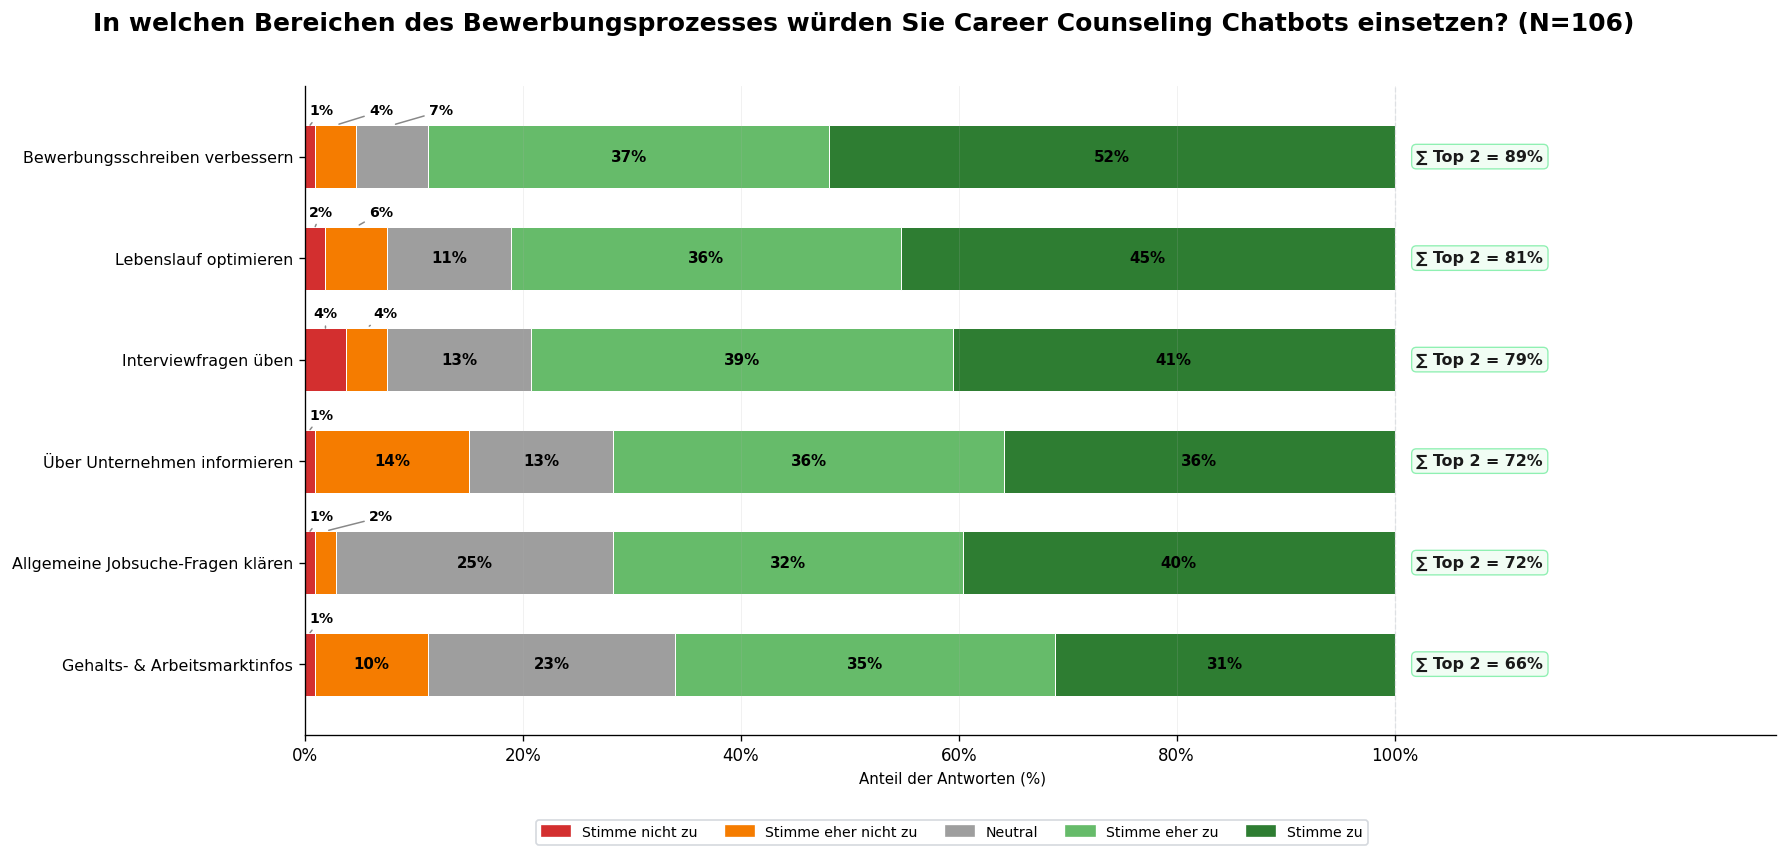

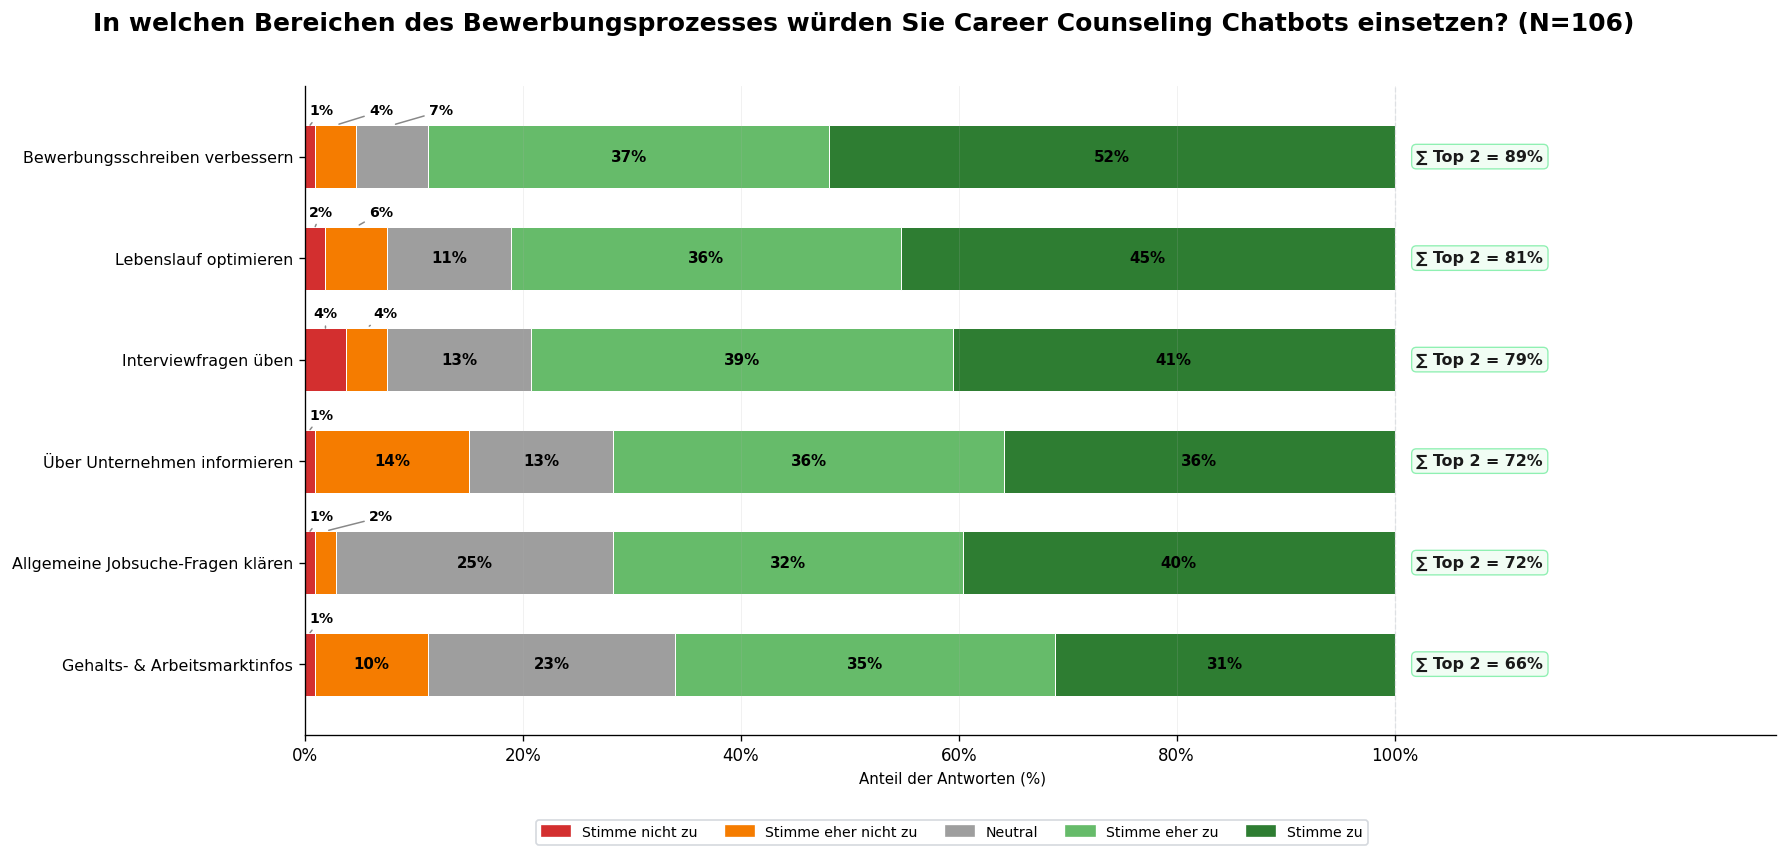

In [41]:
compact_likert_chart(df_valid, f7_items,
    title=f'In welchen Bereichen des Bewerbungsprozesses würden Sie Career Counseling Chatbots einsetzen? (N={N})')


In [42]:
u, p, r = mwu_test(weiblich['skala_f7'], maennlich['skala_f7'])
print(f"F7 – Einsatzbereiche: U={u:.0f}, p={p:.3f} {sig_stars(p)}, r={r:.3f} ({interpret_r(r)})")


F7 – Einsatzbereiche: U=1430, p=0.524 n.s., r=0.062 (sehr klein)


### F8 – Hindernisse bei der Nutzung

In [43]:
f8_items = {
    'f8_situation_nicht_verstehen_n': 'Chatbot versteht individuelle Situation nicht',
    'f8_empf_nicht_nachvollziehen_n': 'Empfehlungen schwer nachzuvollziehen',
    'f8_kein_mensch_gegenueber_n':    'Fehlendes menschliches Gegenüber hält ab',
    'f8_nicht_wie_einsetzen_n':       'Weiss nicht, wie sinnvoll einzusetzen',
    'f8_nur_einfache_fragen_n':       'Nur für einfache Fragen nutzbar',
    'f8_nur_wenn_empfohlen_n':        'Nur nutzen, wenn empfohlen',
}
item_comparison_table(df_valid, f8_items,
    title=f'F8 – Hindernisse: Item-Vergleich (N={N})')



F8 – Hindernisse: Item-Vergleich (N=106)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Nur für einfache Fragen nutzbar,106,3.51,4.0,1.11,58
1,Fehlendes menschliches Gegenüber hält ab,106,3.08,3.0,1.24,43
2,Chatbot versteht individuelle Situation nicht,106,3.11,3.0,1.03,40
3,"Weiss nicht, wie sinnvoll einzusetzen",106,2.76,3.0,1.08,29
4,"Nur nutzen, wenn empfohlen",106,2.85,3.0,1.11,28
5,Empfehlungen schwer nachzuvollziehen,106,2.61,3.0,0.98,19


  ► Höchster Top-2-Wert:   Nur für einfache Fragen nutzbar (58%)
  ► Tiefster  Top-2-Wert:  Empfehlungen schwer nachzuvollziehen (19%)
  ► Höchster Mittelwert:   Nur für einfache Fragen nutzbar (M=3.51)
  ► Höchste SD (Streuung): Fehlendes menschliches Gegenüber hält ab (SD=1.24)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Nur für einfache Fragen nutzbar,106,3.51,4.0,1.11,58
1,Fehlendes menschliches Gegenüber hält ab,106,3.08,3.0,1.24,43
2,Chatbot versteht individuelle Situation nicht,106,3.11,3.0,1.03,40
3,"Weiss nicht, wie sinnvoll einzusetzen",106,2.76,3.0,1.08,29
4,"Nur nutzen, wenn empfohlen",106,2.85,3.0,1.11,28
5,Empfehlungen schwer nachzuvollziehen,106,2.61,3.0,0.98,19


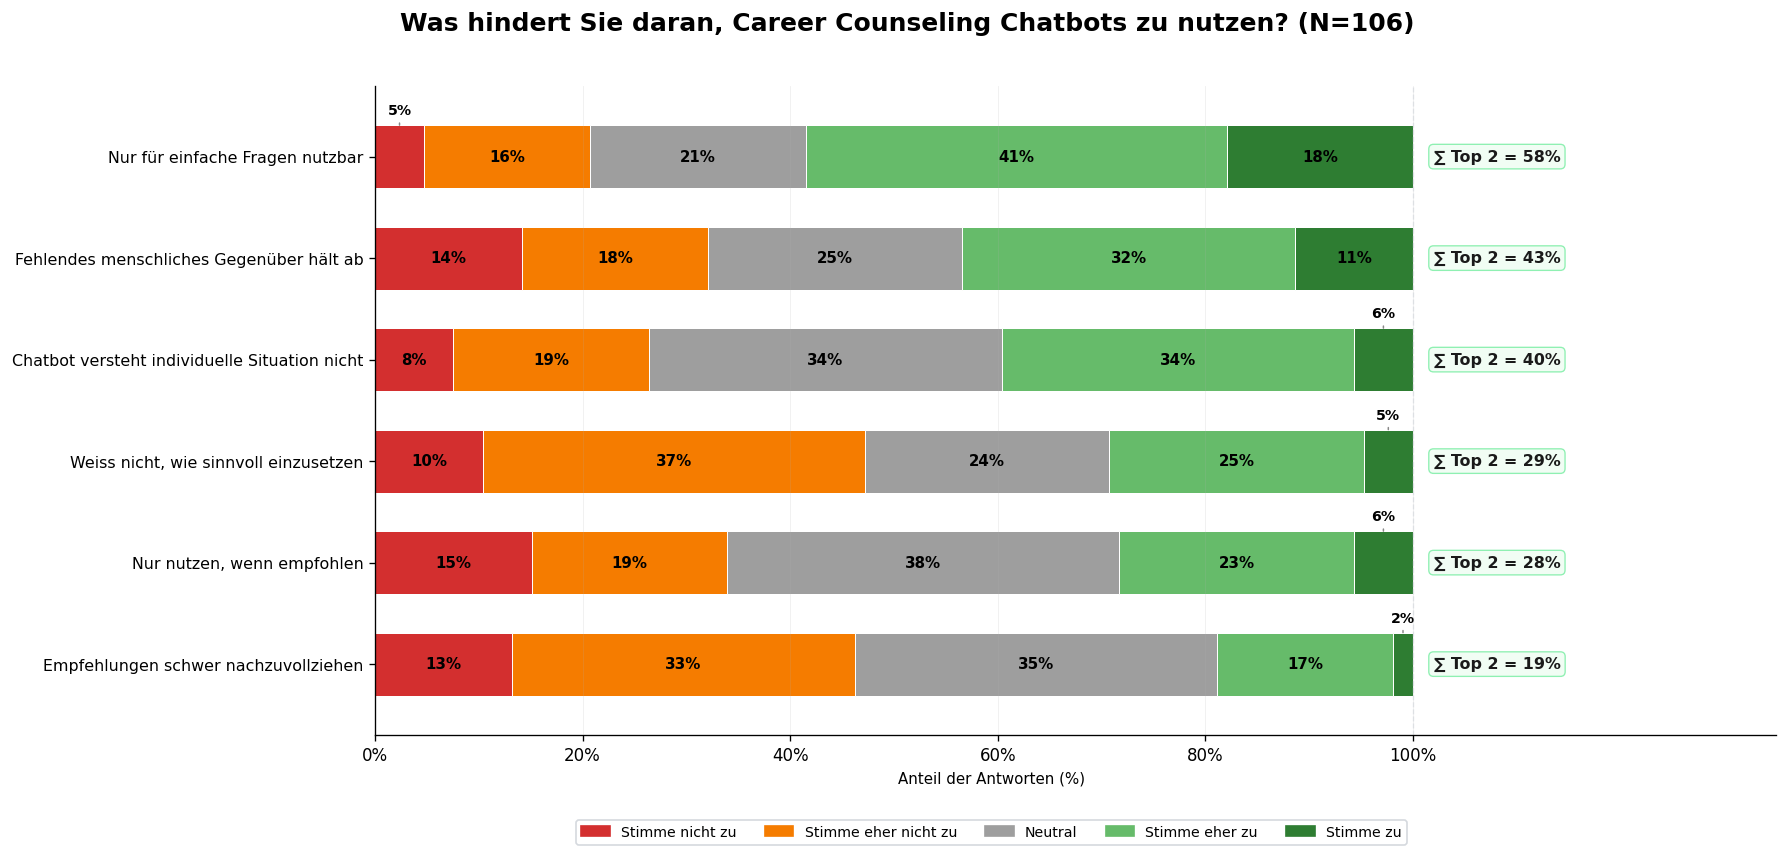

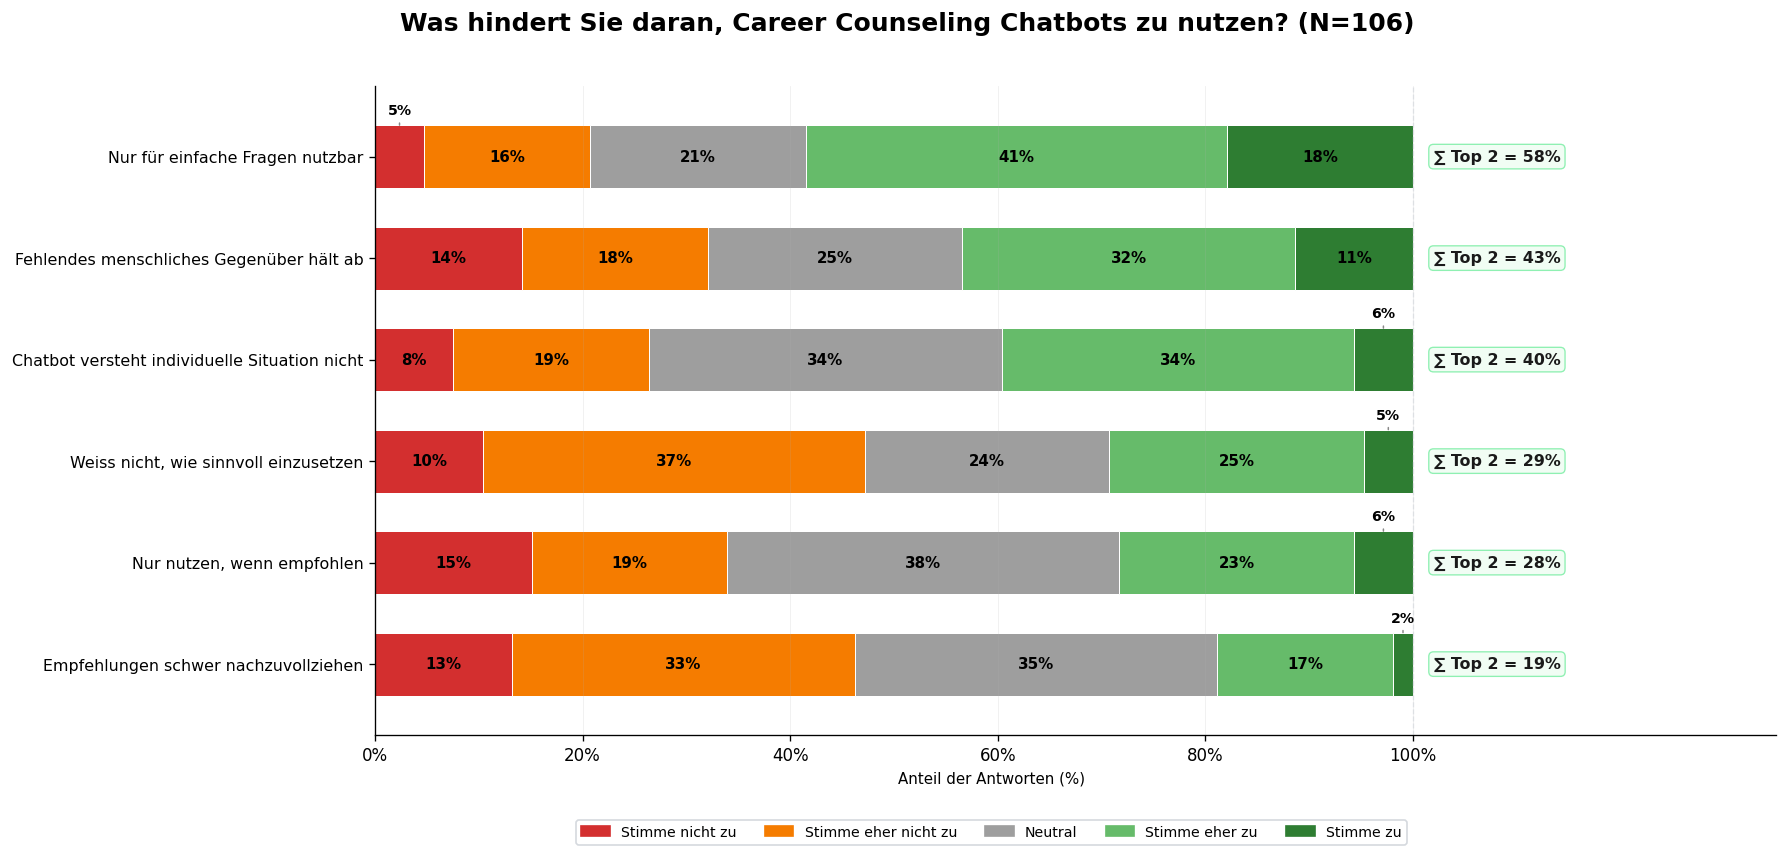

In [44]:
compact_likert_chart(df_valid, f8_items,
    title=f'Was hindert Sie daran, Career Counseling Chatbots zu nutzen? (N={N})')


In [45]:
u, p, r = mwu_test(weiblich['skala_f8'], maennlich['skala_f8'])
print(f"F8 – Hindernisse: U={u:.0f}, p={p:.3f} {sig_stars(p)}, r={r:.3f} ({interpret_r(r)})")


F8 – Hindernisse: U=1414, p=0.595 n.s., r=0.052 (sehr klein)


---
## 6. Teil 2 – Funktionaler Nutzen (F9–F12)

### F9 – Selbstreflexion & Entscheidungsfindung

In [46]:
f9_items = {
    'f9_staerken_erkennen_n':        'Stärken besser erkennen',
    'f9_schwaechen_einschaetzen_n':  'Schwächen besser einschätzen',
    'f9_berufserf_reflektieren_n':   'Berufserfahrungen reflektieren',
    'f9_entscheidung_orientierung_n':'Bei beruflichen Entscheidungen orientieren',
    'f9_unsicherheiten_reduzieren_n':'Unsicherheiten in der Jobsuche reduzieren',
    'f9_jobangebote_vergleichen_n':  'Jobangebote vergleichen',
}
item_comparison_table(df_valid, f9_items,
    title=f'F9 – Selbstreflexion: Item-Vergleich (N={N})')



F9 – Selbstreflexion: Item-Vergleich (N=106)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Jobangebote vergleichen,106,4.01,4.0,0.82,81
1,Bei beruflichen Entscheidungen orientieren,106,3.60,4.0,0.91,62
2,Schwächen besser einschätzen,106,3.42,4.0,1.03,58
3,Berufserfahrungen reflektieren,106,3.53,4.0,0.90,56
4,Stärken besser erkennen,106,3.43,4.0,1.00,55
5,Unsicherheiten in der Jobsuche reduzieren,106,3.26,3.0,1.06,49


  ► Höchster Top-2-Wert:   Jobangebote vergleichen (81%)
  ► Tiefster  Top-2-Wert:  Unsicherheiten in der Jobsuche reduzieren (49%)
  ► Höchster Mittelwert:   Jobangebote vergleichen (M=4.01)
  ► Höchste SD (Streuung): Unsicherheiten in der Jobsuche reduzieren (SD=1.06)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Jobangebote vergleichen,106,4.01,4.0,0.82,81
1,Bei beruflichen Entscheidungen orientieren,106,3.60,4.0,0.91,62
2,Schwächen besser einschätzen,106,3.42,4.0,1.03,58
3,Berufserfahrungen reflektieren,106,3.53,4.0,0.90,56
4,Stärken besser erkennen,106,3.43,4.0,1.00,55
5,Unsicherheiten in der Jobsuche reduzieren,106,3.26,3.0,1.06,49


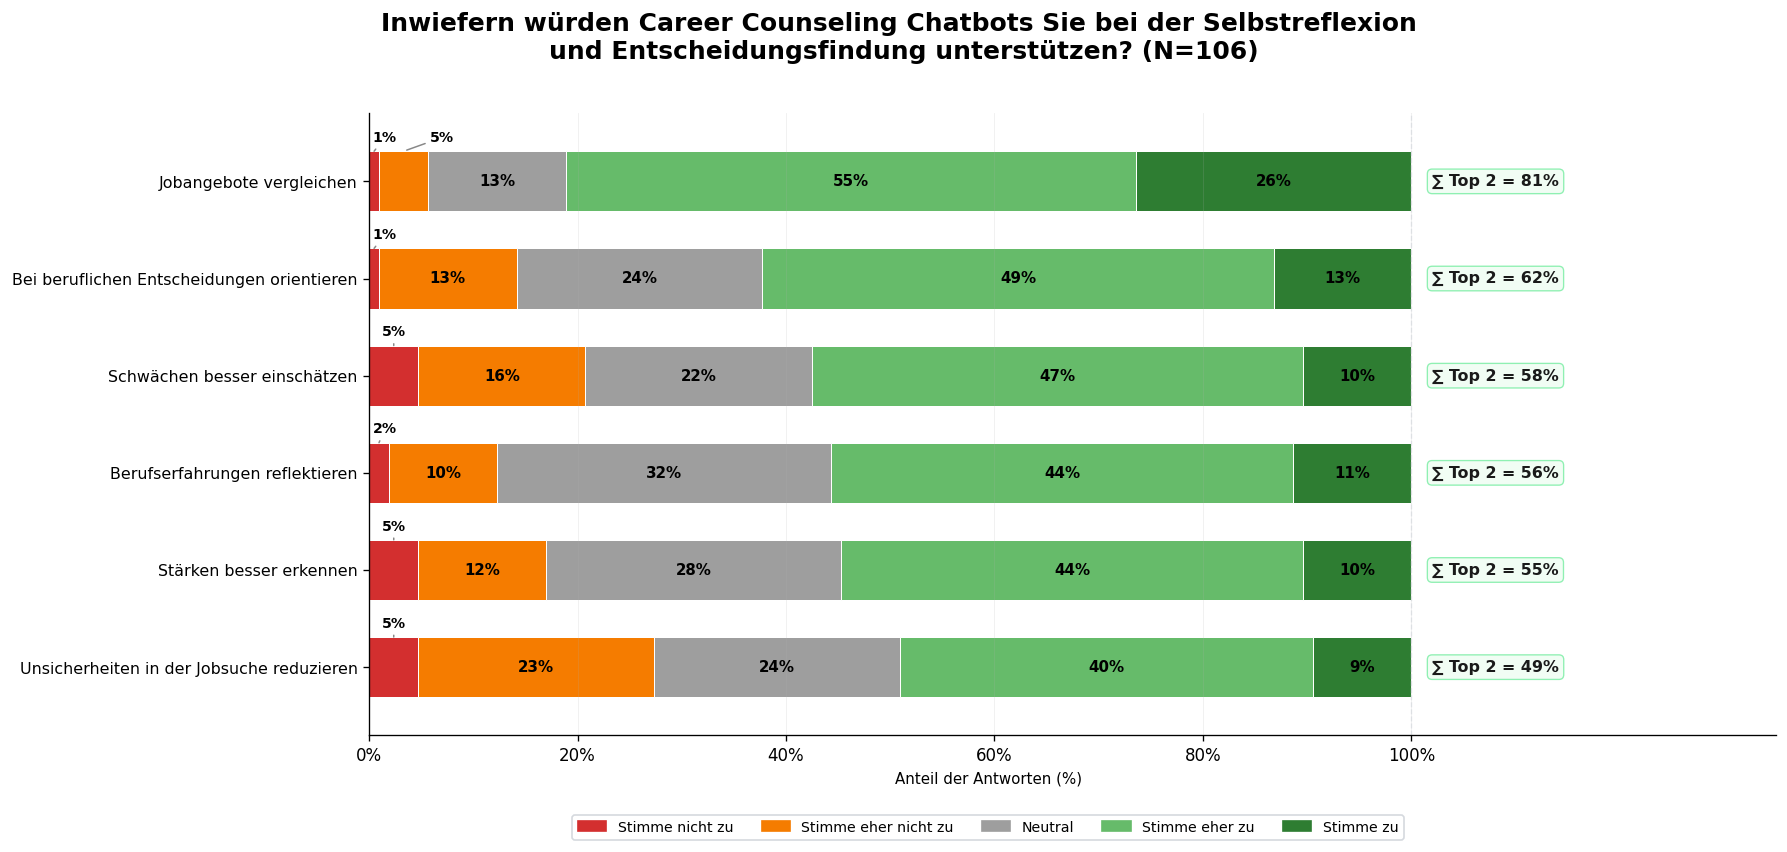

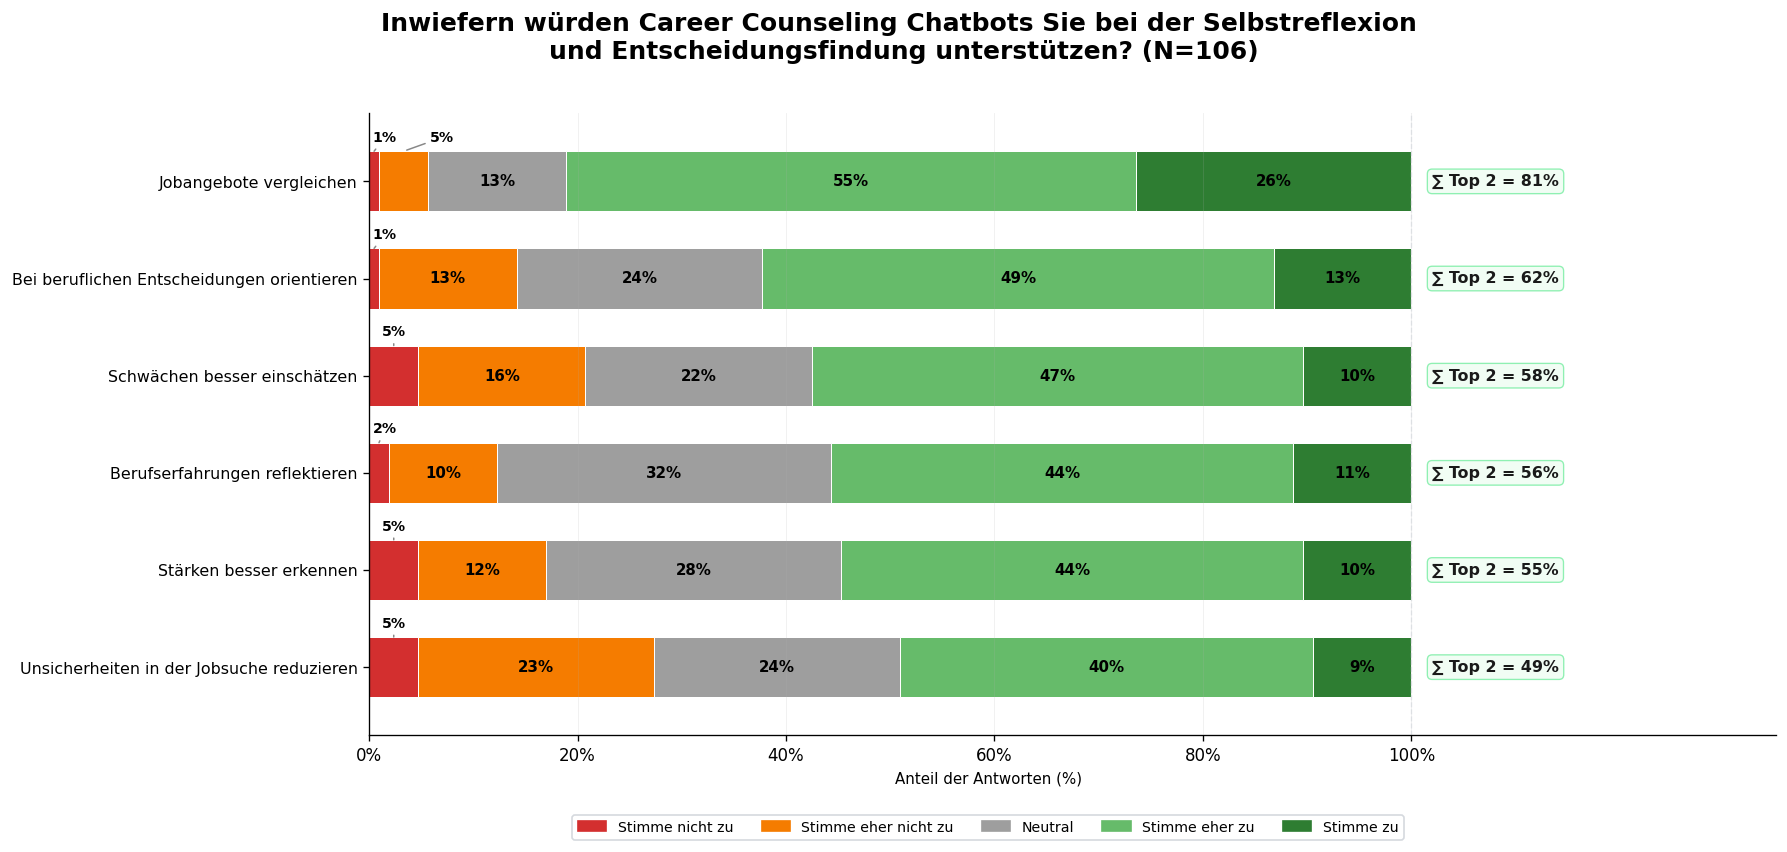

In [47]:
compact_likert_chart(df_valid, f9_items,
    title=f'Inwiefern würden Career Counseling Chatbots Sie bei der Selbstreflexion \nund Entscheidungsfindung unterstützen? (N={N})')


In [48]:
u, p, r = mwu_test(weiblich['skala_f9'], maennlich['skala_f9'])
print(f"F9 – Selbstreflexion: U={u:.0f}, p={p:.3f} {sig_stars(p)}, r={r:.3f} ({interpret_r(r)})")
print(f"  Weiblich:  M={weiblich['skala_f9'].mean():.2f}, Mdn={weiblich['skala_f9'].median():.1f}")
print(f"  Männlich:  M={maennlich['skala_f9'].mean():.2f}, Mdn={maennlich['skala_f9'].median():.1f}")


F9 – Selbstreflexion: U=1376, p=0.782 n.s., r=0.027 (sehr klein)
  Weiblich:  M=3.57, Mdn=3.7
  Männlich:  M=3.51, Mdn=3.7


### F10 – Bewerbungsqualität & Vorbereitung

In [49]:
f10_items = {
    'f10_qualitaet_verbessern_n':               'Bewerbungsunterlagen qualitativ verbessern',
    'f10_gezieltes_feedback_n':                 'Gezieltes Feedback auf Bewerbungen geben',
    'f10_vorbereitung_vorstellungsgespraech_n': 'Vorstellungsgespräch-Vorbereitung unterstützen',
    'f10_besser_vorbereitet_fuehlen_n':         'Besser vorbereitet fühlen',
    'f10_selbstvertrauen_n':                    'Selbstvertrauen im Bewerbungsprozess stärken',
    'f10_erfolgschancen_n':                     'Erfolgschancen erhöhen',
}
item_comparison_table(df_valid, f10_items,
    title=f'F10 – Bewerbungsqualität: Item-Vergleich (N={N})')



F10 – Bewerbungsqualität: Item-Vergleich (N=106)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Gezieltes Feedback auf Bewerbungen geben,106,4.13,4.0,0.77,84
1,Bewerbungsunterlagen qualitativ verbessern,106,4.07,4.0,0.81,79
2,Vorstellungsgespräch-Vorbereitung unterstützen,106,3.98,4.0,0.89,76
3,Besser vorbereitet fühlen,106,3.79,4.0,0.94,66
4,Selbstvertrauen im Bewerbungsprozess stärken,106,3.38,3.0,1.10,49
5,Erfolgschancen erhöhen,106,3.44,3.0,0.96,49


  ► Höchster Top-2-Wert:   Gezieltes Feedback auf Bewerbungen geben (84%)
  ► Tiefster  Top-2-Wert:  Selbstvertrauen im Bewerbungsprozess stärken (49%)
  ► Höchster Mittelwert:   Gezieltes Feedback auf Bewerbungen geben (M=4.13)
  ► Höchste SD (Streuung): Selbstvertrauen im Bewerbungsprozess stärken (SD=1.10)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Gezieltes Feedback auf Bewerbungen geben,106,4.13,4.0,0.77,84
1,Bewerbungsunterlagen qualitativ verbessern,106,4.07,4.0,0.81,79
2,Vorstellungsgespräch-Vorbereitung unterstützen,106,3.98,4.0,0.89,76
3,Besser vorbereitet fühlen,106,3.79,4.0,0.94,66
4,Selbstvertrauen im Bewerbungsprozess stärken,106,3.38,3.0,1.10,49
5,Erfolgschancen erhöhen,106,3.44,3.0,0.96,49


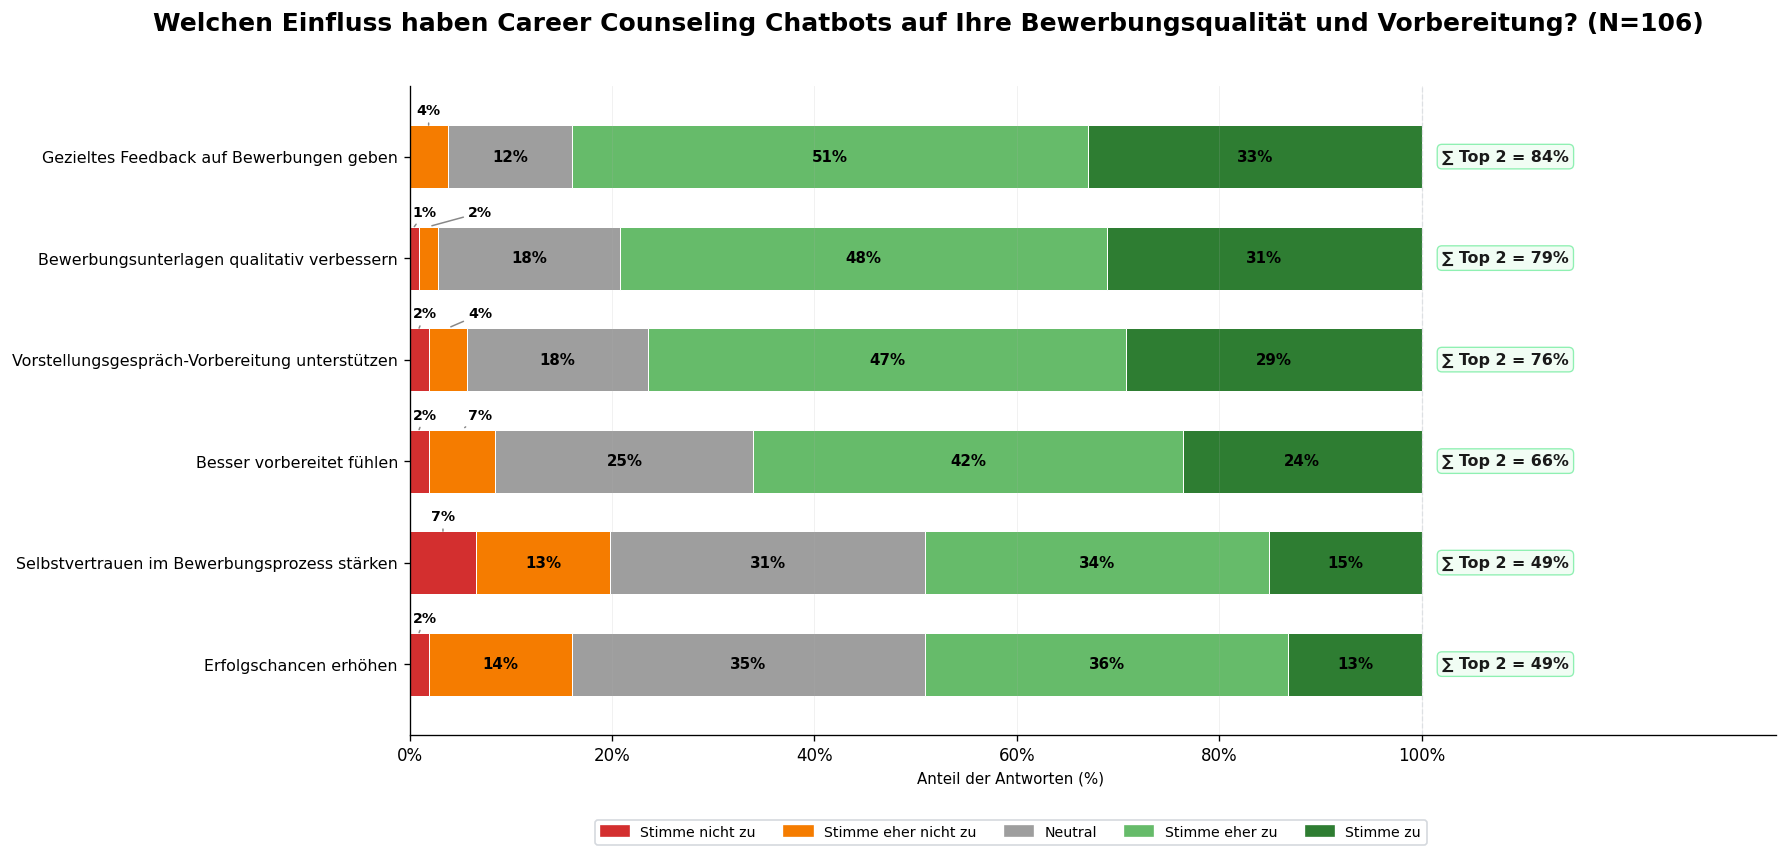

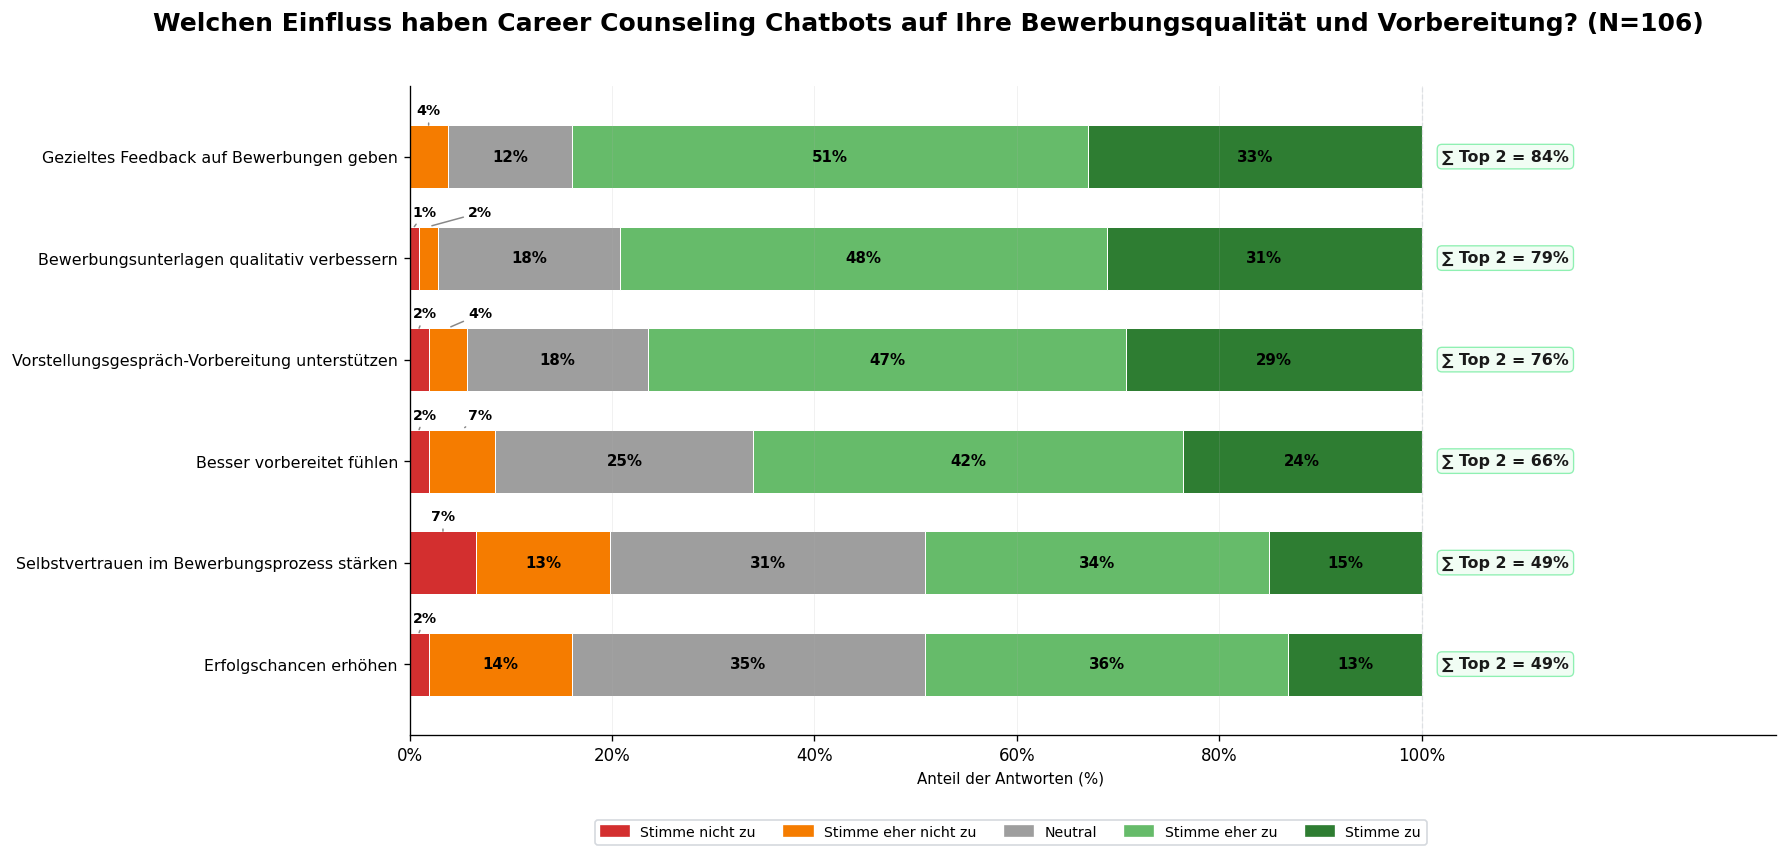

In [50]:
compact_likert_chart(df_valid, f10_items,
    title=f'Welchen Einfluss haben Career Counseling Chatbots auf Ihre Bewerbungsqualität und Vorbereitung? (N={N})')


In [51]:
u, p, r = mwu_test(weiblich['skala_f10'], maennlich['skala_f10'])
print(f"F10 – Bewerbungsqualität: U={u:.0f}, p={p:.3f} {sig_stars(p)}, r={r:.3f} ({interpret_r(r)})")


F10 – Bewerbungsqualität: U=1295, p=0.809 n.s., r=0.024 (sehr klein)


### F11 – Berufliche Orientierung & langfristige Karriereplanung

In [52]:
f11_items = {
    'f11_alternativen_aufzeigen_n':  'Neue berufliche Alternativen aufzeigen',
    'f11_berufsfelder_passen_n':     'Passende Berufsfelder nach Interessen',
    'f11_arbeitsmarkt_ueberblick_n': 'Überblick über den Arbeitsmarkt',
    'f11_karriereziele_definieren_n':'Realistische Karriereziele definieren',
    'f11_langfristig_begleiten_n':   'Langfristige Karriereplanung begleiten',
    'f11_weiterbildung_hinweisen_n': 'Auf Weiterbildungen hinweisen',
}
item_comparison_table(df_valid, f11_items,
    title=f'F11 – Karriereplanung: Item-Vergleich (N={N})')



F11 – Karriereplanung: Item-Vergleich (N=106)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Überblick über den Arbeitsmarkt,106,3.92,4.0,0.81,74
1,Passende Berufsfelder nach Interessen,106,3.88,4.0,0.86,73
2,Auf Weiterbildungen hinweisen,106,3.77,4.0,0.94,65
3,Neue berufliche Alternativen aufzeigen,106,3.73,4.0,0.85,61
4,Realistische Karriereziele definieren,106,3.54,4.0,1.02,57
5,Langfristige Karriereplanung begleiten,106,3.33,3.5,1.02,50


  ► Höchster Top-2-Wert:   Überblick über den Arbeitsmarkt (74%)
  ► Tiefster  Top-2-Wert:  Langfristige Karriereplanung begleiten (50%)
  ► Höchster Mittelwert:   Überblick über den Arbeitsmarkt (M=3.92)
  ► Höchste SD (Streuung): Realistische Karriereziele definieren (SD=1.02)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Überblick über den Arbeitsmarkt,106,3.92,4.0,0.81,74
1,Passende Berufsfelder nach Interessen,106,3.88,4.0,0.86,73
2,Auf Weiterbildungen hinweisen,106,3.77,4.0,0.94,65
3,Neue berufliche Alternativen aufzeigen,106,3.73,4.0,0.85,61
4,Realistische Karriereziele definieren,106,3.54,4.0,1.02,57
5,Langfristige Karriereplanung begleiten,106,3.33,3.5,1.02,50


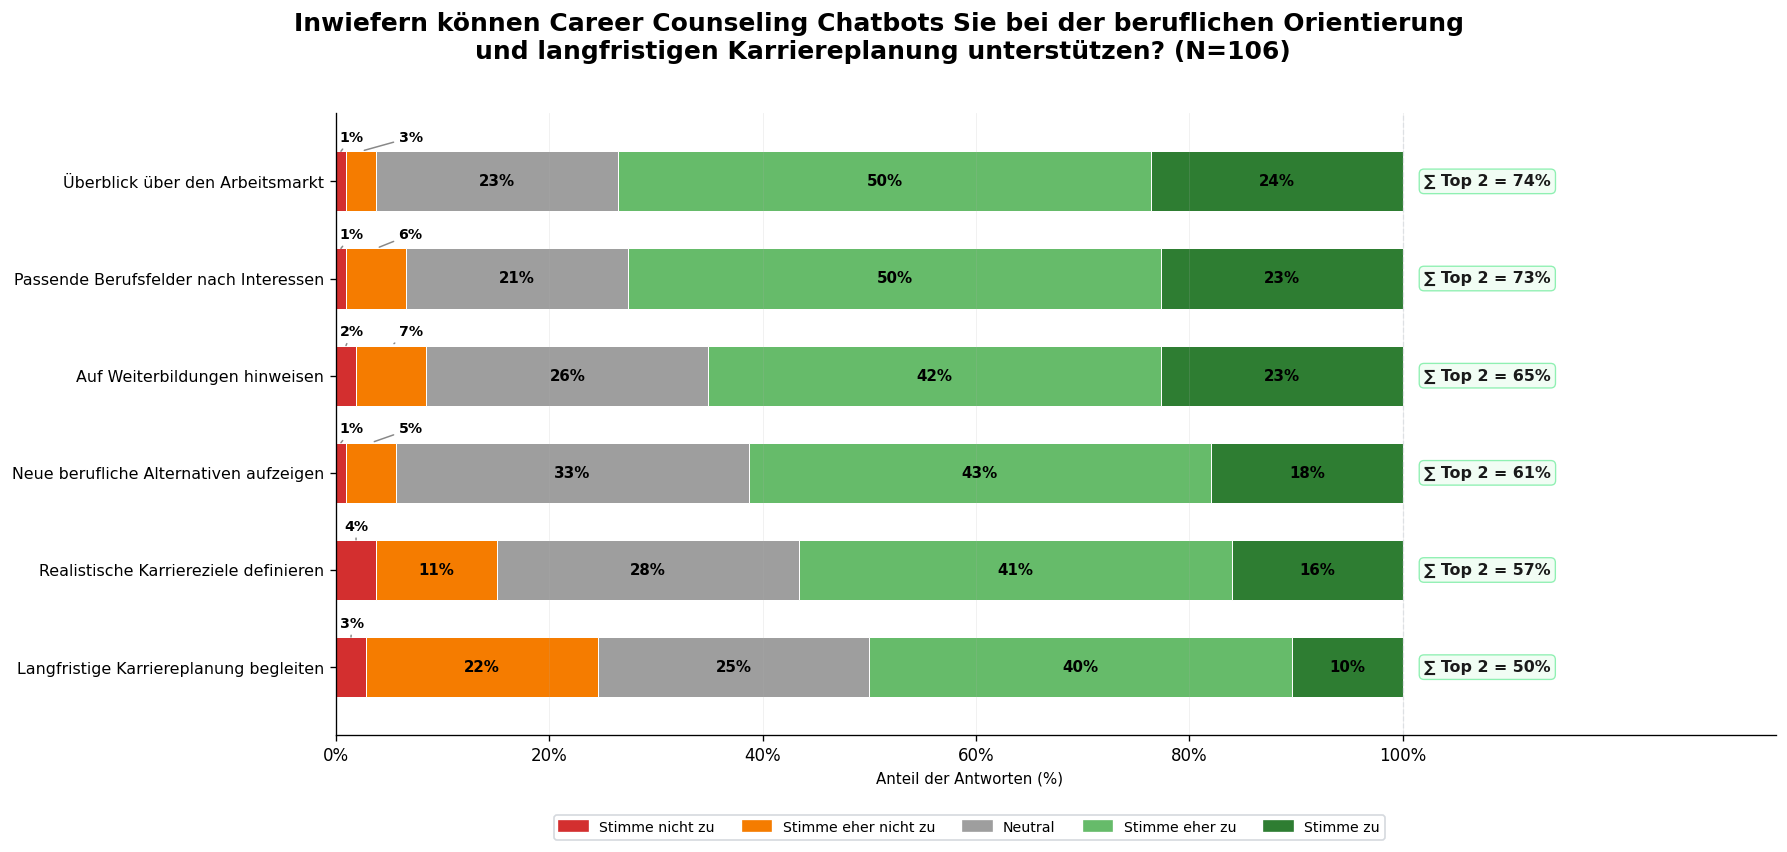

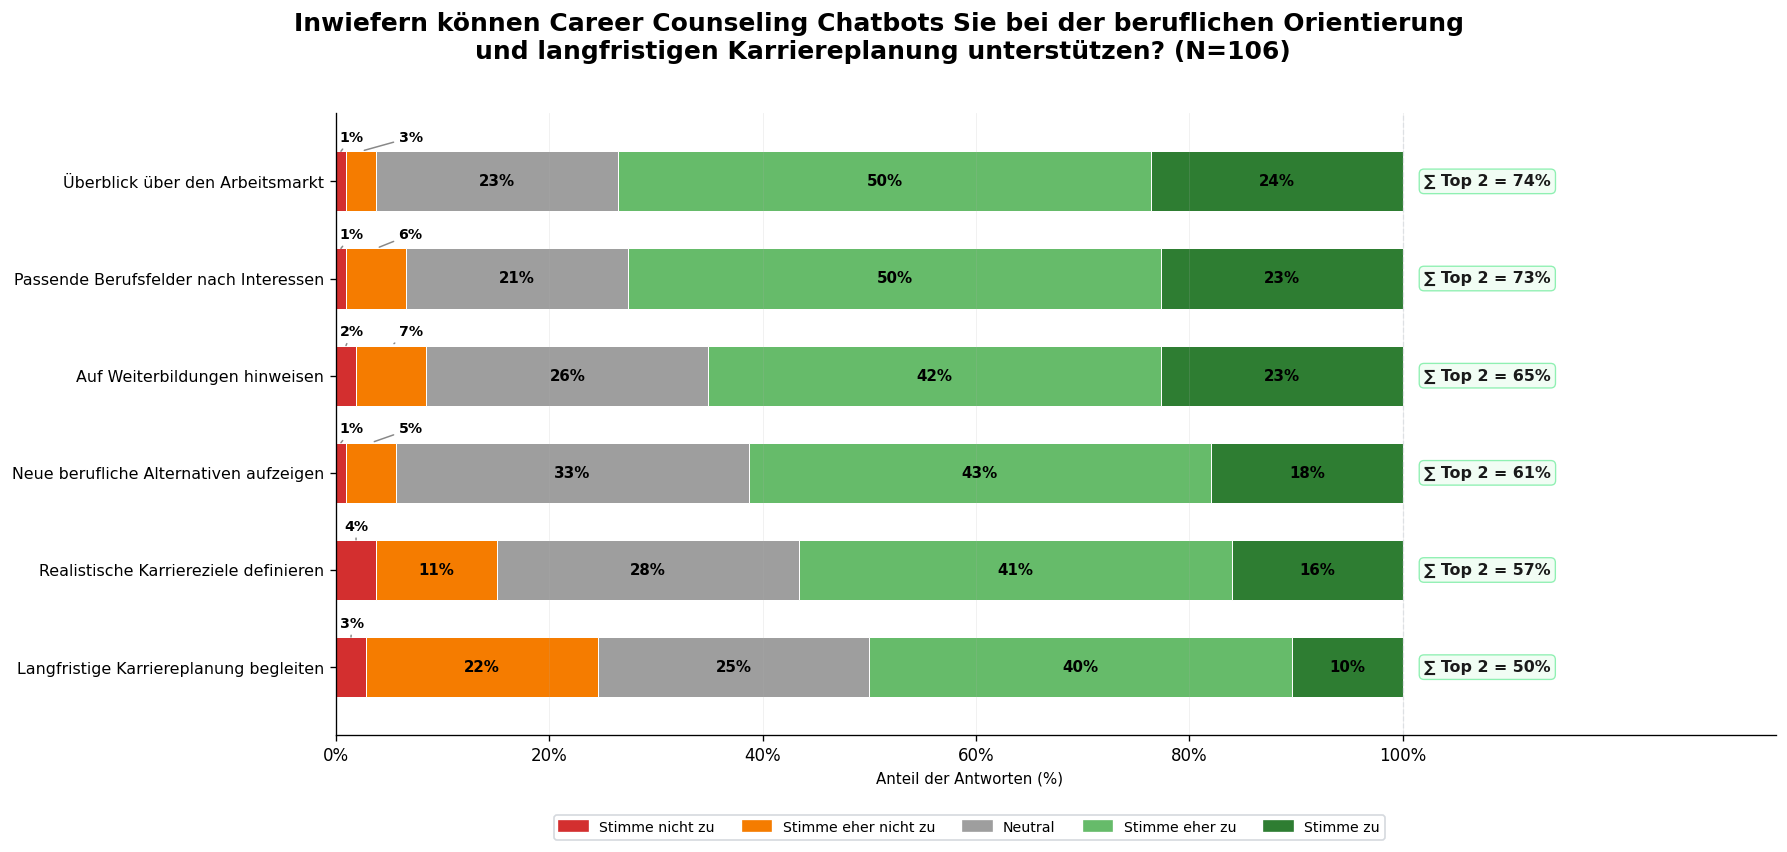

In [53]:
compact_likert_chart(df_valid, f11_items,
    title=f'Inwiefern können Career Counseling Chatbots Sie bei der beruflichen Orientierung \nund langfristigen Karriereplanung unterstützen? (N={N})')


In [54]:
u, p, r = mwu_test(weiblich['skala_f11'], maennlich['skala_f11'])
print(f"F11 – Karriereplanung: U={u:.0f}, p={p:.3f} {sig_stars(p)}, r={r:.3f} ({interpret_r(r)})")


F11 – Karriereplanung: U=1359, p=0.865 n.s., r=0.017 (sehr klein)


### F12 – Vergleich mit menschlicher Beratung: Funktionaler Nutzen

In [55]:
f12_items = {
    'f12_aehnlich_gut_n':            'Ähnlich gute Orientierung wie menschlicher Berater',
    'f12_kontinuierlicher_n':        'Bewerbungsprozess kontinuierlicher begleiten',
    'f12_konkrete_empfehlungen_n':   'Konkrete & nützliche Empfehlungen geben',
    'f12_sinnvolle_ergaenzung_n':    'Sinnvolle Ergänzung zur menschlichen Beratung',
    'f12_sinnvoller_einstieg_n':     'Sinnvoller Einstieg vor menschlicher Beratung',
    'f12_weiternutzen_nach_erfolg_n':'Weiternutzung nach erfolgreicher Jobsuche',
}
item_comparison_table(df_valid, f12_items,
    title=f'F12 – Vergleich menschl. Beratung (funktional): Item-Vergleich (N={N})')



F12 – Vergleich menschl. Beratung (funktional): Item-Vergleich (N=106)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Sinnvolle Ergänzung zur menschlichen Beratung,106,3.99,4.0,0.92,70
1,Konkrete & nützliche Empfehlungen geben,106,3.51,4.0,0.90,51
2,Sinnvoller Einstieg vor menschlicher Beratung,106,3.49,3.0,1.04,49
3,Weiternutzung nach erfolgreicher Jobsuche,106,3.31,3.0,1.13,45
4,Bewerbungsprozess kontinuierlicher begleiten,106,3.34,3.0,1.00,43
5,Ähnlich gute Orientierung wie menschlicher Ber...,106,3.09,3.0,1.03,34


  ► Höchster Top-2-Wert:   Sinnvolle Ergänzung zur menschlichen Beratung (70%)
  ► Tiefster  Top-2-Wert:  Ähnlich gute Orientierung wie menschlicher Berater (34%)
  ► Höchster Mittelwert:   Sinnvolle Ergänzung zur menschlichen Beratung (M=3.99)
  ► Höchste SD (Streuung): Weiternutzung nach erfolgreicher Jobsuche (SD=1.13)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Sinnvolle Ergänzung zur menschlichen Beratung,106,3.99,4.0,0.92,70
1,Konkrete & nützliche Empfehlungen geben,106,3.51,4.0,0.90,51
2,Sinnvoller Einstieg vor menschlicher Beratung,106,3.49,3.0,1.04,49
3,Weiternutzung nach erfolgreicher Jobsuche,106,3.31,3.0,1.13,45
4,Bewerbungsprozess kontinuierlicher begleiten,106,3.34,3.0,1.00,43
5,Ähnlich gute Orientierung wie menschlicher Ber...,106,3.09,3.0,1.03,34


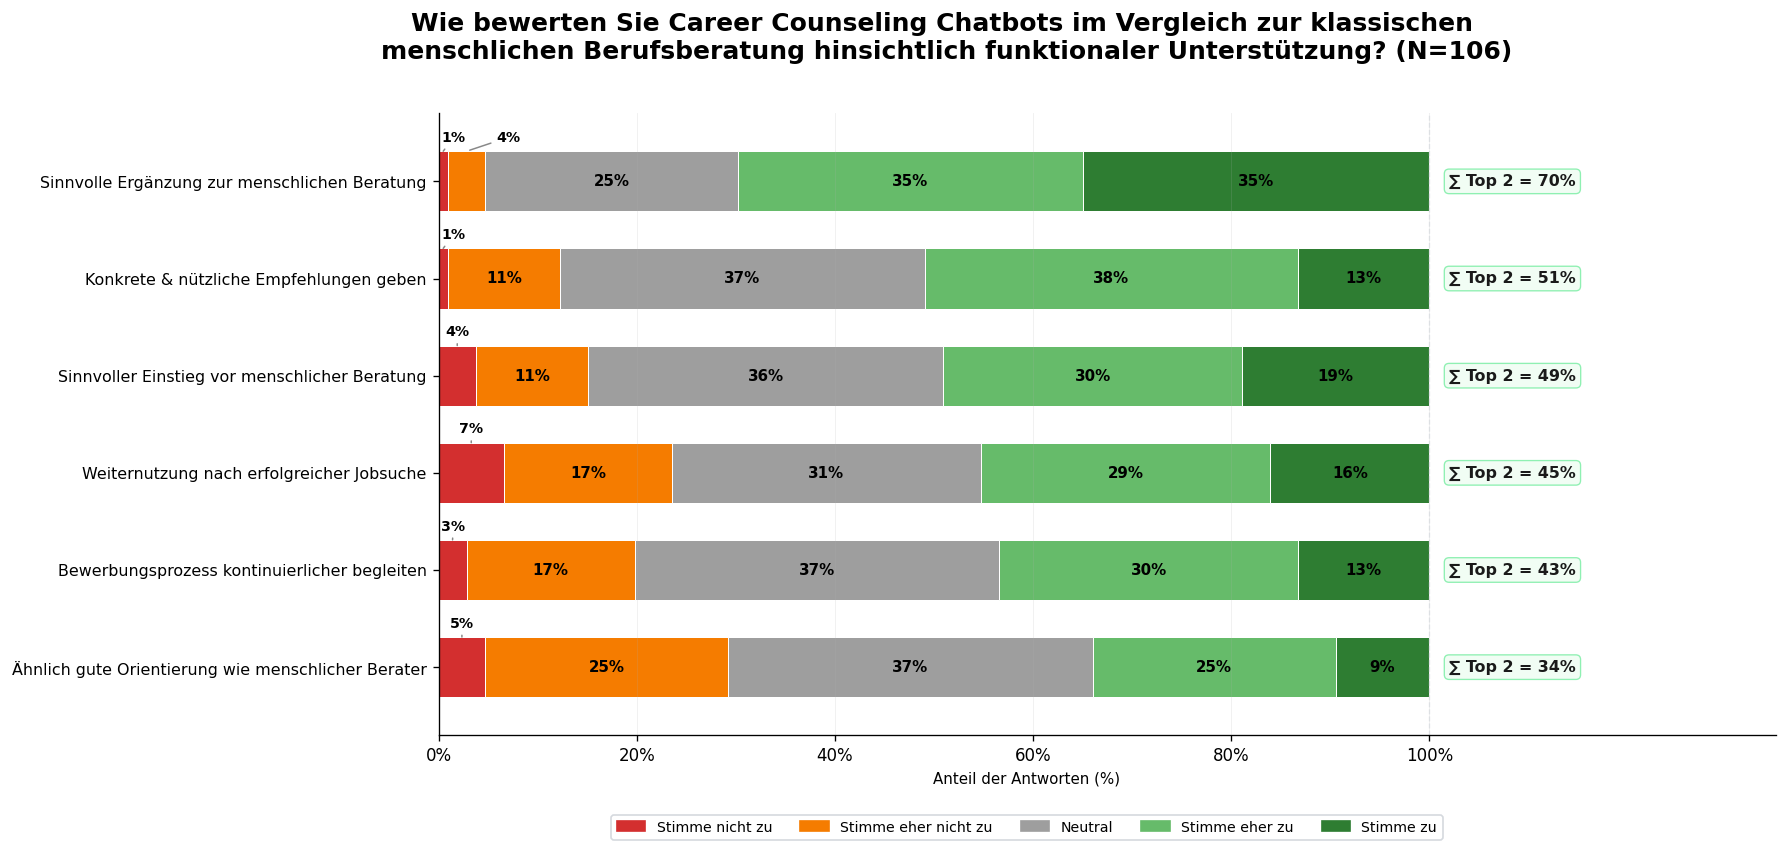

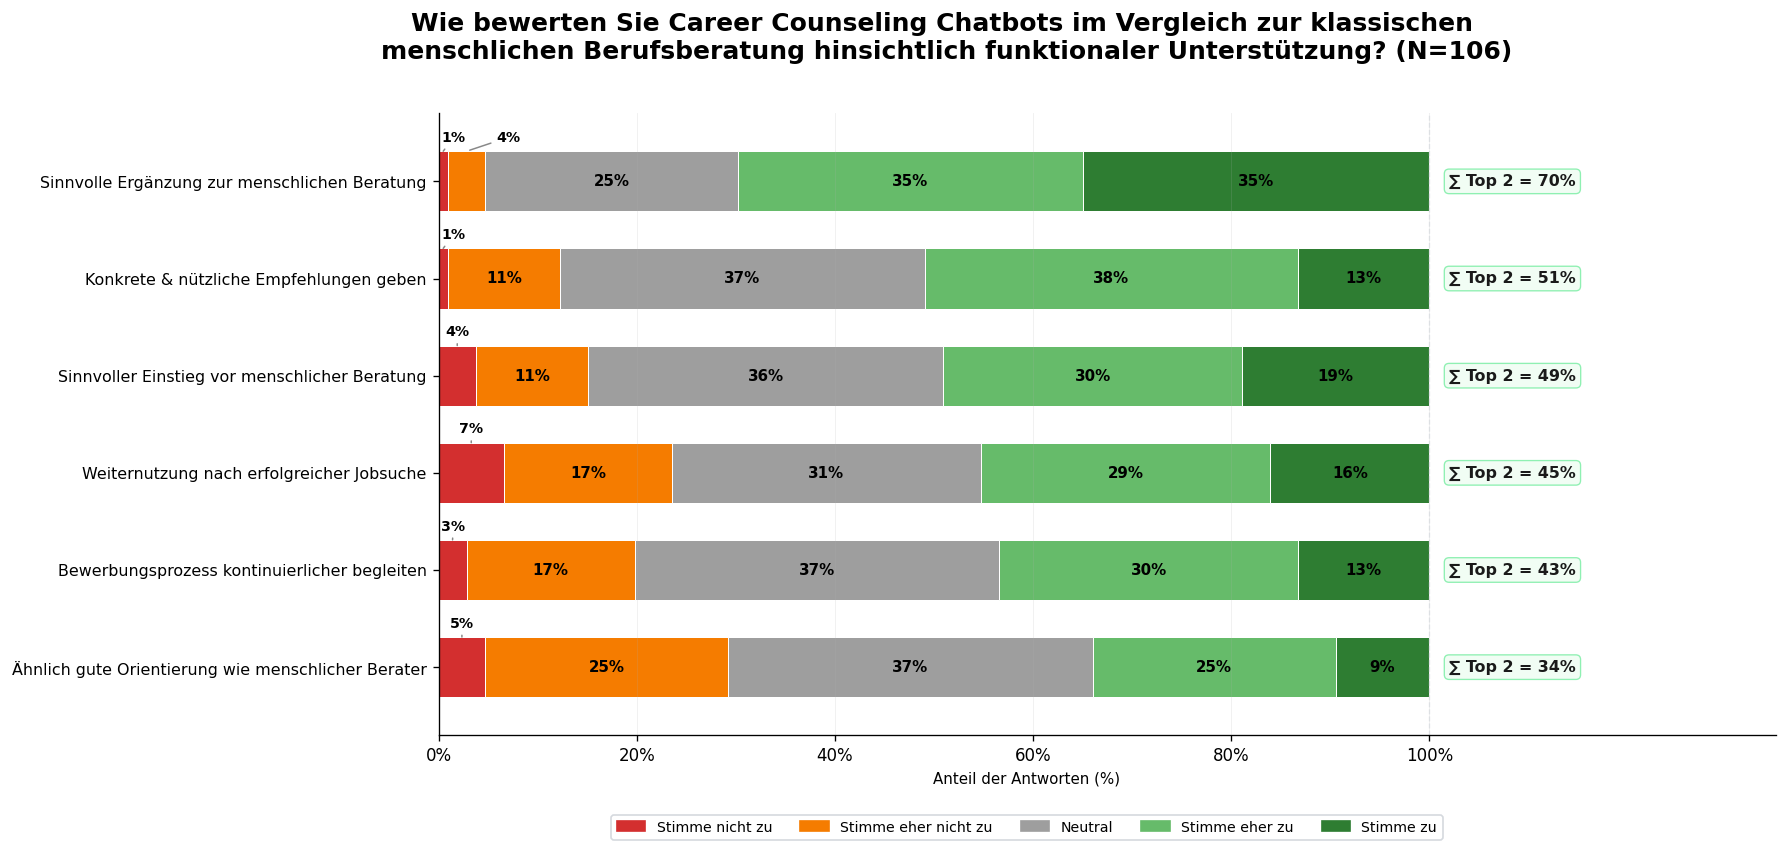

In [56]:
compact_likert_chart(df_valid, f12_items,
    title=f'Wie bewerten Sie Career Counseling Chatbots im Vergleich zur klassischen \nmenschlichen Berufsberatung hinsichtlich funktionaler Unterstützung? (N={N})')


In [57]:
u, p, r = mwu_test(weiblich['skala_f12'], maennlich['skala_f12'])
print(f"F12 – Vergleich funktional: U={u:.0f}, p={p:.3f} {sig_stars(p)}, r={r:.3f} ({interpret_r(r)})")


F12 – Vergleich funktional: U=1143, p=0.219 n.s., r=0.119 (klein)


---
## 7. Teil 3 – Gesamtbewertung & Erfolgspotenzial (F13)

In [58]:
f13_items = {
    'f13_potenzial_jobsuche_n':        'Potenzial, Jobsuche insgesamt zu verbessern',
    'f13_fester_bestandteil_n':        'Als fester Bestandteil der Jobsuche vorstellbar',
    'f13_stressige_phasen_n':          'Wertvolle Unterstützung in stressigen Phasen',
    'f13_wichtige_rolle_zukunft_n':    'Wichtige Rolle auf dem Arbeitsmarkt (Zukunft)',
    'f13_lernend_nutzen_n':            'Nutzung bei kontinuierlichem Lernen aus Feedback',
    'f13_gesamtes_erfolgspotenzial_n': 'Grosses Erfolgspotenzial insgesamt',
}
item_comparison_table(df_valid, f13_items,
    title=f'F13 – Gesamtpotenzial: Item-Vergleich (N={N})')



F13 – Gesamtpotenzial: Item-Vergleich (N=106)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Wichtige Rolle auf dem Arbeitsmarkt (Zukunft),106,3.93,4.0,0.88,75
1,Nutzung bei kontinuierlichem Lernen aus Feedback,106,3.94,4.0,0.83,74
2,Wertvolle Unterstützung in stressigen Phasen,106,3.88,4.0,0.80,72
3,Grosses Erfolgspotenzial insgesamt,106,3.81,4.0,0.87,65
4,"Potenzial, Jobsuche insgesamt zu verbessern",106,3.76,4.0,0.78,64
5,Als fester Bestandteil der Jobsuche vorstellbar,106,3.64,4.0,0.98,59


  ► Höchster Top-2-Wert:   Wichtige Rolle auf dem Arbeitsmarkt (Zukunft) (75%)
  ► Tiefster  Top-2-Wert:  Als fester Bestandteil der Jobsuche vorstellbar (59%)
  ► Höchster Mittelwert:   Nutzung bei kontinuierlichem Lernen aus Feedback (M=3.94)
  ► Höchste SD (Streuung): Als fester Bestandteil der Jobsuche vorstellbar (SD=0.98)


,Item,N,Mittelwert,Median,SD,Top-2-Box (%)
0,Wichtige Rolle auf dem Arbeitsmarkt (Zukunft),106,3.93,4.0,0.88,75
1,Nutzung bei kontinuierlichem Lernen aus Feedback,106,3.94,4.0,0.83,74
2,Wertvolle Unterstützung in stressigen Phasen,106,3.88,4.0,0.80,72
3,Grosses Erfolgspotenzial insgesamt,106,3.81,4.0,0.87,65
4,"Potenzial, Jobsuche insgesamt zu verbessern",106,3.76,4.0,0.78,64
5,Als fester Bestandteil der Jobsuche vorstellbar,106,3.64,4.0,0.98,59


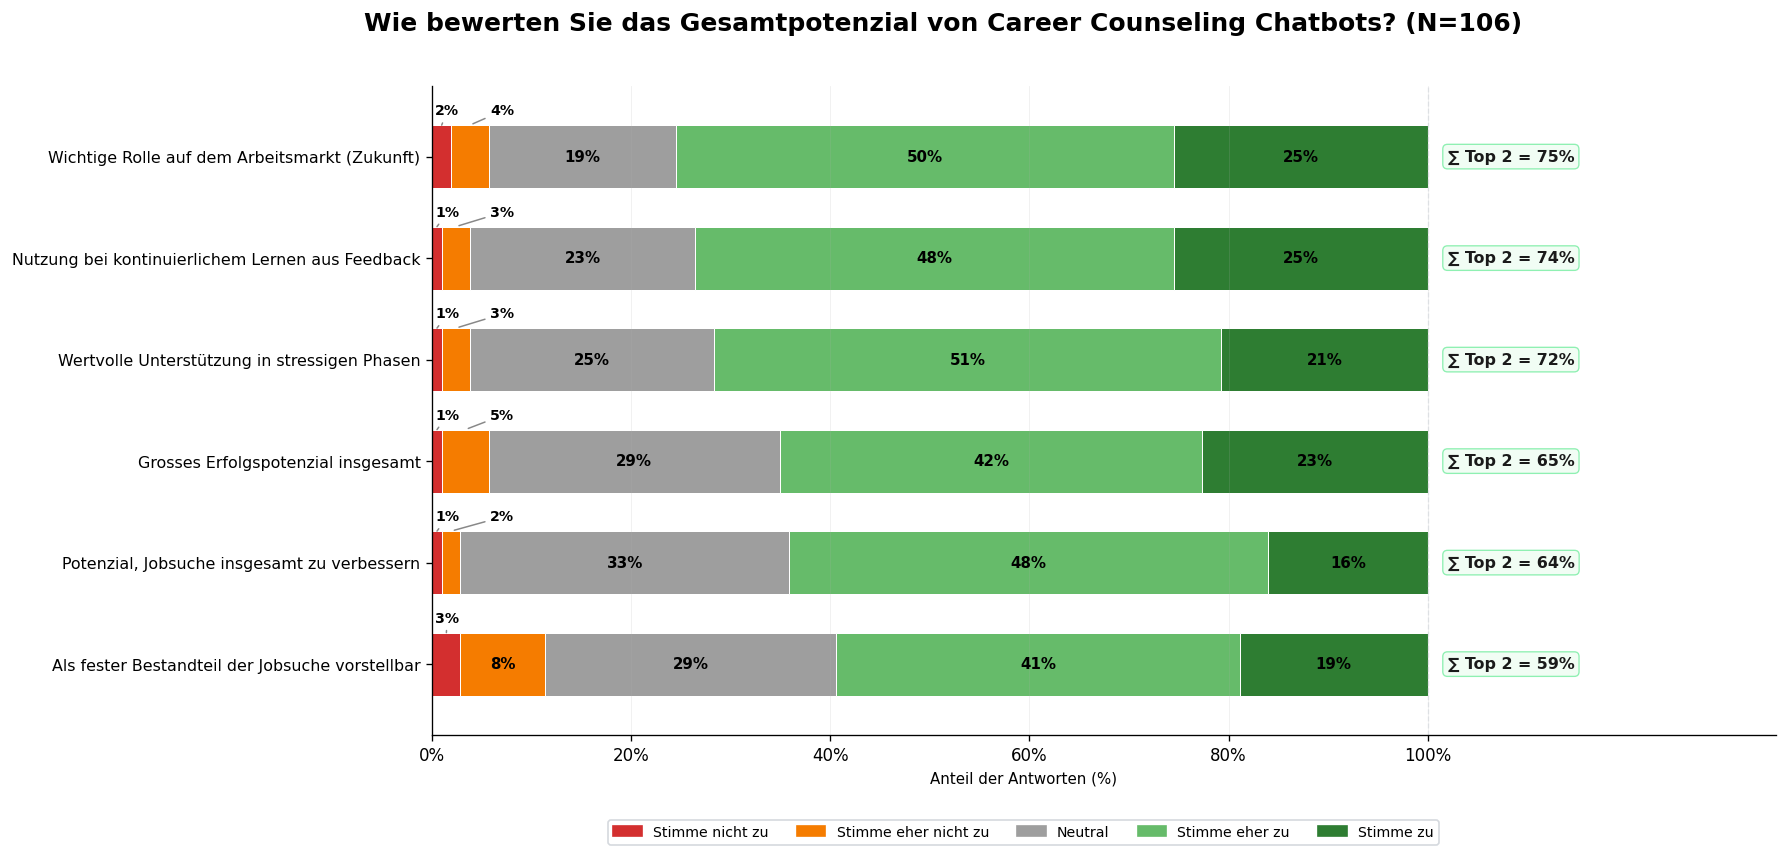

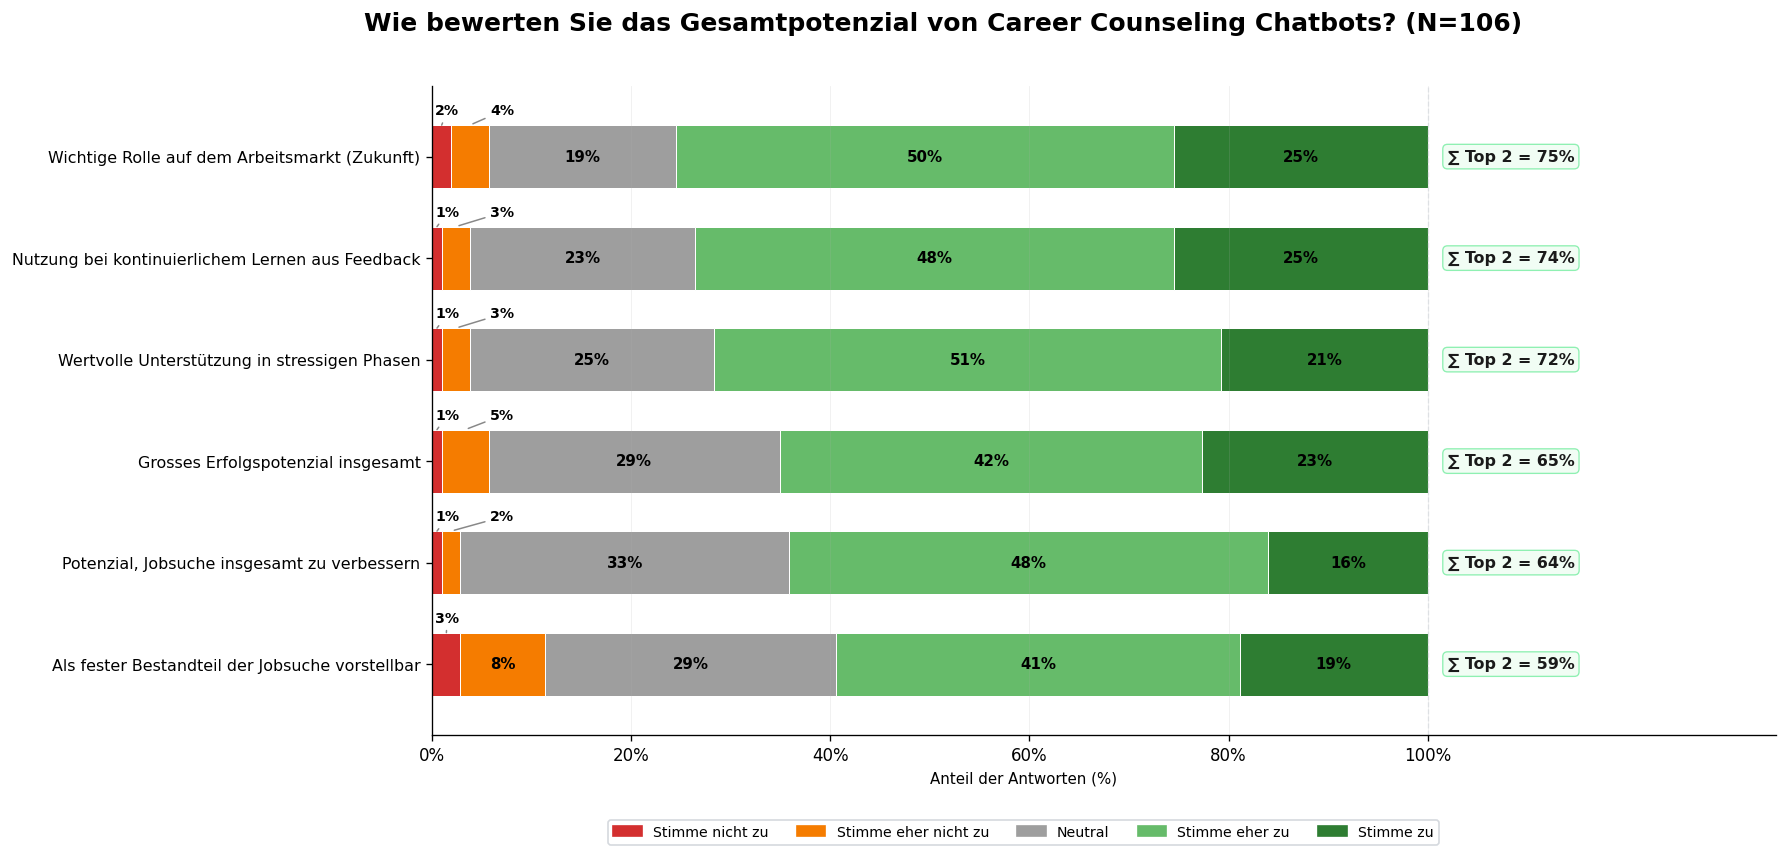

In [59]:
compact_likert_chart(df_valid, f13_items,
    title=f'Wie bewerten Sie das Gesamtpotenzial von Career Counseling Chatbots? (N={N})')


In [60]:
u, p, r = mwu_test(weiblich['skala_f13'], maennlich['skala_f13'])
print(f"F13 – Gesamtpotenzial: U={u:.0f}, p={p:.3f} {sig_stars(p)}, r={r:.3f} ({interpret_r(r)})")
print(f"  Weiblich:  M={weiblich['skala_f13'].mean():.2f}, Mdn={weiblich['skala_f13'].median():.1f}, SD={weiblich['skala_f13'].std():.2f}")
print(f"  Männlich:  M={maennlich['skala_f13'].mean():.2f}, Mdn={maennlich['skala_f13'].median():.1f}, SD={maennlich['skala_f13'].std():.2f}")


F13 – Gesamtpotenzial: U=1152, p=0.242 n.s., r=0.113 (klein)
  Weiblich:  M=3.78, Mdn=3.8, SD=0.66
  Männlich:  M=3.90, Mdn=4.0, SD=0.77


---
## 8. Gruppenvergleiche – Zusammenfassung (Mann-Whitney-U)

### 8.1 Alle 13 Skalen: Weiblich vs. Männlich


In [61]:
skalen_alle = [
    ('F1  – Allg. Einstellung',     'skala_f1'),
    ('F2  – Erwartungen',           'skala_f2'),
    ('F3  – Vertrauen',             'skala_f3'),
    ('F4  – Risiken',               'skala_f4'),
    ('F5  – Nutzungsabsicht',       'skala_f5'),
    ('F6  – Vergleich (Vertrauen)', 'skala_f6'),
    ('F7  – Einsatzbereiche',       'skala_f7'),
    ('F8  – Hindernisse',           'skala_f8'),
    ('F9  – Selbstreflexion',       'skala_f9'),
    ('F10 – Bewerbungsqualität',    'skala_f10'),
    ('F11 – Karriereplanung',       'skala_f11'),
    ('F12 – Vergleich (funkt.)',    'skala_f12'),
    ('F13 – Gesamtpotenzial',       'skala_f13'),
]

rows_mwu = []
print(f"{'Skala':<35} {'M_W':>6} {'M_M':>6} {'U':>8} {'p':>7} {'Sig':>5} {'r':>6} {'Effekt'}")
print("-" * 90)
for label, col in skalen_alle:
    if col not in df_valid.columns: continue
    g_w = weiblich[col].dropna()
    g_m = maennlich[col].dropna()
    mw = g_w.mean(); mm = g_m.mean()
    u, p, r = mwu_test(g_w, g_m)
    stars = sig_stars(p) if not np.isnan(p) else '-'
    eff   = interpret_r(r)
    print(f"  {label:<33} {mw:>6.2f} {mm:>6.2f} {u:>8.0f} {p:>7.3f} {stars:>5} {r:>6.3f}  {eff}")
    rows_mwu.append({'Skala': label, 'M_Weiblich': round(mw,2), 'M_Männlich': round(mm,2),
                     'U': u, 'p': round(p,3), 'r': round(r,3), 'Effekt': eff})

print(f"\nAnmerkung: * p<.05  ** p<.01  *** p<.001  n.s. = nicht signifikant")
print(f"Effektgrösse r: <.1 vernachlässigbar | .1–.3 klein | .3–.5 mittel | >.5 gross")


Skala                                  M_W    M_M        U       p   Sig      r Effekt
------------------------------------------------------------------------------------------
  F1  – Allg. Einstellung             3.63   3.85     1036   0.054  n.s.  0.187  klein
  F2  – Erwartungen                   3.92   3.87     1366   0.827  n.s.  0.021  sehr klein
  F3  – Vertrauen                     3.47   3.48     1270   0.684  n.s.  0.039  sehr klein
  F4  – Risiken                       3.49   3.37     1456   0.421  n.s.  0.078  sehr klein
  F5  – Nutzungsabsicht               3.26   3.34     1132   0.194  n.s.  0.126  klein
  F6  – Vergleich (Vertrauen)         3.73   3.84     1206   0.410  n.s.  0.080  sehr klein
  F7  – Einsatzbereiche               4.12   4.01     1430   0.524  n.s.  0.062  sehr klein
  F8  – Hindernisse                   3.03   2.92     1414   0.595  n.s.  0.052  sehr klein
  F9  – Selbstreflexion               3.57   3.51     1376   0.782  n.s.  0.027  sehr klein
  F1

In [62]:
from scipy.stats import kruskal

order_tech = ['Niedrig', 'Eher niedrig', 'Mittel', 'Eher hoch', 'Hoch']

skalen = ['skala_f1', 'skala_f2', 'skala_f3', 'skala_f4', 'skala_f5',
          'skala_f6', 'skala_f7', 'skala_f8', 'skala_f9', 'skala_f10',
          'skala_f11', 'skala_f12', 'skala_f13']

konstrukt_namen = {
    'skala_f1': 'F1 - Allg. Einstellung', 'skala_f2': 'F2 - Erwartungen',
    'skala_f3': 'F3 - Vertrauen', 'skala_f4': 'F4 - Risiken',
    'skala_f5': 'F5 - Nutzungsabsicht', 'skala_f6': 'F6 - Vergl. Vertrauen',
    'skala_f7': 'F7 - Einsatzbereiche', 'skala_f8': 'F8 - Hindernisse',
    'skala_f9': 'F9 - Selbstreflexion', 'skala_f10': 'F10 - Bewerbungsqualität',
    'skala_f11': 'F11 - Karriereplanung', 'skala_f12': 'F12 - Vergl. funkt. Nutzen',
    'skala_f13': 'F13 - Gesamtpotenzial'
}

results_tech = []

for skala in skalen:
    groups = [df_valid[df_valid['tech_affinitaet'] == t][skala].dropna().values
              for t in order_tech]
    groups_filtered = [g for g in groups if len(g) >= 3]

    if len(groups_filtered) >= 2:
        h_stat, p_val = kruskal(*groups_filtered)

        if p_val < 0.001: sig = '***'
        elif p_val < 0.01: sig = '**'
        elif p_val < 0.05: sig = '*'
        else: sig = 'n.s.'

        # Mittelwerte pro Gruppe
        means = {}
        for t in order_tech:
            sub = df_valid[df_valid['tech_affinitaet'] == t][skala].dropna()
            means[t] = round(sub.mean(), 2) if len(sub) > 0 else '-'

        results_tech.append({
            'Konstrukt': konstrukt_namen[skala],
            'M (Niedrig)': means['Niedrig'],
            'M (Eher niedrig)': means['Eher niedrig'],
            'M (Mittel)': means['Mittel'],
            'M (Eher hoch)': means['Eher hoch'],
            'M (Hoch)': means['Hoch'],
            'H': round(h_stat, 3),
            'p': round(p_val, 3),
            'Sig.': sig
        })

df_tech_results = pd.DataFrame(results_tech)
print(df_tech_results.to_string(index=False))

                 Konstrukt  M (Niedrig)  M (Eher niedrig)  M (Mittel)  M (Eher hoch)  M (Hoch)      H     p Sig.
    F1 - Allg. Einstellung         2.67              3.12        3.46           3.73      4.15 20.765 0.000  ***
          F2 - Erwartungen         3.50              3.48        3.83           3.90      4.12  7.271 0.064 n.s.
            F3 - Vertrauen         3.33              3.40        3.45           3.43      3.60  2.778 0.427 n.s.
              F4 - Risiken         3.00              3.52        3.37           3.55      3.30  2.908 0.406 n.s.
      F5 - Nutzungsabsicht         2.67              2.57        3.19           3.36      3.48 10.197 0.017    *
     F6 - Vergl. Vertrauen         3.33              3.55        3.62           3.86      3.84  4.498 0.212 n.s.
      F7 - Einsatzbereiche         3.50              3.71        3.88           4.19      4.17  6.087 0.107 n.s.
          F8 - Hindernisse         2.67              3.38        2.95           3.18      2.58 1

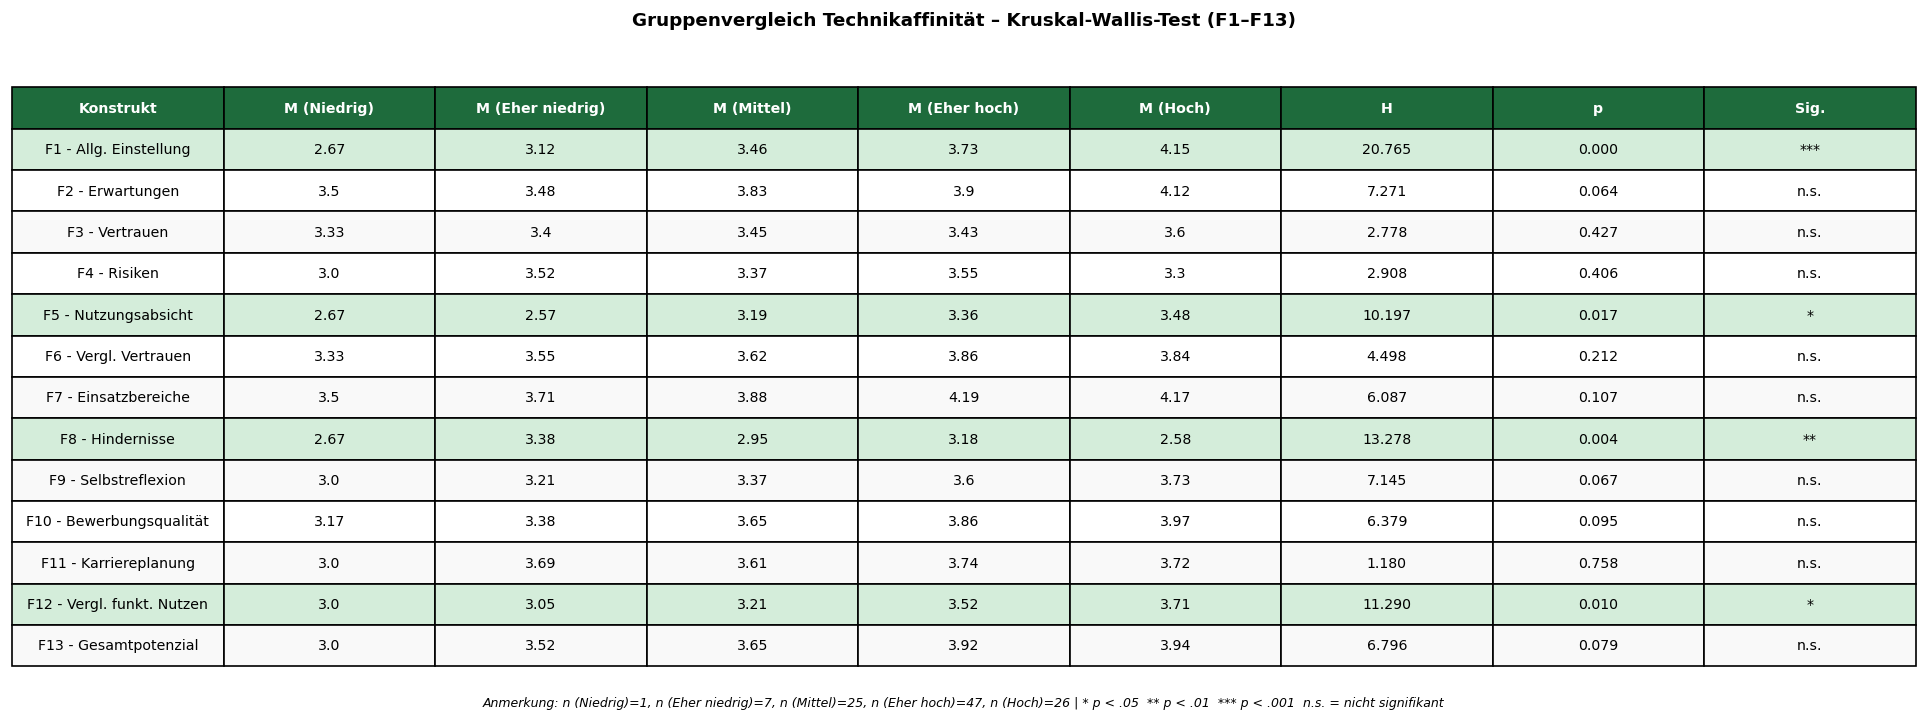

In [63]:
# Kruskal-Wallis Tabelle visualisieren
fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('off')

columns = ['Konstrukt', 'M (Niedrig)', 'M (Eher niedrig)', 'M (Mittel)', 
           'M (Eher hoch)', 'M (Hoch)', 'H', 'p', 'Sig.']

table_data = []
for _, row in df_tech_results.iterrows():
    table_data.append([
        row['Konstrukt'],
        f"{row['M (Niedrig)']}" if row['M (Niedrig)'] != '-' else '-',
        f"{row['M (Eher niedrig)']}",
        f"{row['M (Mittel)']}",
        f"{row['M (Eher hoch)']}",
        f"{row['M (Hoch)']}",
        f"{row['H']:.3f}",
        f"{row['p']:.3f}",
        row['Sig.']
    ])

table = ax.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1.2, 1.8)

# Header styling
for j in range(len(columns)):
    table[0, j].set_facecolor('#1E6B3C')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Zeilenfarben + signifikante Zeilen hervorheben
for i, row in enumerate(table_data):
    sig = row[8]
    for j in range(len(columns)):
        if sig in ['*', '**', '***']:
            table[i+1, j].set_facecolor('#D4EDDA')
        elif i % 2 == 0:
            table[i+1, j].set_facecolor('#F9F9F9')
        else:
            table[i+1, j].set_facecolor('#FFFFFF')

ax.set_title(
    'Gruppenvergleich Technikaffinität – Kruskal-Wallis-Test (F1–F13)',
    fontsize=11, fontweight='bold', loc='center', pad=20
)

fig.text(0.5, 0.01,
    'Anmerkung: n (Niedrig)=1, n (Eher niedrig)=7, n (Mittel)=25, n (Eher hoch)=47, n (Hoch)=26 | '
    '* p < .05  ** p < .01  *** p < .001  n.s. = nicht signifikant',
    fontsize=7.5, ha='center', style='italic')

plt.tight_layout()
plt.savefig('tabelle_tech_kruskal.png', dpi=150, bbox_inches='tight')
plt.show()

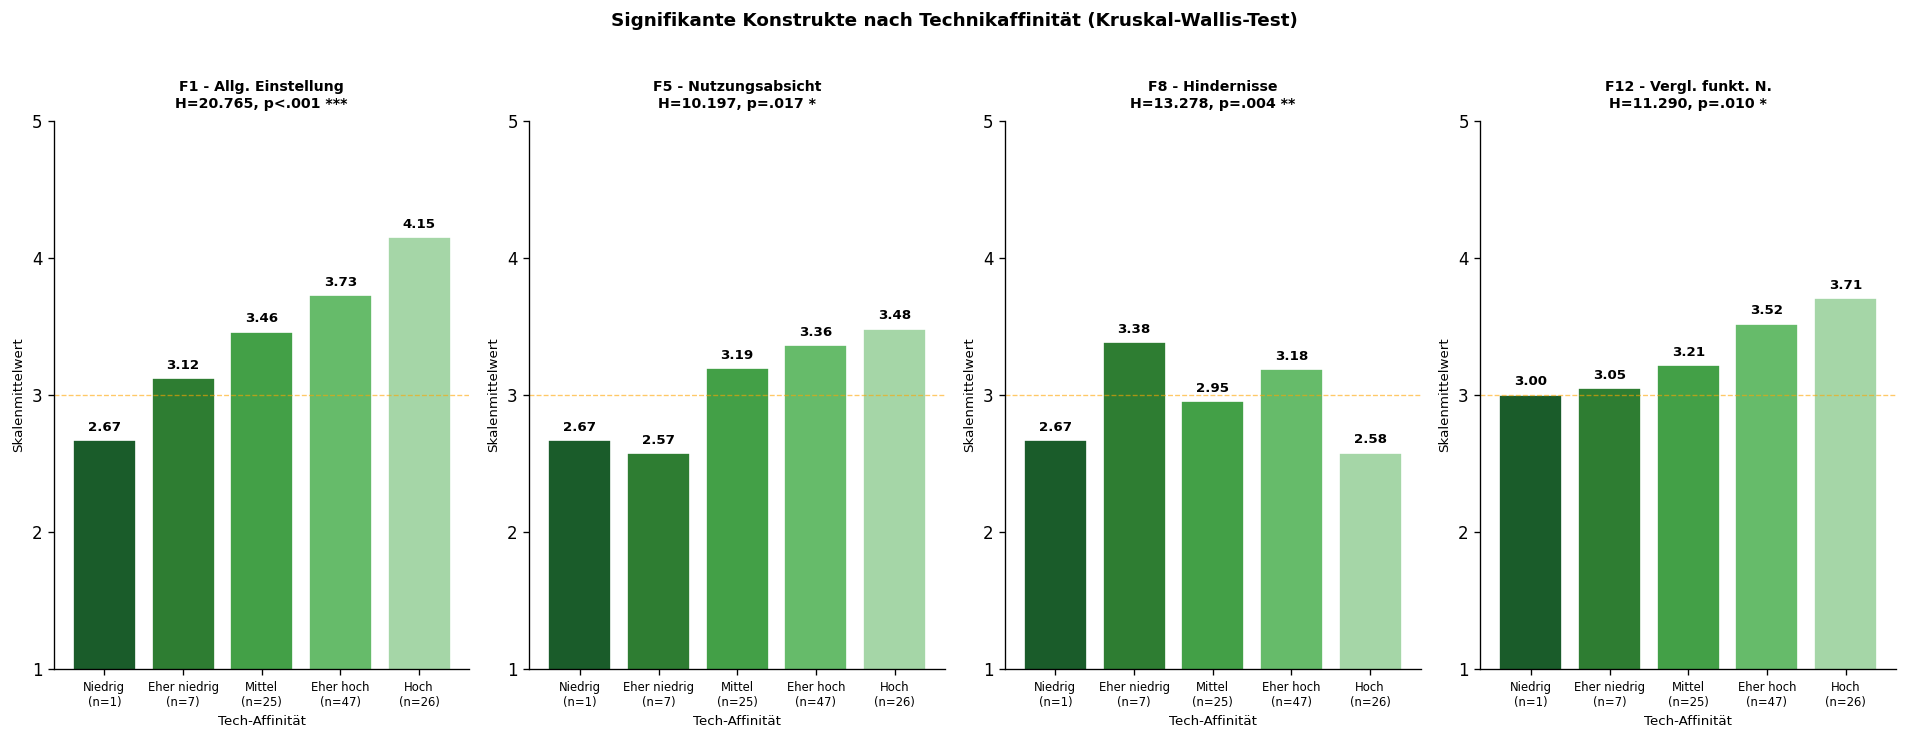

In [64]:
# Zusatzdiagramm - nur signifikante Konstrukte F1, F5, F8, F12
fig, axes = plt.subplots(1, 4, figsize=(16, 6))

sig_konstrukte = [
    ('skala_f1', 'F1 - Allg. Einstellung', 'H=20.765, p<.001 ***'),
    ('skala_f5', 'F5 - Nutzungsabsicht',   'H=10.197, p=.017 *'),
    ('skala_f8', 'F8 - Hindernisse',        'H=13.278, p=.004 **'),
    ('skala_f12', 'F12 - Vergl. funkt. N.', 'H=11.290, p=.010 *'),
]

order_tech = ['Niedrig', 'Eher niedrig', 'Mittel', 'Eher hoch', 'Hoch']
colors = ['#1a5c2a', '#2e7d32', '#43a047', '#66bb6a', '#a5d6a7']

for ax, (skala, titel, stats) in zip(axes, sig_konstrukte):
    means = []
    ns = []
    for t in order_tech:
        sub = df_valid[df_valid['tech_affinitaet'] == t][skala].dropna()
        means.append(sub.mean() if len(sub) > 0 else 0)
        ns.append(len(sub))

    x_labels = [f"{t}\n(n={n})" for t, n in zip(order_tech, ns)]
    bars = ax.bar(x_labels, means, color=colors, edgecolor='white')

    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05,
                f'{m:.2f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold', color='black')

    ax.set_ylim(1, 5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_title(f'{titel}\n{stats}', fontsize=8.5, fontweight='bold', pad=8)
    ax.set_xlabel('Tech-Affinität', fontsize=8)
    ax.set_ylabel('Skalenmittelwert', fontsize=8)
    ax.axhline(y=3, color='orange', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.tick_params(axis='x', labelsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Signifikante Konstrukte nach Technikaffinität (Kruskal-Wallis-Test)',
             fontsize=11, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('kruskal_signifikante_konstrukte.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Post-hoc-Test: Dunn-Test mit Bonferroni-Korrektur (signifikante Konstrukte)

Nach dem Kruskal-Wallis-Test werden für signifikante Konstrukte (p < .05) paarweise 
Dunn-Tests mit Bonferroni-Korrektur durchgeführt: F1 (p<.001), F5 (p<.05), 
F8 (p<.01), F12 (p<.05).


══════════════════════════════════════════════════════════════════════
  F1  – Allg. Einstellung  |  Kruskal-Wallis: p < .001 (***)
  Gruppen (n≥2): ['Eher niedrig', 'Mittel', 'Eher hoch', 'Hoch']  |  6 Paarvergleiche
══════════════════════════════════════════════════════════════════════


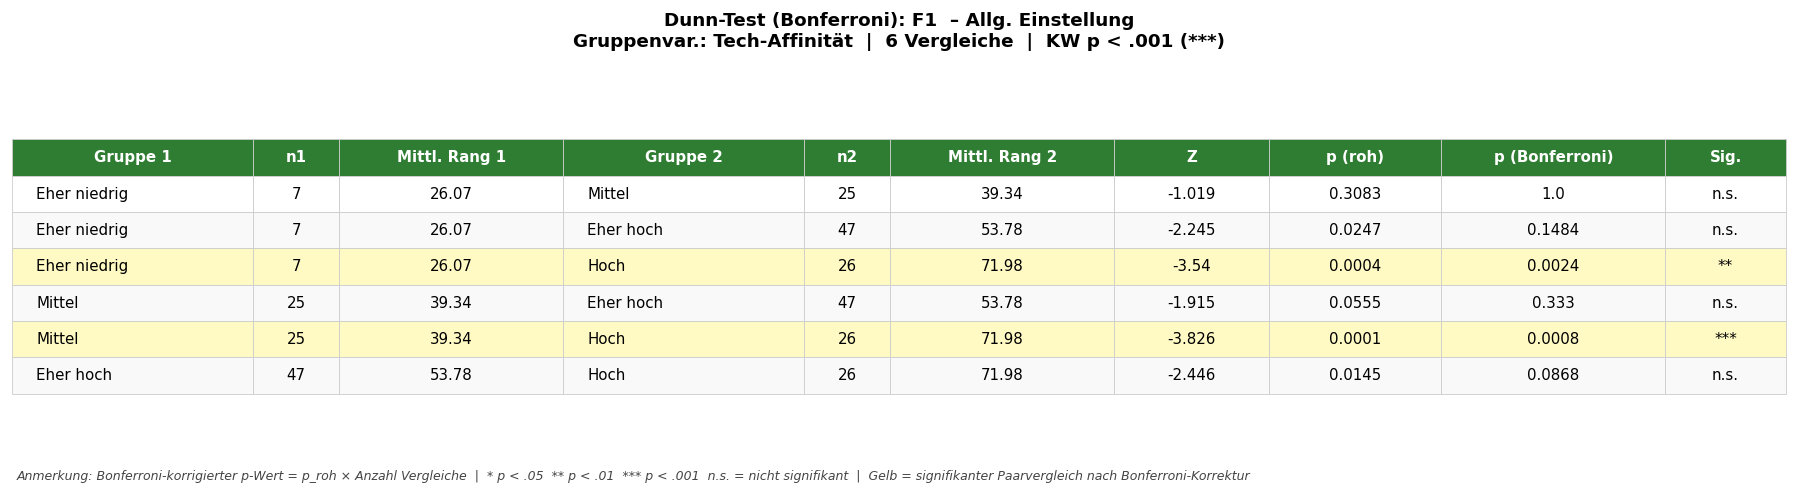


══════════════════════════════════════════════════════════════════════
  F5  – Nutzungsabsicht  |  Kruskal-Wallis: p < .05  (*)
  Gruppen (n≥2): ['Eher niedrig', 'Mittel', 'Eher hoch', 'Hoch']  |  6 Paarvergleiche
══════════════════════════════════════════════════════════════════════


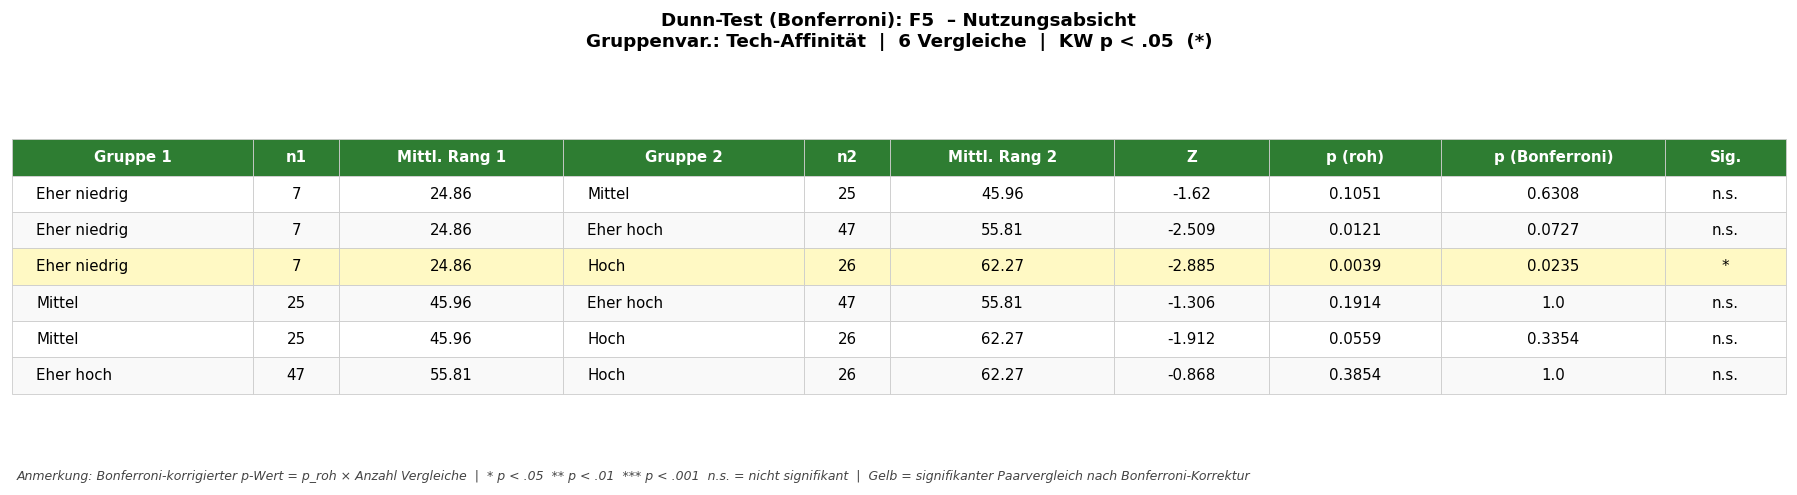


══════════════════════════════════════════════════════════════════════
  F8  – Hindernisse  |  Kruskal-Wallis: p < .01  (**)
  Gruppen (n≥2): ['Eher niedrig', 'Mittel', 'Eher hoch', 'Hoch']  |  6 Paarvergleiche
══════════════════════════════════════════════════════════════════════


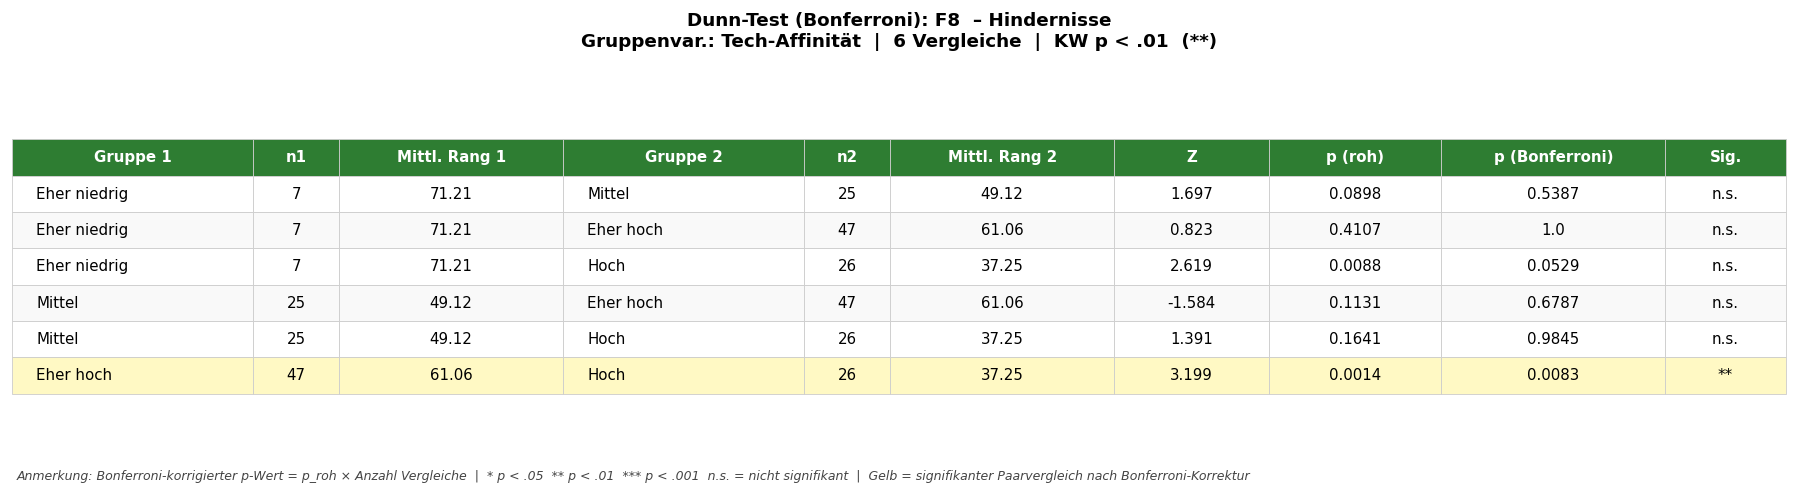


══════════════════════════════════════════════════════════════════════
  F12 – Vergl. funkt. Nutzen  |  Kruskal-Wallis: p < .05  (*)
  Gruppen (n≥2): ['Eher niedrig', 'Mittel', 'Eher hoch', 'Hoch']  |  6 Paarvergleiche
══════════════════════════════════════════════════════════════════════


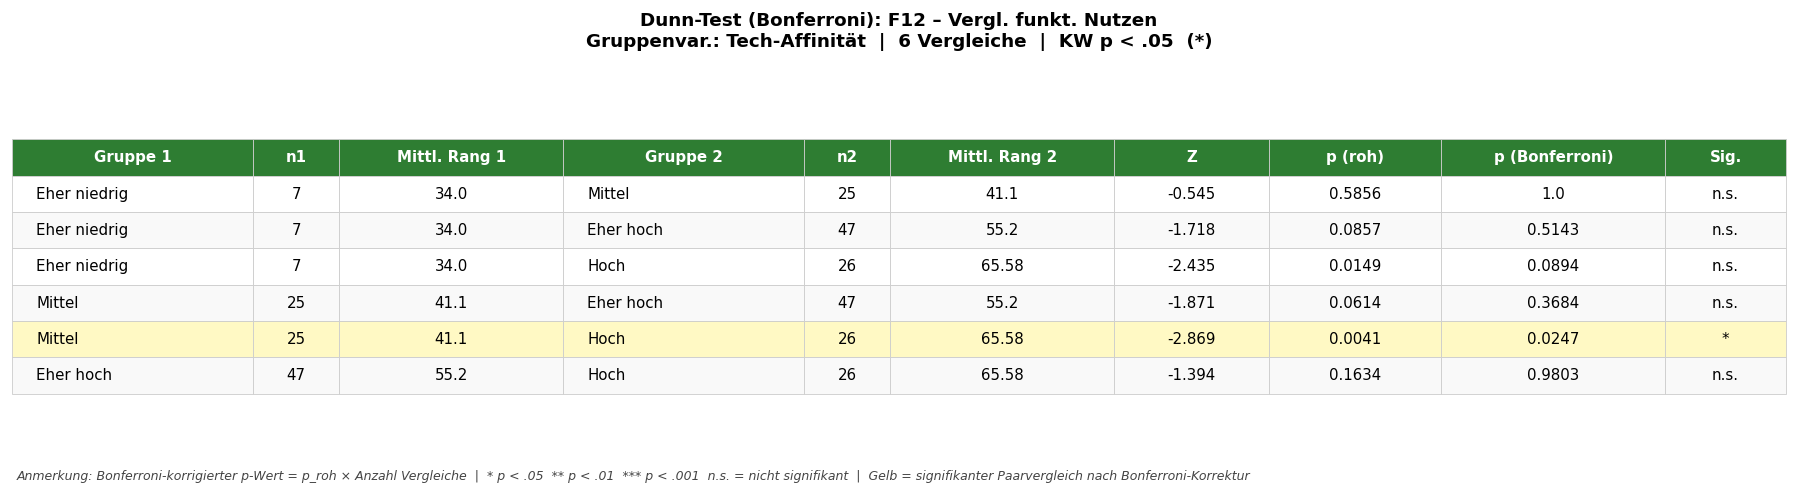

In [65]:
# ══════════════════════════════════════════════════════════════════════════════
# POST-HOC: Dunn-Test mit Bonferroni-Korrektur
# Nur für Konstrukte mit signifikantem Kruskal-Wallis (p < .05):
# F1, F5, F8, F12
# Gruppierungsvariable: tech_affinitaet (5 Stufen)
# ══════════════════════════════════════════════════════════════════════════════

from itertools import combinations
from scipy.stats import rankdata, norm

# ── Hilfsfunktion: Dunn-Test ──────────────────────────────────────────────────
def dunn_bonferroni(df, group_col, value_col, order):
    """
    Dunn-Test mit Bonferroni-Korrektur für k Gruppen.
    Gibt DataFrame aller Paarvergleiche zurück.
    Quelle: Dunn (1964), Zar (2010)
    """
    data = df[[group_col, value_col]].dropna().copy()

    # Nur Gruppen mit n >= 2 (n=1 ist nicht vergleichbar)
    valid_groups = [g for g in order if (data[group_col] == g).sum() >= 2]
    data = data[data[group_col].isin(valid_groups)].copy()

    N = len(data)
    k = len(valid_groups)
    n_comp = k * (k - 1) / 2  # Anzahl Paarvergleiche

    # Globale Ränge (über alle Gruppen)
    data['rank_'] = rankdata(data[value_col], method='average')

    # Gruppenstatistiken
    gstats = {}
    for g in valid_groups:
        sub = data[data[group_col] == g]
        gstats[g] = {'n': len(sub), 'mean_rank': sub['rank_'].mean()}

    rows = []
    for g1, g2 in combinations(valid_groups, 2):
        n1, n2   = gstats[g1]['n'], gstats[g2]['n']
        mr1, mr2 = gstats[g1]['mean_rank'], gstats[g2]['mean_rank']

        se    = np.sqrt((N * (N + 1) / 12.0) * (1/n1 + 1/n2))
        z     = (mr1 - mr2) / se
        p_raw = 2 * (1 - norm.cdf(abs(z)))
        p_adj = min(p_raw * n_comp, 1.0)   # Bonferroni

        rows.append({
            'Gruppe 1':          g1,
            'n1':                n1,
            'Mittl. Rang 1':     round(mr1, 2),
            'Gruppe 2':          g2,
            'n2':                n2,
            'Mittl. Rang 2':     round(mr2, 2),
            'Z':                 round(z, 3),
            'p (roh)':           round(p_raw, 4),
            'p (Bonferroni)':    round(p_adj, 4),
            'Sig.':              sig_stars(p_adj),
        })

    return pd.DataFrame(rows), valid_groups, gstats, n_comp


# ── Konstrukte mit signifikantem KW-Test ─────────────────────────────────────
ORDER_TECH = ['Niedrig', 'Eher niedrig', 'Mittel', 'Eher hoch', 'Hoch']

sig_konstrukte = [
    ('F1  – Allg. Einstellung',  'skala_f1',  'p < .001 (***)'),
    ('F5  – Nutzungsabsicht',    'skala_f5',  'p < .05  (*)'),
    ('F8  – Hindernisse',        'skala_f8',  'p < .01  (**)'),
    ('F12 – Vergl. funkt. Nutzen','skala_f12', 'p < .05  (*)'),
]

# ── Für jedes Konstrukt: Test + Tabellengrafik ────────────────────────────────
HDR_COL  = '#2e7d32'
ROW_ODD  = '#ffffff'
ROW_EVEN = '#f9f9f9'
SIG_COL  = '#fff9c4'  # gelb für signifikante Zeilen

for label, skala_col, kw_result in sig_konstrukte:

    df_dunn, valid_grp, gstats, n_comp = dunn_bonferroni(
        df_valid, 'tech_affinitaet', skala_col, ORDER_TECH
    )

    print(f"\n{'═'*70}")
    print(f"  {label}  |  Kruskal-Wallis: {kw_result}")
    print(f"  Gruppen (n≥2): {valid_grp}  |  {int(n_comp)} Paarvergleiche")
    print(f"{'═'*70}")

    cols_show  = ['Gruppe 1', 'n1', 'Mittl. Rang 1',
                  'Gruppe 2', 'n2', 'Mittl. Rang 2',
                  'Z', 'p (roh)', 'p (Bonferroni)', 'Sig.']
    col_widths = [0.14, 0.05, 0.13, 0.14, 0.05, 0.13, 0.09, 0.10, 0.13, 0.07]

    n_rows = len(df_dunn)
    fig_h  = 0.42 * n_rows + 1.6
    fig, ax = plt.subplots(figsize=(15, fig_h))
    fig.patch.set_facecolor('white')
    ax.axis('off')
    ax.set_title(
        f'Dunn-Test (Bonferroni): {label}\n'
        f'Gruppenvar.: Tech-Affinität  |  {int(n_comp)} Vergleiche  |  KW {kw_result}',
        fontsize=11, fontweight='bold', pad=10, loc='center'
    )

    p_bonf_vals = df_dunn['p (Bonferroni)'].values

    tbl = ax.table(
        cellText  = df_dunn[cols_show].values,
        colLabels = cols_show,
        cellLoc   = 'center',
        loc       = 'center',
        colWidths = col_widths,
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9.0)
    tbl.scale(1, 1.7)

    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor('#cccccc')
        cell.set_linewidth(0.5)
        if row == 0:
            cell.set_facecolor(HDR_COL)
            cell.set_text_props(color='white', fontweight='bold')
        else:
            try:
                p_val = float(p_bonf_vals[row - 1])
                bg = SIG_COL if p_val < .05 else (ROW_ODD if row % 2 != 0 else ROW_EVEN)
            except IndexError:
                bg = ROW_ODD
            cell.set_facecolor(bg)
        if col in (0, 3) and row > 0:
            cell.set_text_props(ha='left')
            cell._loc = 'left'

    fig.text(
        0.01, 0.01,
        'Anmerkung: Bonferroni-korrigierter p-Wert = p_roh × Anzahl Vergleiche  |  '
        '* p < .05  ** p < .01  *** p < .001  n.s. = nicht signifikant  |  '
        'Gelb = signifikanter Paarvergleich nach Bonferroni-Korrektur',
        fontsize=7.5, color='#444444', va='bottom', style='italic'
    )

    plt.tight_layout()
    plt.show()

### Vergleich Geschlecht

In [66]:
# Jahrgangvergleich Mann-Whitney-U Test (F1-F13)
from scipy.stats import mannwhitneyu

jahrgang_gruppen = ['1981 - 1995', '1996 - 2010']
skalen = ['skala_f1', 'skala_f2', 'skala_f3', 'skala_f4', 'skala_f5', 
          'skala_f6', 'skala_f7', 'skala_f8', 'skala_f9', 'skala_f10', 
          'skala_f11', 'skala_f12', 'skala_f13']

konstrukt_namen = {
    'skala_f1': 'F1 - Allg. Einstellung',
    'skala_f2': 'F2 - Erwartungen',
    'skala_f3': 'F3 - Vertrauen',
    'skala_f4': 'F4 - Risiken',
    'skala_f5': 'F5 - Nutzungsabsicht',
    'skala_f6': 'F6 - Vergl. Vertrauen',
    'skala_f7': 'F7 - Einsatzbereiche',
    'skala_f8': 'F8 - Hindernisse',
    'skala_f9': 'F9 - Selbstreflexion',
    'skala_f10': 'F10 - Bewerbungsqualität',
    'skala_f11': 'F11 - Karriereplanung',
    'skala_f12': 'F12 - Vergl. funkt. Nutzen',
    'skala_f13': 'F13 - Gesamtpotenzial'
}

results_jahrgang = []

for skala in skalen:
    g1 = df_valid[df_valid['jahrgang'] == '1981 - 1995'][skala].dropna()
    g2 = df_valid[df_valid['jahrgang'] == '1996 - 2010'][skala].dropna()
    
    if len(g1) >= 3 and len(g2) >= 3:
        u_stat, p_val = mannwhitneyu(g1, g2, alternative='two-sided')
        n1, n2 = len(g1), len(g2)
        r = u_stat / (n1 * n2)
        r_effect = 1 - (2 * r)  # Rosenthal r
        r_abs = abs(r_effect)
        
        if r_abs < 0.1:
            effekt = 'vernachlässigbar'
        elif r_abs < 0.3:
            effekt = 'klein'
        elif r_abs < 0.5:
            effekt = 'mittel'
        else:
            effekt = 'gross'
        
        if p_val < 0.001:
            sig = '***'
        elif p_val < 0.01:
            sig = '**'
        elif p_val < 0.05:
            sig = '*'
        else:
            sig = 'n.s.'
        
        results_jahrgang.append({
            'Konstrukt': konstrukt_namen[skala],
            'M (1981-1995)': round(g1.mean(), 2),
            'Mdn (1981-1995)': round(g1.median(), 1),
            'M (1996-2010)': round(g2.mean(), 2),
            'Mdn (1996-2010)': round(g2.median(), 1),
            'U': round(u_stat, 1),
            'p': round(p_val, 3),
            'Sig.': sig,
            'r': round(r_abs, 3),
            'Effekt': effekt
        })

df_jahrgang = pd.DataFrame(results_jahrgang)
print(df_jahrgang.to_string(index=False))

Empty DataFrame
Columns: []
Index: []


In [67]:
from scipy.stats import mannwhitneyu

skalen = ['skala_f1', 'skala_f2', 'skala_f3', 'skala_f4', 'skala_f5',
          'skala_f6', 'skala_f7', 'skala_f8', 'skala_f9', 'skala_f10',
          'skala_f11', 'skala_f12', 'skala_f13']

konstrukt_namen = {
    'skala_f1': 'F1 - Allg. Einstellung', 'skala_f2': 'F2 - Erwartungen',
    'skala_f3': 'F3 - Vertrauen', 'skala_f4': 'F4 - Risiken',
    'skala_f5': 'F5 - Nutzungsabsicht', 'skala_f6': 'F6 - Vergl. Vertrauen',
    'skala_f7': 'F7 - Einsatzbereiche', 'skala_f8': 'F8 - Hindernisse',
    'skala_f9': 'F9 - Selbstreflexion', 'skala_f10': 'F10 - Bewerbungsqualität',
    'skala_f11': 'F11 - Karriereplanung', 'skala_f12': 'F12 - Vergl. funkt. Nutzen',
    'skala_f13': 'F13 - Gesamtpotenzial'
}

g1 = df_valid[df_valid['jahrgang'] == '1981 – 1995 ']
g2 = df_valid[df_valid['jahrgang'] == '1996 – 2010 ']

results = []
for skala in skalen:
    s1 = g1[skala].dropna()
    s2 = g2[skala].dropna()
    u_stat, p_val = mannwhitneyu(s1, s2, alternative='two-sided')
    n1, n2 = len(s1), len(s2)
    r_abs = abs(1 - (2 * u_stat / (n1 * n2)))

    if r_abs < 0.1: effekt = 'sehr klein'
    elif r_abs < 0.2: effekt = 'klein'
    elif r_abs < 0.3: effekt = 'mittel'
    elif r_abs < 0.4: effekt = 'gross'
    else: effekt = 'sehr gross'

   

    if p_val < 0.001: sig = '***'
    elif p_val < 0.01: sig = '**'
    elif p_val < 0.05: sig = '*'
    else: sig = 'n.s.'

    results.append({
        'Konstrukt': konstrukt_namen[skala],
        'M (1981-1995)': round(s1.mean(), 2),
        'Mdn (1981-1995)': round(s1.median(), 1),
        'M (1996-2010)': round(s2.mean(), 2),
        'Mdn (1996-2010)': round(s2.median(), 1),
        'U': round(u_stat, 1),
        'p': round(p_val, 3),
        'Sig.': sig,
        'r': round(r_abs, 3),
        'Effekt': effekt
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

                 Konstrukt  M (1981-1995)  Mdn (1981-1995)  M (1996-2010)  Mdn (1996-2010)      U     p Sig.     r     Effekt
    F1 - Allg. Einstellung           3.36              3.5           3.79              3.8  578.5 0.072 n.s. 0.270     mittel
          F2 - Erwartungen           3.49              3.7           3.99              4.0  547.0 0.039    * 0.309      gross
            F3 - Vertrauen           3.42              3.4           3.48              3.5  716.5 0.524 n.s. 0.095 sehr klein
              F4 - Risiken           3.86              3.8           3.35              3.2 1128.5 0.004   ** 0.425 sehr gross
      F5 - Nutzungsabsicht           2.86              3.2           3.38              3.3  556.0 0.047    * 0.298     mittel
     F6 - Vergl. Vertrauen           3.78              3.7           3.77              3.8  768.0 0.842 n.s. 0.030 sehr klein
      F7 - Einsatzbereiche           3.71              3.8           4.15              4.1  535.5 0.030    * 0.324    

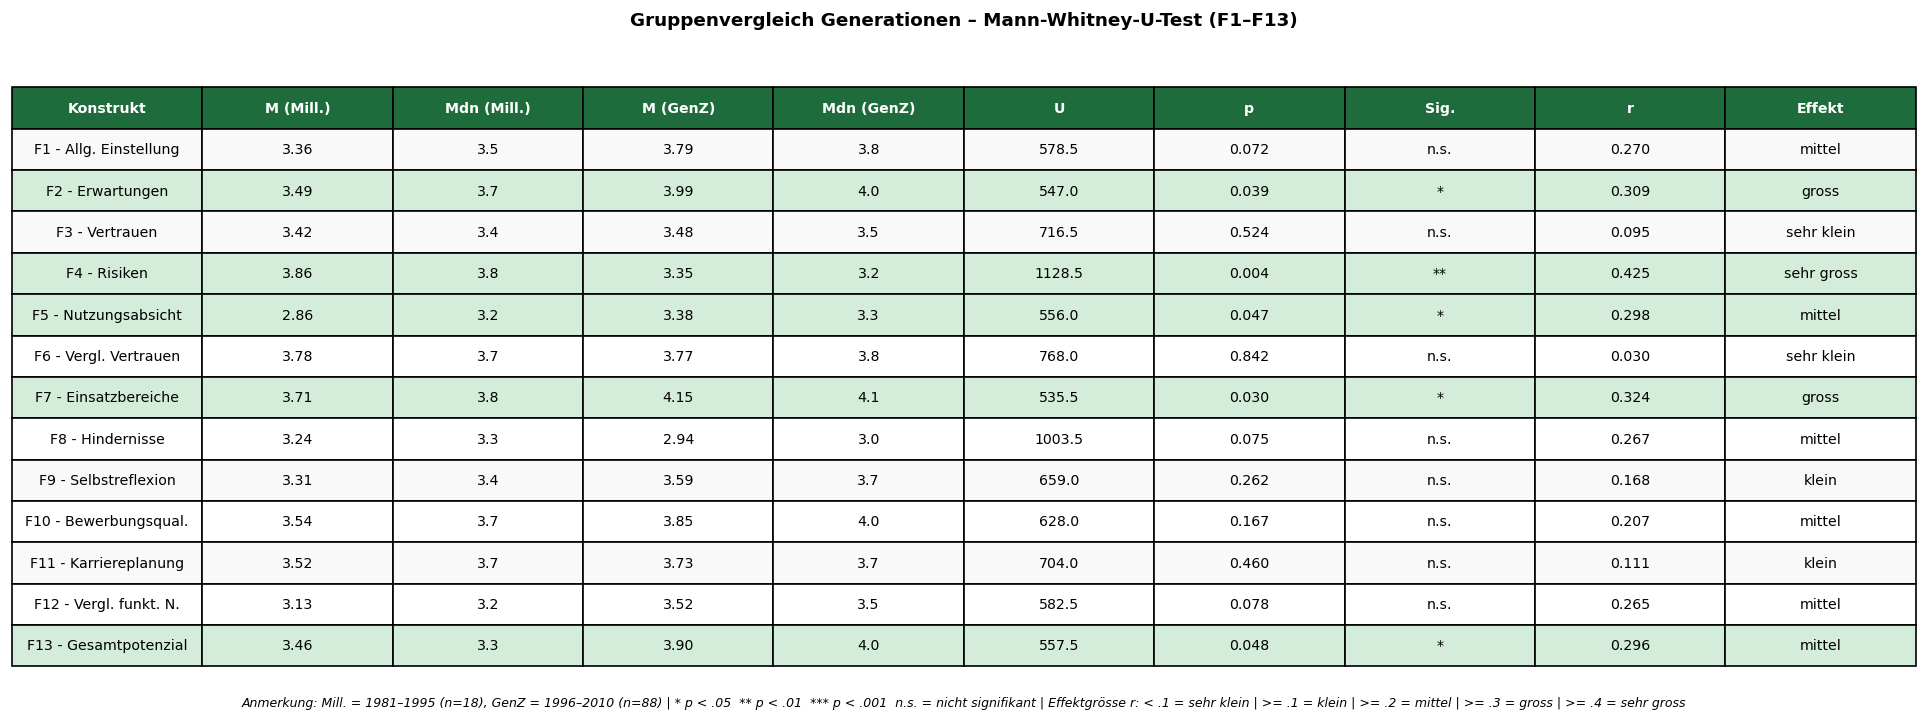

In [68]:
# Tabelle Jahrgangvergleich MWU visualisieren - angepasst
fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('off')

columns = ['Konstrukt', 'M (Mill.)', 'Mdn (Mill.)', 'M (GenZ)', 'Mdn (GenZ)', 'U', 'p', 'Sig.', 'r', 'Effekt']

# Kürzere Konstruktnamen
konstrukt_namen_kurz = {
    'F1 - Allg. Einstellung': 'F1 - Allg. Einstellung',
    'F2 - Erwartungen': 'F2 - Erwartungen',
    'F3 - Vertrauen': 'F3 - Vertrauen',
    'F4 - Risiken': 'F4 - Risiken',
    'F5 - Nutzungsabsicht': 'F5 - Nutzungsabsicht',
    'F6 - Vergl. Vertrauen': 'F6 - Vergl. Vertrauen',
    'F7 - Einsatzbereiche': 'F7 - Einsatzbereiche',
    'F8 - Hindernisse': 'F8 - Hindernisse',
    'F9 - Selbstreflexion': 'F9 - Selbstreflexion',
    'F10 - Bewerbungsqualität': 'F10 - Bewerbungsqual.',
    'F11 - Karriereplanung': 'F11 - Karriereplanung',
    'F12 - Vergl. funkt. Nutzen': 'F12 - Vergl. funkt. N.',
    'F13 - Gesamtpotenzial': 'F13 - Gesamtpotenzial'
}

table_data = []
for _, row in df_results.iterrows():
    name = konstrukt_namen_kurz.get(row['Konstrukt'], row['Konstrukt'])
    table_data.append([
        name,
        f"{row['M (1981-1995)']:.2f}",
        f"{row['Mdn (1981-1995)']:.1f}",
        f"{row['M (1996-2010)']:.2f}",
        f"{row['Mdn (1996-2010)']:.1f}",
        f"{row['U']:.1f}",
        f"{row['p']:.3f}",
        row['Sig.'],
        f"{row['r']:.3f}",
        row['Effekt']
    ])

table = ax.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1.2, 1.8)

# Header styling
for j in range(len(columns)):
    table[0, j].set_facecolor('#1E6B3C')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Zeilenfarben + signifikante Zeilen hervorheben
for i, row in enumerate(table_data):
    sig = row[7]
    for j in range(len(columns)):
        if sig in ['*', '**', '***']:
            table[i+1, j].set_facecolor('#D4EDDA')
        elif i % 2 == 0:
            table[i+1, j].set_facecolor('#F9F9F9')
        else:
            table[i+1, j].set_facecolor('#FFFFFF')

# Titel zentriert und fett
ax.set_title(
    'Gruppenvergleich Generationen – Mann-Whitney-U-Test (F1–F13)',
    fontsize=11, fontweight='bold', loc='center', pad=20
)

# Anmerkung unten
fig.text(0.5, 0.01,
    'Anmerkung: Mill. = 1981–1995 (n=18), GenZ = 1996–2010 (n=88) | '
    '* p < .05  ** p < .01  *** p < .001  n.s. = nicht signifikant | '
    'Effektgrösse r: < .1 = sehr klein | >= .1 = klein | >= .2 = mittel | >= .3 = gross | >= .4 = sehr gross',
    fontsize=7.5, ha='center', style='italic')

plt.tight_layout()
plt.savefig('tabelle_jahrgang_mwu.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Interkorrelationsmatrix (Spearman)

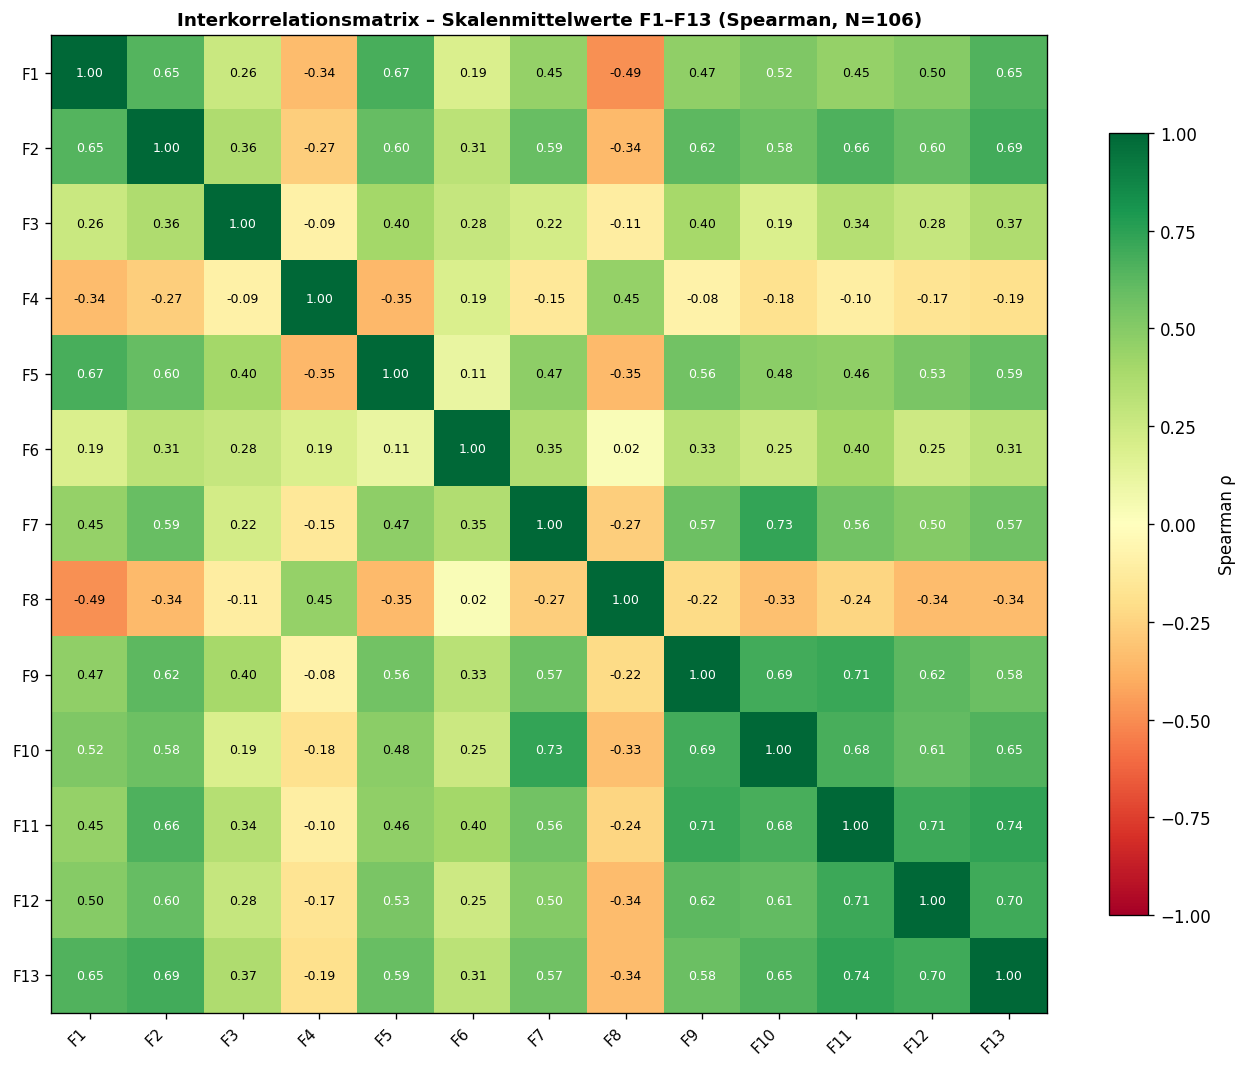

In [69]:
skala_cols   = [f'skala_f{i}' for i in range(1, 14) if f'skala_f{i}' in df_valid.columns]
skala_labels = [f'F{i}' for i in range(1, 14) if f'skala_f{i}' in df_valid.columns]

corr_matrix = df_valid[skala_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(11, 9))
import matplotlib.colors as mcolors
cmap = plt.cm.RdYlGn
im = ax.imshow(corr_matrix.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8, label='Spearman ρ')
ax.set_xticks(range(len(skala_labels)))
ax.set_yticks(range(len(skala_labels)))
ax.set_xticklabels(skala_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(skala_labels, fontsize=9)
for i in range(len(skala_labels)):
    for j in range(len(skala_labels)):
        val = corr_matrix.values[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7.5, color=color)
ax.set_title(f'Interkorrelationsmatrix – Skalenmittelwerte F1–F13 (Spearman, N={N})',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()


---
## 10. Gesamtübersicht – Alle Skalenmittelwerte

In [70]:
all_skala_info = [
    ('F1  – Allg. Einstellung',      'skala_f1',  f1_cols),
    ('F2  – Erwartungen',            'skala_f2',  f2_cols),
    ('F3  – Vertrauen',              'skala_f3',  f3_cols),
    ('F4  – Risiken',                'skala_f4',  f4_cols),
    ('F5  – Nutzungsabsicht',        'skala_f5',  f5_cols),
    ('F6  – Vergl. Vertrauen',       'skala_f6',  f6_cols),
    ('F7  – Einsatzbereiche',        'skala_f7',  f7_cols),
    ('F8  – Hindernisse',            'skala_f8',  f8_cols),
    ('F9  – Selbstreflexion',        'skala_f9',  f9_cols),
    ('F10 – Bewerbungsqualität',     'skala_f10', f10_cols),
    ('F11 – Karriereplanung',        'skala_f11', f11_cols),
    ('F12 – Vergl. funkt.',          'skala_f12', f12_cols),
    ('F13 – Gesamtpotenzial',        'skala_f13', f13_cols),
]

summary_rows = []
print(f"GESAMTÜBERSICHT  (N = {N})")
print(f"{'Skala':<35} {'M':>6} {'SD':>6} {'Mdn':>5} {'Top2%':>7} {'α':>7}")
print("=" * 70)
for label, skala_col, item_cols in all_skala_info:
    if skala_col not in df_valid.columns: continue
    data = df_valid[skala_col].dropna()
    m, sd, mdn = data.mean(), data.std(), data.median()
    items_avail = [c for c in item_cols if c in df_valid.columns]
    alpha_val = cronbach_alpha(df_valid[items_avail]) if len(items_avail) >= 2 else np.nan
    # Top-2 auf Skalenebene: Anteil Personen mit Skalenmittelwert >= 4
    t2 = (data >= 4).sum() / len(data) * 100
    a_str = f'{alpha_val:.3f}' if not np.isnan(alpha_val) else '   -'
    print(f"  {label:<33} {m:>6.2f} {sd:>6.2f} {mdn:>5.1f} {t2:>7.1f}% {a_str:>7}")
    summary_rows.append({'Skala': label, 'M': round(m,2), 'SD': round(sd,2),
                         'Mdn': mdn, 'Top2%': round(t2,1),
                         'α': round(alpha_val,3) if not np.isnan(alpha_val) else np.nan})
print("=" * 70)
summary_df = pd.DataFrame(summary_rows)


GESAMTÜBERSICHT  (N = 106)
Skala                                    M     SD   Mdn   Top2%       α
  F1  – Allg. Einstellung             3.72   0.76   3.8    42.5%   0.852
  F2  – Erwartungen                   3.90   0.66   3.8    48.1%   0.811
  F3  – Vertrauen                     3.47   0.44   3.5    15.1%   0.175
  F4  – Risiken                       3.44   0.65   3.3    29.2%   0.708
  F5  – Nutzungsabsicht               3.29   0.80   3.3    20.8%   0.866
  F6  – Vergl. Vertrauen              3.77   0.52   3.8    42.5%   0.459
  F7  – Einsatzbereiche               4.07   0.70   4.0    60.4%   0.819
  F8  – Hindernisse                   2.99   0.71   3.2     7.5%   0.728
  F9  – Selbstreflexion               3.54   0.74   3.7    36.8%   0.863
  F10 – Bewerbungsqualität            3.80   0.71   3.8    49.1%   0.869
  F11 – Karriereplanung               3.69   0.73   3.7    38.7%   0.884
  F12 – Vergl. funkt.                 3.46   0.71   3.3    29.2%   0.794
  F13 – Gesamtpotenzial  

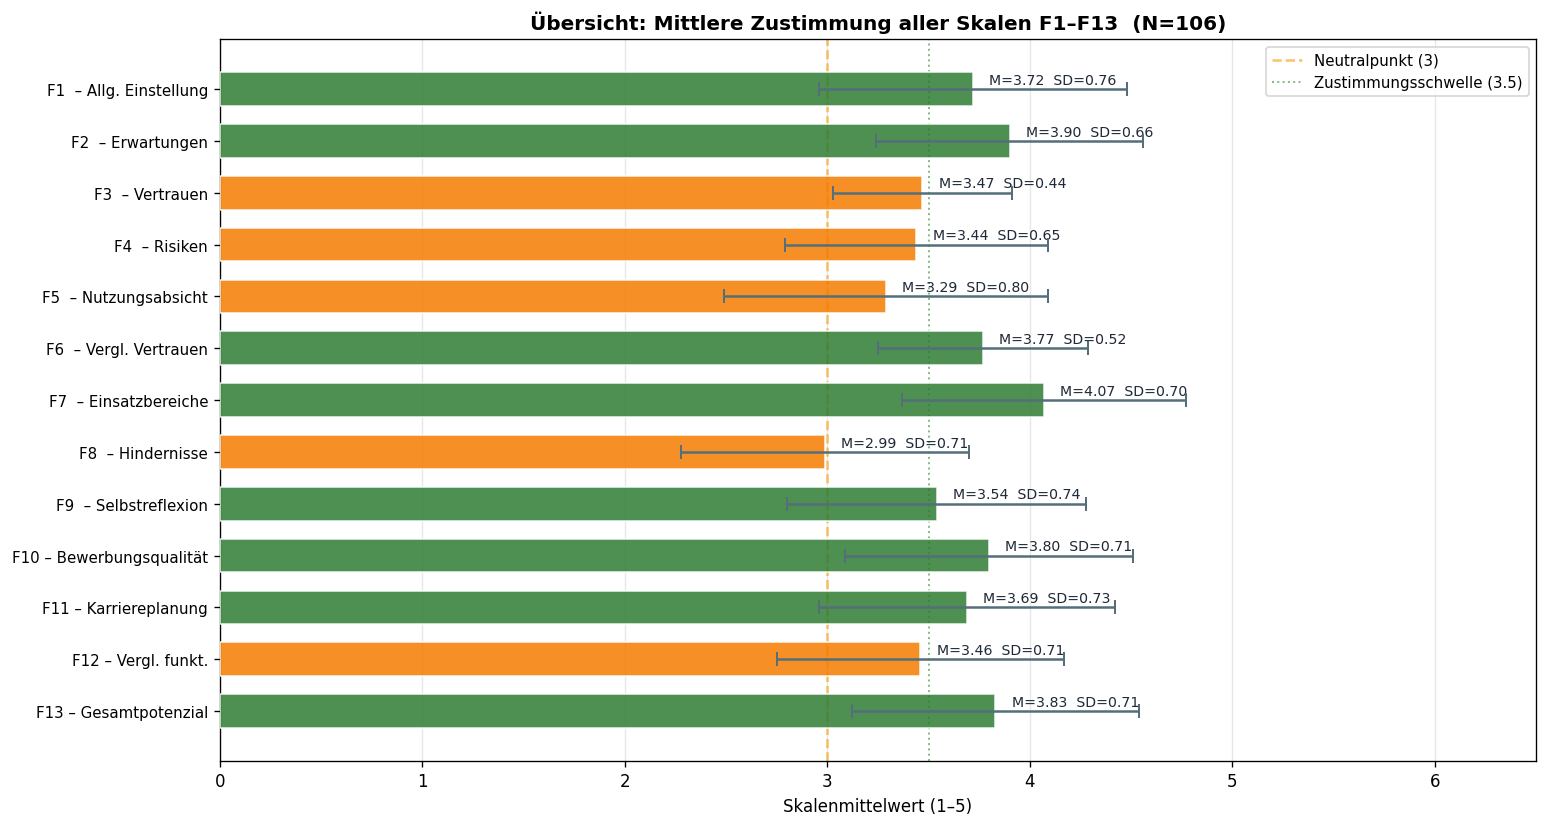

In [71]:
# ─── Balkendiagramm Gesamtübersicht ────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))
means = summary_df['M'].values
sds   = summary_df['SD'].values
labels_s = summary_df['Skala'].tolist()
colors_ov = ['#2e7d32' if m >= 3.5 else '#f57c00' if m >= 2.5 else '#c62828' for m in means]

bars = ax.barh(range(len(labels_s)), means,
               color=colors_ov, alpha=0.85, edgecolor='white', height=0.65, zorder=3)
ax.errorbar(means, range(len(labels_s)), xerr=sds,
            fmt='none', color='#546e7a', capsize=4, capthick=1.2, zorder=4)
for i, (m, sd_v) in enumerate(zip(means, sds)):
    ax.text(m + 0.08, i - 0.18, f'M={m:.2f}  SD={sd_v:.2f}',
        va='center', fontsize=8.5, color='#1f2937')

ax.set_yticks(range(len(labels_s)))
ax.set_yticklabels(labels_s, fontsize=9)
ax.set_xlim(0, 6.5)
ax.set_xlabel('Skalenmittelwert (1–5)', fontsize=10)
ax.axvline(3,   color='#f9a825', linestyle='--', alpha=0.7, linewidth=1.5, label='Neutralpunkt (3)')
ax.axvline(3.5, color='#388e3c', linestyle=':',  alpha=0.6, linewidth=1.2, label='Zustimmungsschwelle (3.5)')
ax.set_title(f'Übersicht: Mittlere Zustimmung aller Skalen F1–F13  (N={N})',
             fontweight='bold', fontsize=12)
ax.invert_yaxis()
ax.legend(fontsize=9)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


---
## 11. Export

```python
# Alle Diagramme als PNG exportieren (300 dpi für Bachelorarbeit):
# fig.savefig('diagramm_f1.png', dpi=300, bbox_inches='tight')

# Ergebnistabelle exportieren:
# summary_df.to_excel('ergebnisse_uebersicht.xlsx', index=False)
# df_valid.to_csv('auswertung_bereinigt.csv', index=False, encoding='utf-8-sig')
```

**Wichtige Hinweise:**
- **Top-2-Box**: Anteil „Stimme eher zu" (4) + „Stimme zu" (5) – **nicht** die zwei häufigsten Kategorien
- **Gruppenvergleich**: Mann-Whitney-U-Test (Weiblich vs. Männlich), Kruskal-Wallis für ≥3 Gruppen
- **Effektgrösse**: r = Z/√N nach Rosenthal (1991); keine Cohen's d-Berechnung als Hauptmethode
- **Signifikanzniveaus**: * p<.05, ** p<.01, *** p<.001, n.s. = nicht signifikant
